# Extract File

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import torch
from sklearn.model_selection import StratifiedKFold
from sklearn.utils.class_weight import compute_class_weight
from sklearn.metrics import classification_report, accuracy_score, precision_recall_fscore_support
from datasets import Dataset

/Users/elisa/Documents/Final_project/data_fp/.venv/lib/python3.13/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
def clean_title(text):
    if pd.isna(text):
        return ""
    return ' '.join(text.strip().split()).title()

### 1. BBC News

In [ ]:
# BBC News

bbc_df = pd.read_csv('../data/data_bbc.csv')
bbc_df['Title'] = bbc_df['Title'].apply(clean_title)
bbc_df['date_published'] = pd.to_datetime(bbc_df['date_published'], errors='coerce')
bbc_df['News'] = 'BBC'

bbc_df = bbc_df.rename(columns={
    'Url': 'URL',
    'date_published': 'Date_Published',
    'author': 'Author',
    'content': 'Content'
})
bbc_df = bbc_df[['Title', 'URL', 'Date_Published', 'Author', 'Content', 'News']]

bbc_df

,Title,URL,Date_Published,Author,Content,News
0,Frugal Tech: The Start-Ups Working On Cheap In...,https://www.bbc.com/news/articles/c20xlqn0e5po,2025-05-27,Devina Gupta,"For Mansukh Prajapati, childhood in the wester...",BBC
1,Farmers 'Making A Change' To Cut Carbon Emissions,https://www.bbc.com/news/articles/c626ln7j2x4o,2025-06-05,Kirk England,A South West farmer said many in the industry ...,BBC
2,The Cows Wearing Smart Collars To Measure Acti...,https://www.bbc.com/news/articles/czj31jwlx4xo,2025-02-05,Louise Cullen,From monitoring animal activity to predicting ...,BBC
3,A New Life For Empty Offices: Growing Kale And...,https://www.bbc.com/future/article/20250127-wh...,2025-01-28,Vittoria Traverso,"In some cities, as many as one in four office ...",BBC
4,Intensive Farming 'Least Bad Option' For Food ...,https://www.bbc.com/news/science-environment-4...,2018-09-14,Matt McGrath,"Intensive, high-yielding agriculture may be th...",BBC
...,...,...,...,...,...,...
95,The Innovative Technology That Powered The Inca,https://www.bbc.com/travel/article/20211212-th...,2021-12-13,Shafik Meghji,A deceptively simple feat of agricultural engi...,BBC
96,Can City Farms Feed A Hungry World?,https://www.bbc.com/future/article/20130603-ci...,2013-06-04,Dickson Despommier,There will be billions more hungry people in 2...,BBC
97,A Transforming Tractor And Mule-Like Bike,https://www.bbc.com/future/article/20160202-th...,2016-02-05,Jack Stewart,"A giant bike that can travel on mule tracks, a...",BBC
98,The Tech Transforming Food Production,https://www.bbc.com/future/article/20180521-th...,2018-05-21,Wouter van de Klippe,"From drones to autonomous vehicles, agricultur...",BBC


### 2. Guardian News

In [ ]:
# Guardian

guardian_df = pd.read_csv('../data/data_guardian.csv')
guardian_df['title'] = guardian_df['title'].apply(clean_title)
guardian_df['published_date'] = pd.to_datetime(guardian_df['published_date'], errors='coerce')
guardian_df = guardian_df.drop(columns=['keyword'])
guardian_df['News'] = 'Guardian'

guardian_df = guardian_df.rename(columns={
    'title': 'Title',
    'url': 'URL',
    'published_date': 'Date_Published',
    'author': 'Author',
    'content': 'Content'
})
guardian_df = guardian_df[['Title', 'URL', 'Date_Published', 'Author', 'Content', 'News']]

guardian_df

,Title,URL,Date_Published,Author,Content,News
0,New Apple Technology Could Allow Social Media ...,https://www.theguardian.com/media/2025/feb/28/...,2025-02-27 18:00:33+00:00,Josh Taylor,social media platforms may soon be able to tel...,Guardian
1,Chinese Ai Chip Firms Blacklisted Over Weapons...,https://www.theguardian.com/technology/2024/de...,2024-12-18 10:20:10+00:00,Tom Burgis,chinese engineers developing chips for artific...,Guardian
2,‘We’Ve Been Dumbed-Down’: Australian Farmers W...,https://www.theguardian.com/australia-news/202...,2025-01-25 19:00:30+00:00,Mandy McKeesick,"seventy-five years ago, the grey fergie tracto...",Guardian
3,Ai Glasses To Anticipating Falls: Firms Vie To...,https://www.theguardian.com/society/2024/oct/0...,2024-10-08 18:30:52+00:00,Nicola Davis Science correspondent,"with their thick plastic frames and wide arms,...",Guardian
4,Bp Technology Could Be Used To Drill On Mars O...,https://www.theguardian.com/business/article/2...,2024-08-13 17:01:02+00:00,Jillian Ambrose,bp’s technology could one day be used to drill...,Guardian
...,...,...,...,...,...,...
995,The Big Idea: Should We Worry About Artificial...,https://www.theguardian.com/books/2021/nov/29/...,2021-11-29 08:00:51+00:00,Steven Poole,ever since garry kasparov lost his second ches...,Guardian
996,Tuesday Briefing: Why Suella Braverman Thinks ...,https://www.theguardian.com/world/2023/may/16/...,2023-05-16 05:54:36+00:00,Archie Bland,"good morning. to absolutely no one’s surprise,...",Guardian
997,Wrist-Worn Trackers Can Detect Covid Before Sy...,https://www.theguardian.com/world/2022/jun/21/...,2022-06-21 22:30:13+00:00,Andrew Gregory Health editor,health trackers worn on the wrist could be use...,Guardian
998,The Guardian View On Earth-Friendly Diets: Coo...,https://www.theguardian.com/commentisfree/2022...,2022-08-21 17:25:14+00:00,Editorial,the ministry for the future is a sci-fi novel ...,Guardian


### 3. The Independent News

In [ ]:
#Independent
independent_df = pd.read_csv('../data/data_independent.csv')
independent_df['Title'] = independent_df['Title'].apply(clean_title)
independent_df['Date_Published'] = pd.to_datetime(
    independent_df['date_published'].str.strip(),
    format='%A %d %B %Y %H:%M',
    errors='coerce'
)
independent_df['News'] = 'The Independent'

independent_df = independent_df.rename(columns={
    'Url': 'URL',
    'author': 'Author',
    'content': 'Content'
})
independent_df = independent_df[['Title', 'URL', 'Date_Published', 'Author', 'Content', 'News']]

independent_df

,Title,URL,Date_Published,Author,Content,News
0,Female Farmers Warn Of Suicide Risk After Inhe...,https://www.independent.co.uk/news/uk/home-new...,2024-11-20 09:49:00,Maya Oppenheim,A female farmer has raised fears that the numb...,The Independent
1,How Farmers In Burundi Banded Together To Get ...,https://www.independent.co.uk/news/ap-tanzania...,2024-10-07 05:53:00,"Rodney Muhumuza,Gaspard Maheburwa",Farmers in a remote part of Burundi know to l...,The Independent
2,Farmers In Africa Say Their Soil Is Dying And ...,https://www.independent.co.uk/news/ap-africa-k...,2024-07-24 06:41:00,Evelyne Musambi,When Benson Wanjala started farming in his we...,The Independent
3,Tractors Rumble In Streets Again Ahead Of Eu P...,https://www.independent.co.uk/news/uk/politics...,2024-06-04 05:08:00,Raf Casert,The far-right Flemish Interest party had set ...,The Independent
4,Hard Right Makes Hay With European Farmers' An...,https://www.independent.co.uk/news/world/europ...,2024-04-18 08:16:00,Raf Casert,Inside the barn on the flat fields of the nor...,The Independent
...,...,...,...,...,...,...
70,The Future Of Bananas Is Under Threat,https://www.independent.co.uk/climate-change/n...,2025-05-12 00:08:00,Rebecca Speare-Cole,Climate change is posing a growing threat to b...,The Independent
71,Labour Land Grab For Housing And Solar Poses F...,https://www.independent.co.uk/news/uk/politics...,2025-01-31 13:46:00,Jabed Ahmed,The government has unveiled proposals to find ...,The Independent
72,Struggling Farmers Turn To Airbnb And City Dwe...,https://www.independent.co.uk/travel/news-and-...,2025-02-08 12:48:00,Simon Webb,A dead-end dirt road cutting through rural Wis...,The Independent
73,£45M For Technology Such As Fruit Picking Robo...,https://www.independent.co.uk/climate-change/n...,2025-04-14 20:39:00,Rebecca Speare-Cole,Farmers who roll out new inventions and techno...,The Independent


### 4. Reuters

In [ ]:
#Reuters
reuterz_df = pd.read_csv('../data/data_reuterz.csv')
reuterz_df['Title'] = reuterz_df['Title'].apply(clean_title)
reuterz_df['date_published'] = pd.to_datetime(reuterz_df['date_published'], errors='coerce', dayfirst=True)
reuterz_df['News'] = 'Reuters'

reuterz_df = reuterz_df.rename(columns={
    'Url': 'URL',
    'date_published': 'Date_Published',
    'author': 'Author',
    'content': 'Content'
})
reuterz_df = reuterz_df[['Title', 'URL', 'Date_Published', 'Author', 'Content', 'News']]

reuterz_df

,Title,URL,Date_Published,Author,Content,News
0,Us Cdc Recommends Faster Testing For Bird Flu ...,https://www.reuters.com/business/healthcare-ph...,2025-01-17 03:38:00,Leah Douglas and Tom Polansek,Jan 16 (Reuters) - People hospitalized for flu...,Reuters
1,Comment: How Empowering Smallholder Farmers Wi...,https://www.reuters.com/sustainability/land-us...,2025-01-10 19:38:00,Martien van Nieuwkoop,"January 9 - In rural India, millions of farmer...",Reuters
2,Bridging The Water Finance Gap As Climate Impa...,https://www.reuters.com/sustainability/sustain...,2025-01-07 20:57:00,Mike Scott,January 7 - When it comes to corporate exposur...,Reuters
3,Deere Boosts Bet On Autonomous Tractors With N...,https://www.reuters.com/technology/deere-boost...,2025-01-07 01:32:00,Reuters,"Jan 6 (Reuters) - Deere & Co (DE.N)\n, opens n...",Reuters
4,China Boosts Financial Support In Agriculture ...,https://www.reuters.com/world/china/china-boos...,2024-12-27 17:11:00,Reuters,"BEIJING, Dec 27 (Reuters) - Chinese authoritie...",Reuters
...,...,...,...,...,...,...
115,Agco Corp To Acquire $2 Billion Stake In Trimb...,https://www.reuters.com/markets/deals/agco-cor...,2023-09-28 21:18:00,Kannaki Deka,"Sept 28 (Reuters) - AGCO Corp (AGCO.N), opens ...",Reuters
116,Cnh Industrial Buys Uk'S Bennamann To Help Far...,https://www.reuters.com/business/sustainable-b...,2023-03-16 00:52:00,Reuters,"MILAN, March 15 (Reuters) - Italian-American C...",Reuters
117,"Exclusive: China Rolls Out Gmo Corn Planting, ...",https://www.reuters.com/markets/commodities/ch...,2023-02-17 08:55:00,Dominique Patton,"BEIJING, Feb 16 (Reuters) - China will likely ...",Reuters
118,Insight: Silicon Valley Layoffs Are A Boon For...,https://www.reuters.com/technology/silicon-val...,2023-02-14 01:41:00,Bianca Flowers,Feb 13 (Reuters) - Big agricultural and constr...,Reuters


### Combined and Filtering Dataset

In [7]:
# Combined News Data

# 1. Guardian
guardian_df['Date_Published'] = pd.to_datetime(
    guardian_df['Date_Published'],
    errors='coerce'
).dt.tz_localize(None)

# 2. BBC
bbc_df['Date_Published'] = pd.to_datetime(
    bbc_df['Date_Published'],
    errors='coerce'
)

# 3. Independent
independent_df['Date_Published'] = pd.to_datetime(
    independent_df['Date_Published'],
    errors='coerce'
)

# 4. Reuterz
reuterz_df['Date_Published'] = pd.to_datetime(
    reuterz_df['Date_Published'],
    errors='coerce'
)

combined_df = pd.concat(
    [guardian_df, bbc_df, independent_df, reuterz_df],
    ignore_index=True
)

first_number = len(combined_df)

combined_df = combined_df.drop_duplicates(
    subset=['Title', 'URL', 'Content'],
    keep='first'
)
final_number = len(combined_df)

combined_df = combined_df.sort_values(
    by='Date_Published',
    ascending=False
).reset_index(drop=True)

combined_df['No'] = range(1, len(combined_df) + 1)

combined_df = combined_df[
    ['No', 'Title', 'URL', 'Date_Published', 'Author', 'Content', 'News']
]
print("\nNumber of articles before  :", first_number)
print("Number of articles after removing duplicates :", final_number)

combined_df


Number of articles before  : 1295
Number of articles after removing duplicates : 1127


,No,Title,URL,Date_Published,Author,Content,News
0,1,"Us Agtech Capital Drought Continues, Dairy And...",https://www.reuters.com/business/finance/us-ag...,2025-06-20 23:25:00,Mrinalika Roy,June 20 (Reuters) - The U.S. AgTech sector is ...,Reuters
1,2,China'S Big Feed Shift To Curb Soybean Imports...,https://www.reuters.com/markets/commodities/ch...,2025-06-18 11:22:00,Ella Cao and Naveen Thukral,"BEIJING/SINGAPORE, June 18 (Reuters) - China's...",Reuters
2,3,Farmers’ Harvest In Limbo After Uk Endures Dri...,https://www.independent.co.uk/news/uk/home-new...,2025-06-05 00:01:00,Emily Beament,British farmers are bracing for potentially di...,The Independent
3,4,Farmers 'Making A Change' To Cut Carbon Emissions,https://www.bbc.com/news/articles/c626ln7j2x4o,2025-06-05 00:00:00,Kirk England,A South West farmer said many in the industry ...,BBC
4,5,British Sugar Given £7.5M To Help Cut Carbon E...,https://www.bbc.com/news/articles/cvg7jgvzq0do,2025-05-30 00:00:00,Neve Gordon-Farleigh,British Sugar has been given £7.5m in funding ...,BBC
...,...,...,...,...,...,...,...
1122,1123,Scots Farmers 'Showing Great Resilience Amid U...,https://www.bbc.com/news/uk-scotland-scotland-...,2017-06-22 00:00:00,BBC Author,The agriculture sector in Scotland is showing ...,BBC
1123,1124,Why A Problem Of Plenty Is Hurting India'S Far...,https://www.bbc.com/news/world-asia-india-4018...,2017-06-08 00:00:00,Soutik Biswas,Farmers are on the boil again in India.\n\nIn ...,BBC
1124,1125,A Transforming Tractor And Mule-Like Bike,https://www.bbc.com/future/article/20160202-th...,2016-02-05 00:00:00,Jack Stewart,"A giant bike that can travel on mule tracks, a...",BBC
1125,1126,Backpack Farm Targets Growth In Africa,https://www.bbc.com/future/article/20120816-a-...,2014-11-18 00:00:00,Clark Boyd,Meet the start-up that takes a compact approac...,BBC


In [8]:
import re
from nltk.corpus       import stopwords, wordnet
from nltk.stem         import WordNetLemmatizer
from nltk import        pos_tag, word_tokenize

import nltk

nltk.download('punkt')                     
nltk.download('stopwords')                 
nltk.download('wordnet')                   
nltk.download('averaged_perceptron_tagger')
nltk.download('averaged_perceptron_tagger_eng')


STOP        = set(stopwords.words('english'))
lemmatizer  = WordNetLemmatizer()

def get_wordnet_pos(treebank_tag: str) -> str:
    """Map POS tag ke format WordNet"""
    if treebank_tag.startswith('J'): return wordnet.ADJ
    if treebank_tag.startswith('V'): return wordnet.VERB
    if treebank_tag.startswith('N'): return wordnet.NOUN
    if treebank_tag.startswith('R'): return wordnet.ADV
    return wordnet.NOUN

def clean_text(text: str) -> str:
    # Lowercase & saving number, %, $
    text = text.lower()
    text = re.sub(r'[^a-z0-9%\$\s]', ' ', text)

    # Tokenisasi
    toks = text.split()  

    # Stopword removal & buang token pendek
    toks = [t for t in toks if t not in STOP and len(t) > 2]

    # Lemmatization
    pos_tags = pos_tag(toks)
    toks = [
        lemmatizer.lemmatize(tok, get_wordnet_pos(pos))
        for tok, pos in pos_tags
    ]

    return ' '.join(toks)

combined_df['Content_clean'] = (
    combined_df['Content']
      .astype(str)
      .apply(clean_text)
)

# Filtering Agritech News
agri_keywords = [
    'agriculture technology', 'smart farming', 'ai in agriculture', 'agritech',
    'agri-tech', 'precision agriculture', 'farming', 'agriculture', 'farm',
    'irrigation', 'drone in agriculture', 'drone in farming',
    'machine learning in agriculture', 'robotics in agriculture',
    'sensor in farming', 'automated irrigation', 'big data agriculture',
    'vertical farming', 'hydroponics', 'agri ai', 'drone'
]
pattern = '|'.join(k.replace(' ', r'\s*') for k in agri_keywords)

filtered_df = (
    combined_df[
        combined_df['Title'].str.contains(pattern, case=False, na=False)
        | combined_df['Content_clean'].str.contains(pattern, case=False, na=False)
    ]
    .reset_index(drop=True)
)

filtered_df['No'] = range(1, len(filtered_df) + 1)
filtered_df = filtered_df[
    ['No','Title','URL','Date_Published','Author','Content','Content_clean','News']
]

print("Number of agricultural technology news articles found:", len(filtered_df))
print("\nNumber of agritech news articles per source after filtering:")
for source, count in filtered_df['News'].value_counts().items():
    print(f"- {source}: {count}")

filtered_df

[nltk_data] Downloading package punkt to /Users/elisa/nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package stopwords to /Users/elisa/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package wordnet to /Users/elisa/nltk_data...
[nltk_data]   Package wordnet is already up-to-date!
[nltk_data] Downloading package averaged_perceptron_tagger to
[nltk_data]     /Users/elisa/nltk_data...
[nltk_data]   Package averaged_perceptron_tagger is already up-to-
[nltk_data]       date!
[nltk_data] Downloading package averaged_perceptron_tagger_eng to
[nltk_data]     /Users/elisa/nltk_data...
[nltk_data]   Package averaged_perceptron_tagger_eng is already up-to-
[nltk_data]       date!


Number of agricultural technology news articles found: 682

Number of agritech news articles per source after filtering:
- Guardian: 404
- Reuters: 116
- BBC: 90
- The Independent: 72


,No,Title,URL,Date_Published,Author,Content,Content_clean,News
0,1,"Us Agtech Capital Drought Continues, Dairy And...",https://www.reuters.com/business/finance/us-ag...,2025-06-20 23:25:00,Mrinalika Roy,June 20 (Reuters) - The U.S. AgTech sector is ...,june reuters agtech sector navigate challengin...,Reuters
1,2,China'S Big Feed Shift To Curb Soybean Imports...,https://www.reuters.com/markets/commodities/ch...,2025-06-18 11:22:00,Ella Cao and Naveen Thukral,"BEIJING/SINGAPORE, June 18 (Reuters) - China's...",beijing singapore june reuters china move curb...,Reuters
2,3,Farmers’ Harvest In Limbo After Uk Endures Dri...,https://www.independent.co.uk/news/uk/home-new...,2025-06-05 00:01:00,Emily Beament,British farmers are bracing for potentially di...,british farmer brace potentially disastrous ha...,The Independent
3,4,Farmers 'Making A Change' To Cut Carbon Emissions,https://www.bbc.com/news/articles/c626ln7j2x4o,2025-06-05 00:00:00,Kirk England,A South West farmer said many in the industry ...,south west farmer say many industry embrace ch...,BBC
4,5,California Avocado Growers Feared Mexican Impo...,https://www.independent.co.uk/news/world/ameri...,2025-05-29 05:02:00,Amy Taxin,A California avocado grower who lost his home ...,california avocado grower lose home significan...,The Independent
...,...,...,...,...,...,...,...,...
677,678,Scots Farmers 'Showing Great Resilience Amid U...,https://www.bbc.com/news/uk-scotland-scotland-...,2017-06-22 00:00:00,BBC Author,The agriculture sector in Scotland is showing ...,agriculture sector scotland show sign growth d...,BBC
678,679,Why A Problem Of Plenty Is Hurting India'S Far...,https://www.bbc.com/news/world-asia-india-4018...,2017-06-08 00:00:00,Soutik Biswas,Farmers are on the boil again in India.\n\nIn ...,farmer boil india western maharashtra state st...,BBC
679,680,A Transforming Tractor And Mule-Like Bike,https://www.bbc.com/future/article/20160202-th...,2016-02-05 00:00:00,Jack Stewart,"A giant bike that can travel on mule tracks, a...",giant bike travel mule track tractor turn mark...,BBC
680,681,Backpack Farm Targets Growth In Africa,https://www.bbc.com/future/article/20120816-a-...,2014-11-18 00:00:00,Clark Boyd,Meet the start-up that takes a compact approac...,meet start take compact approach agriculture a...,BBC


# Classification Dataset

In [10]:
from nltk.sentiment.vader import SentimentIntensityAnalyzer
import nltk

nltk.download('vader_lexicon', quiet=True)
sia = SentimentIntensityAnalyzer()

# Lexicon untuk Mohr & Hö̈hler (superordinate categories)
POS_LEX = {
    "work", "facilitation", "reduced", "fertilizer", "pesticides",
    "environmental", "protection", "sustainability", "yield", 
    "opportunities", "possibilities", "animal", "welfare", 
    "food", "security", "politicians", "transparency", "quality"
}
NEG_LEX = {
    "insufficient", "network", "coverage", "power", "providers",
    "privacy", "sovereignty", "market", "maturity", "skepticism",
    "costs", "irreplaceability", "challenges", "delay", "slow"
}
NEU_LEX = {
    "transforms", "already", "use", "industry", "invests", 
    "accelerates", "structural", "change", "report", "announce",
    "according", "said", "meeting", "today"
}

filtered_df['compound'] = filtered_df['Content_clean'] \
    .apply(lambda t: sia.polarity_scores(t)['compound'])

th = 0.15

def two_stage_label(text: str, c: float) -> str:
    tokens = set(text.lower().split())
    if c >= th and tokens & POS_LEX:
        return "Pro"
    if c <= -th and tokens & NEG_LEX:
        return "Contra"
    return "Neutral"

filtered_df['Sentiment_Label'] = filtered_df.apply(
    lambda r: two_stage_label(r['Content_clean'], r['compound']), axis=1
)

print(filtered_df['Sentiment_Label'].value_counts())

filtered_df.drop(columns=['compound'], inplace=True)

Sentiment_Label
Pro        433
Contra     156
Neutral     93
Name: count, dtype: int64


In [11]:
import re
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.decomposition import NMF
from sklearn.feature_extraction import _stop_words as sklearn_stop

WAR_TERMS   = ["war","attack","bomb","conflict","missile","strike","shell",
            "russia","ukraine","israel","gaza","hamas","military","moscow",
            "defence","force","president","kyiv","putin","lebanon","hezbollah",
            "ukrainian","zelenskiy"]
NOISE_TERMS = ["open","new","tab","company","river","colorado","lake",
               "european","union","today","yesterday","hour","report", "people","australia","trump",
               "like","work","rate","day","time","home","region","missile","grain","zelenskiy"]

extra_stop = set(WAR_TERMS + NOISE_TERMS) | {
    "government","minister","federal","court","judge",
    "said","report","week","year","telegram","messaging","fbi","black sea", "sea"
}
all_stop   = set(sklearn_stop.ENGLISH_STOP_WORDS) | set(extra_stop)

docs = filtered_df["Content_clean"].fillna("").astype(str).tolist()
tfidf = TfidfVectorizer(
    max_features=5000,
    stop_words=list(all_stop),
    ngram_range=(1,2),
    min_df=3,
    max_df=0.8,
)
X = tfidf.fit_transform(docs)
feature_names = tfidf.get_feature_names_out()

mask = [
    not any(term in fn.lower() for term in WAR_TERMS)
    for fn in feature_names
]

feature_names_clean = feature_names[mask]
X_clean = X[:, mask]

n_topics  = 6
nmf_model = NMF(n_components=6, init="nndsvda", random_state=42, max_iter=300)
W = nmf_model.fit_transform(X_clean)
H = nmf_model.components_            # shape = (7, n_feats_clean)

topic_map = {
    0: "Food Security & Risk Management",
    1: "Climate & Environmental Monitoring",
    2: "Big Data Analytics & Cloud Platforms",
    3: "Economic & Family Farming",
    4: "Biotech & Crop Genetics",
    5: "Market Access & Trade Dynamics",
}
exclude = set(w.lower() for w in extra_stop)

topic_keywords = {}
for k, name in topic_map.items():
    idxs = H[k].argsort()[-5:][::-1]
    kws  = [feature_names_clean[i] for i in idxs]
    topic_keywords[k] = kws

for k, kws in topic_keywords.items():
    print(f"{k}: {topic_map[k]} = {kws}")

filtered_df["Topic"] = [ topic_map[row.argmax()] for row in W ]

filtered_df.to_csv("filtered_df.csv", index=False)
print(filtered_df["Topic"].value_counts())

/Users/elisa/Documents/Final_project/data_fp/.venv/lib/python3.13/site-packages/sklearn/feature_extraction/text.py:402: UserWarning: Your stop_words may be inconsistent with your preprocessing. Tokenizing the stop words generated tokens ['black'] not in stop_words.
  warnings.warn(


0: Food Security & Risk Management = ['drone', 'ministry', 'country', 'official', 'security']
1: Climate & Environmental Monitoring = ['climate', 'emission', 'carbon', 'agriculture', 'methane']
2: Big Data Analytics & Cloud Platforms = ['robot', 'use', 'drone', 'human', 'technology']
3: Economic & Family Farming = ['farmer', 'farm', 'food', 'tax', 'crop']
4: Biotech & Crop Genetics = ['gene', 'china', 'gene edit', 'edit', 'crop']
5: Market Access & Trade Dynamics = ['australian', 'market', 'price', 'labour', 'cut']
Topic
Big Data Analytics & Cloud Platforms    170
Economic & Family Farming               143
Market Access & Trade Dynamics          133
Food Security & Risk Management         101
Climate & Environmental Monitoring       90
Biotech & Crop Genetics                  45
Name: count, dtype: int64


# Analisis Sentimen Berita

## Sentimen

### 1. BERT

In [39]:
import torch
import torch.nn as nn
from scipy.special import softmax
import random, numpy as np
random.seed(42)
np.random.seed(42)


from transformers import (
    AutoTokenizer,
    AutoModelForSequenceClassification,
    Trainer,
    TrainingArguments,
    set_seed,
    EarlyStoppingCallback
)
from datasets import Dataset
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import precision_recall_fscore_support, accuracy_score, classification_report

df = filtered_df.copy()  

texts = df['Content_clean'].tolist()                  
labels = df['Sentiment_Label'].values           # array of strings
label2id = {'Pro':0, 'Contra':1, 'Neutral':2}
id2label = {v:k for k,v in label2id.items()}
y_enc = np.array([label2id[l] for l in labels])
tokenizer = AutoTokenizer.from_pretrained('bert-base-uncased', local_files_only=True,use_fast=True)


skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
rows_per_class = []    # nanti jadi article_bert
fold_results   = []    # nanti jadi bert_accuracy
best_ckpts     = []
y_true_all     = []
y_pred_all     = []
topic_bert      = []
all_conf_bert_probs = []   # untuk menyimpan array shape=(n_test, 3) dari tiap fold
all_true_bert       = [] 


# custom trainer dengan weighted loss
class WeightedTrainer(Trainer):
    def compute_loss(self, model, inputs, return_outputs=False, **kwargs):
        labels = inputs.pop('labels')
        outputs = model(**inputs)
        logits = outputs.logits
        loss_fct = nn.CrossEntropyLoss(weight=class_weights.to(logits.device))
        loss = loss_fct(logits, labels.to(logits.device))
        return (loss, outputs) if return_outputs else loss

for fold, (train_idx, test_idx) in enumerate(skf.split(texts, y_enc), start=1):
    print(f"\n * Fold {fold} ---")
    set_seed(42 + fold)

    df_fold = df.iloc[np.concatenate([train_idx, test_idx])].reset_index(drop=True)
    df_fold['split'] = ['train'] * len(train_idx) + ['test'] * len(test_idx)

    train_ids = df_fold.loc[df_fold['split']=='train', 'Sentiment_Label'] \
                  .map(label2id).values
    counts = np.bincount(train_ids, minlength=3).astype(float)
    class_weights = torch.tensor(counts.sum()/counts, dtype=torch.float32)

    ds = Dataset.from_pandas(df_fold)

    def tok_fn(batch):
        return tokenizer(batch['Content_clean'],
                         padding='max_length',
                         truncation=True,
                         max_length=128)
    ds = ds.map(tok_fn, batched=True)
    ds = ds.rename_column('Sentiment_Label', 'labels')
    ds = ds.map(lambda x: {'labels': [label2id[l] for l in x['labels']]},
                batched=True)
   
    ds = ds.remove_columns([c for c in ds.column_names if c not in ['input_ids','attention_mask','labels']])
    ds.set_format('torch')

    train_ds = ds.select(range(len(train_idx)))
    eval_ds  = ds.select(range(len(train_idx), len(train_idx) + len(test_idx)))

    model = AutoModelForSequenceClassification.from_pretrained(
        'bert-base-uncased',
        num_labels=3,
        id2label=id2label,
        label2id=label2id,
    )

    epochs = 8
    total_steps  = (len(train_ds) // 32 + 1) * epochs
    warmup_steps = int(0.10 * total_steps)

    training_args = TrainingArguments(
        output_dir=f'./bert_kfold/fold_{fold}',
        do_train=True,
        do_eval=True,
        eval_strategy='epoch',
        save_strategy='epoch',
        per_device_train_batch_size=16,
        per_device_eval_batch_size  = 32,
        learning_rate=2e-5, #try 5e-6, 1e-5, 2e-5, 3e-5
        num_train_epochs=epochs,
        lr_scheduler_type     = "cosine",
        weight_decay=0.01,
        warmup_ratio          = 0.1,
        load_best_model_at_end=True,
        metric_for_best_model='f1',     # macro-F1
        greater_is_better=True,
        warmup_steps=warmup_steps,
        save_total_limit      = 1,
        seed                  = 42
    )
    
    def compute_metrics(eval_pred):
        logits, labels = eval_pred
        preds = np.argmax(logits, axis=-1)
        p, r, f1, _ = precision_recall_fscore_support(labels, preds,
                                                    average='macro',
                                                    zero_division=0)
        acc = accuracy_score(labels, preds)
        return {'accuracy': acc, 'f1': f1}

    trainer = WeightedTrainer(
        model=model,
        args=training_args,
        train_dataset=train_ds,
        eval_dataset=eval_ds,
        tokenizer=tokenizer,
        compute_metrics=compute_metrics,
        callbacks=[EarlyStoppingCallback(early_stopping_patience=2)]
    )

    trainer.train()
    eval_res  = trainer.evaluate(eval_ds)
    best_ckpt = trainer.state.best_model_checkpoint
    best_acc  = eval_res['eval_f1']  
    print(f">>> Fold {fold} best F1 = {best_acc:.4f} @ {best_ckpt}")
    best_ckpts.append((fold, best_ckpt, best_acc))

    pred_out = trainer.predict(eval_ds)
    logits   = pred_out.predictions 
    y_true   = pred_out.label_ids
    y_pred   = np.argmax(pred_out.predictions, axis=1)
    probs    = softmax(logits, axis=1)
    conf     = probs.max(axis=1) 
    all_true_bert.extend(y_true.tolist())
    all_conf_bert_probs.extend(probs.tolist())
    y_true_all.extend(y_true)
    y_pred_all.extend(y_pred)
    topic_bert.extend(df_fold.loc[df_fold['split']=='test', 'Topic'].tolist())

    rpt = classification_report(y_true, y_pred,
                                target_names=['Pro','Contra','Neutral'],
                                output_dict=True, zero_division=0)
    print(classification_report(y_true, y_pred,
                                target_names=['Pro','Contra','Neutral'],
                                zero_division=0))
    for cls in ['Contra','Neutral','Pro']:
        rows_per_class.append({
            'fold': fold,
            'class': cls,
            'precision': rpt[cls]['precision'],
            'recall':    rpt[cls]['recall'],
            'f1-score':  rpt[cls]['f1-score']
        })

    fold_results.append({
        'fold': fold,
        'accuracy': accuracy_score(y_true, y_pred),
        'f1_macro': precision_recall_fscore_support(
                        y_true, y_pred, average='macro', zero_division=0
                    )[2]
    })

article_bert_df = pd.DataFrame(rows_per_class)

article_bert_summary = (
    article_bert_df
      .groupby("class")[["precision","recall","f1-score"]]
      .agg(["mean","std"])
      .round({
          ("precision","mean"): 2, ("precision","std"): 3,
          ("recall","mean"):    2, ("recall","std"):    3,
          ("f1-score","mean"):  2, ("f1-score","std"):  3,
      })
)

bert_accuracy = pd.DataFrame(fold_results)
sentiment_bert = (
    pd.Series(y_pred_all)
      .map({0:"Pro",1:"Contra",2:"Neutral"})    
      .value_counts(normalize=True)
      .rename_axis('sentiment')
      .reset_index(name='percentage')
)
sentiment_bert['percentage'] = (sentiment_bert['percentage'] * 100).round(2)

print("\n*) 5-Fold Avg BERT:")
print(article_bert_summary)
print(f"*) Accuracy: mean={bert_accuracy['accuracy'].mean():.2f}, std={bert_accuracy['accuracy'].std():.3f}")
print("\n Sentiment Distribution")
print(sentiment_bert)

best_fold, best_ckpt, best_metric = max(best_ckpts, key=lambda x: x[2])
print(f"\n>>> Best fold: {best_fold} @ {best_ckpt} (F1={best_metric:.4f})")


 * Fold 1 ---


Map: 100%|██████████| 682/682 [00:00<00:00, 168265.61 examples/s]
Some weights of BertForSequenceClassification were not initialized from the model checkpoint at bert-base-uncased and are newly initialized: ['classifier.bias', 'classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.
/var/folders/25/81wzlx295w14jy_t43rwkn4m0000gn/T/ipykernel_872/2303593862.py:123: FutureWarning: `tokenizer` is deprecated and will be removed in version 5.0.0 for `WeightedTrainer.__init__`. Use `processing_class` instead.
  trainer = WeightedTrainer(
/Users/elisa/Documents/Final_project/data_fp/.venv/lib/python3.13/site-packages/torch/utils/data/dataloader.py:683: UserWarning: 'pin_memory' argument is set as true but not supported on MPS now, then device pinned memory won't be used.
  warnings.warn(warn_msg)


Epoch,Training Loss,Validation Loss,Accuracy,F1
1,No log,0.951077,0.781022,0.535043
2,No log,0.929984,0.671533,0.512941
3,No log,0.876902,0.693431,0.559583
4,No log,0.862711,0.759124,0.552171
5,No log,0.821651,0.678832,0.602368
6,No log,0.849780,0.737226,0.537831
7,No log,0.838143,0.729927,0.582060


/Users/elisa/Documents/Final_project/data_fp/.venv/lib/python3.13/site-packages/torch/utils/data/dataloader.py:683: UserWarning: 'pin_memory' argument is set as true but not supported on MPS now, then device pinned memory won't be used.
  warnings.warn(warn_msg)
/Users/elisa/Documents/Final_project/data_fp/.venv/lib/python3.13/site-packages/torch/utils/data/dataloader.py:683: UserWarning: 'pin_memory' argument is set as true but not supported on MPS now, then device pinned memory won't be used.
  warnings.warn(warn_msg)
/Users/elisa/Documents/Final_project/data_fp/.venv/lib/python3.13/site-packages/torch/utils/data/dataloader.py:683: UserWarning: 'pin_memory' argument is set as true but not supported on MPS now, then device pinned memory won't be used.
  warnings.warn(warn_msg)
/Users/elisa/Documents/Final_project/data_fp/.venv/lib/python3.13/site-packages/torch/utils/data/dataloader.py:683: UserWarning: 'pin_memory' argument is set as true but not supported on MPS now, then device pin

>>> Fold 1 best F1 = 0.6024 @ ./bert_kfold/fold_1/checkpoint-175


...

Epoch,Training Loss,Validation Loss,Accuracy,F1
1,No log,1.040822,0.558824,0.386921
2,No log,1.003874,0.573529,0.425842
3,No log,1.058532,0.632353,0.453181
4,No log,1.085860,0.647059,0.488351
5,No log,1.121940,0.639706,0.497149
6,No log,1.190609,0.654412,0.502027
7,No log,1.249892,0.647059,0.468074
8,No log,1.250536,0.647059,0.468074


/Users/elisa/Documents/Final_project/data_fp/.venv/lib/python3.13/site-packages/torch/utils/data/dataloader.py:683: UserWarning: 'pin_memory' argument is set as true but not supported on MPS now, then device pinned memory won't be used.
  warnings.warn(warn_msg)
/Users/elisa/Documents/Final_project/data_fp/.venv/lib/python3.13/site-packages/torch/utils/data/dataloader.py:683: UserWarning: 'pin_memory' argument is set as true but not supported on MPS now, then device pinned memory won't be used.
  warnings.warn(warn_msg)
/Users/elisa/Documents/Final_project/data_fp/.venv/lib/python3.13/site-packages/torch/utils/data/dataloader.py:683: UserWarning: 'pin_memory' argument is set as true but not supported on MPS now, then device pinned memory won't be used.
  warnings.warn(warn_msg)
/Users/elisa/Documents/Final_project/data_fp/.venv/lib/python3.13/site-packages/torch/utils/data/dataloader.py:683: UserWarning: 'pin_memory' argument is set as true but not supported on MPS now, then device pin

>>> Fold 5 best F1 = 0.5020 @ ./bert_kfold/fold_5/checkpoint-210


/Users/elisa/Documents/Final_project/data_fp/.venv/lib/python3.13/site-packages/torch/utils/data/dataloader.py:683: UserWarning: 'pin_memory' argument is set as true but not supported on MPS now, then device pinned memory won't be used.
  warnings.warn(warn_msg)


              precision    recall  f1-score   support

         Pro       0.80      0.81      0.81        86
      Contra       0.44      0.48      0.46        31
     Neutral       0.27      0.21      0.24        19

    accuracy                           0.65       136
   macro avg       0.50      0.50      0.50       136
weighted avg       0.65      0.65      0.65       136


*) 5-Fold Avg BERT:
        precision        recall        f1-score       
             mean    std   mean    std     mean    std
class                                                 
Contra       0.57  0.121   0.64  0.119     0.60  0.107
Neutral      0.31  0.080   0.31  0.094     0.31  0.075
Pro          0.82  0.036   0.78  0.048     0.80  0.024
*) Accuracy: mean=0.68, std=0.025

 Sentiment Distribution
  sentiment  percentage
0       Pro       60.26
1    Contra       25.66
2   Neutral       14.08

>>> Best fold: 3 @ ./bert_kfold/fold_3/checkpoint-280 (F1=0.6032)


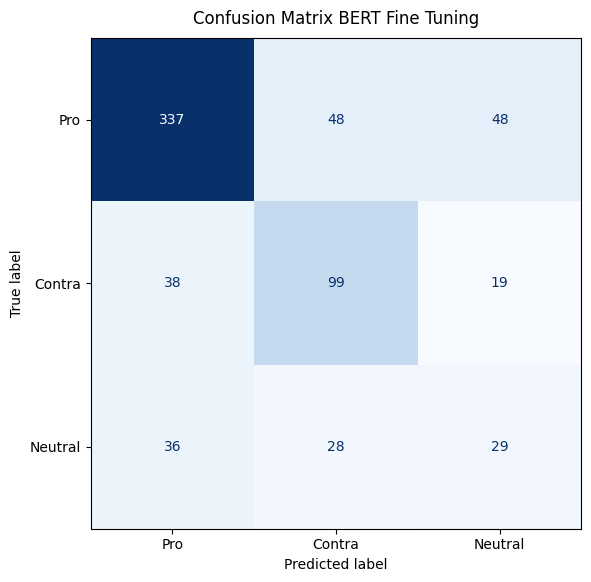

In [40]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

cm = confusion_matrix(y_true_all, y_pred_all, labels=[0,1,2])

# tampilkan
disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=['Pro','Contra','Neutral']
)
fig, ax = plt.subplots(figsize=(6,6))
disp.plot(
    ax=ax,
    cmap='Blues',
    values_format='d',
    colorbar=False  
)
plt.title('Confusion Matrix BERT Fine Tuning', pad=10)
plt.tight_layout()
plt.show()

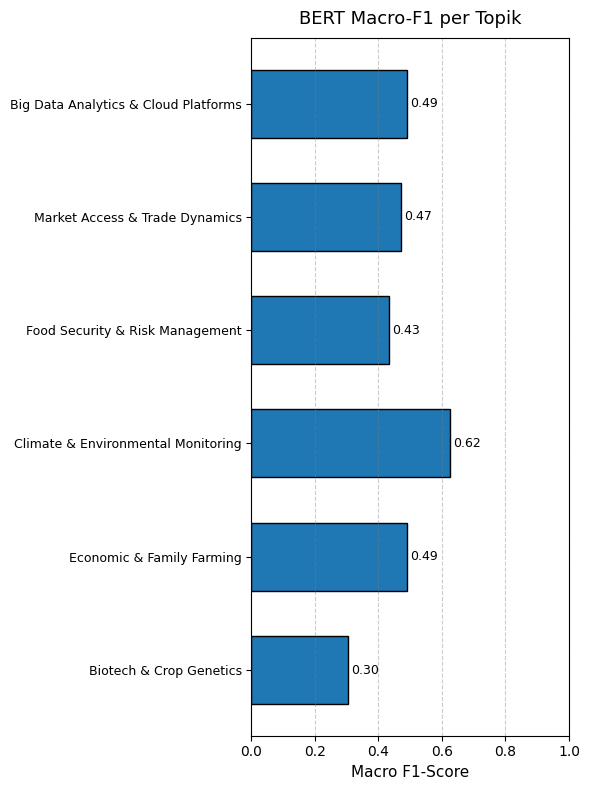

In [41]:
from sklearn.metrics import f1_score

df_preds = pd.DataFrame({
    "Topic":  topic_bert,
    "y_true": y_true_all,
    "y_pred": y_pred_all
})

scores = {}
for topic in df_preds["Topic"].unique():
    m = df_preds["Topic"] == topic
    scores[topic] = f1_score(
        df_preds.loc[m, "y_true"],
        df_preds.loc[m, "y_pred"],
        average="macro", zero_division=0
    )

# 3) Plot horizontal bar chart
topics = list(scores.keys())
f1_vals = [scores[t] for t in topics]

plt.figure(figsize=(6, 8))
y_pos = np.arange(len(topics))
plt.barh(y_pos, f1_vals, height=0.6, color="#1f77b4", edgecolor="k")
for i, v in enumerate(f1_vals):
    plt.text(v + 0.01, i, f"{v:.2f}", va="center", fontsize=9)

plt.yticks(y_pos, topics, fontsize=9)
plt.xlabel("Macro F1-Score", fontsize=11)
plt.title("BERT Macro-F1 per Topik", fontsize=13, pad=10)
plt.xlim(0, 1)
plt.grid(axis="x", linestyle="--", color="gray", alpha=0.4)
plt.tight_layout()
plt.show()

In [42]:
from scipy.special import softmax

pred_out = trainer.predict(eval_ds)
logits   = pred_out.predictions
y_pred   = np.argmax(logits, axis=1)

probs       = softmax(logits, axis=1)
confidences = np.max(probs, axis=1)

df_conf = pd.DataFrame({
    "text":        df_fold.loc[df_fold['split']=='test', 'Content_clean'].tolist(),
    "true_label":  y_true,
    "pred_label":  y_pred,
    "confidence":  confidences
})

print(df_conf.sort_values("confidence").head(10))


/Users/elisa/Documents/Final_project/data_fp/.venv/lib/python3.13/site-packages/torch/utils/data/dataloader.py:683: UserWarning: 'pin_memory' argument is set as true but not supported on MPS now, then device pinned memory won't be used.
  warnings.warn(warn_msg)


                                                  text  true_label  \
100  tory cabinet minister therese coffey booed far...           1   
74   grand amphitheater esports reminiscent forest ...           0   
85   abraham loeb know avi professor astrophysics h...           0   
121  milan dec reuters vehicle maker cnh industrial...           2   
5    mexico city april reuters mexico make immediat...           0   
96   good morning june 2022 guardian contributor do...           1   
91   portion california tulare lake blue water stre...           0   
68   artist completely focus black oil crayon hand ...           0   
13   year ago prof stephen hawk declare explosive u...           0   
83   closed beach swimmer patrol summer among contr...           0   

     pred_label  confidence  
100           0    0.391975  
74            0    0.407759  
85            0    0.415495  
121           2    0.439949  
5             2    0.443288  
96            0    0.445161  
91            2    

### 2. BERT + SVM

In [43]:
import torch
from transformers import AutoTokenizer, AutoModelForSequenceClassification, Trainer, TrainingArguments,set_seed, EarlyStoppingCallback
from imblearn.pipeline import Pipeline as ImbPipeline
from sklearn.preprocessing import StandardScaler
from imblearn.over_sampling import BorderlineSMOTE
from sklearn.svm import SVC
from sklearn.model_selection import StratifiedKFold, RandomizedSearchCV
from sklearn.metrics import classification_report, accuracy_score
from datasets import Dataset

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
tokenizer = AutoTokenizer.from_pretrained(best_ckpt, local_files_only=True)
model     = AutoModelForSequenceClassification.from_pretrained(best_ckpt, local_files_only=True)
model.to(device).eval()

def extract_cls_embeddings(texts, batch_size=32):
    all_embeds = []
    for i in range(0, len(texts), batch_size):
        batch = texts[i:i+batch_size]
        enc   = tokenizer(batch, padding=True, truncation=True,
                          max_length=128, return_tensors="pt"
                         ).to(device)
        with torch.no_grad():
            out = model.bert(input_ids=enc.input_ids,
                              attention_mask=enc.attention_mask)
            cls_emb = out.last_hidden_state[:,0,:]
        all_embeds.append(cls_emb.cpu())
    return torch.cat(all_embeds, dim=0).numpy()

X_cls = extract_cls_embeddings(texts)
y_svm = y_enc

np.save("X_bert_cls.npy", X_cls)
np.save("y_labels.npy",   y_svm)

In [44]:
import random, numpy as np
random.seed(42)
np.random.seed(42)


X = X_cls
y = y_svm


param_dist = [
    # pertama: blok untuk poly
    {
      "svm__kernel": ["poly"],
      "svm__degree": [2, 3, 4],
      "svm__C":      [1e-2, 1e-1, 1, 10, 100, 1e3],
      "svm__gamma":  ["scale", "auto", 1e-3, 1e-2, 1e-1, 1],
    },
    # kedua: blok untuk rbf + linear (degree diabaikan)
    {
      "svm__kernel": ["rbf", "linear"],
      "svm__C":      [1e-2, 1e-1, 1, 10, 100, 1e3],
      "svm__gamma":  ["scale", "auto", 1e-3, 1e-2, 1e-1, 1],
    },
]
"""
param_dist = {
    "svm__C":      [0.01, 0.1, 1, 10, 100, 1000],
    "svm__gamma":  ["scale","auto", 0.001, 0.01, 0.1, 1],
    "svm__kernel": ["rbf","sigmoid"],
}
"""
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
rows, svmacc, svm_f1s, all_svm, topic_svm = [], [], [], [], []
all_conf_svm = []
all_true_svm = []
all_conf_svm_probs = []   # list of (n_fold_samples, 3)

for fold, (train_idx, test_idx) in enumerate(skf.split(X, y), start=1):
    print(f"\n * SVM Fold {fold}")
    X_tr, X_te = X[train_idx], X[test_idx]
    y_tr, y_te = y[train_idx], y[test_idx]
    topic_svm.extend(test_idx)

    pipe_svm = ImbPipeline([
        ("scale", StandardScaler()),
        ("smote", BorderlineSMOTE(random_state=42)),
        ("svm",   SVC(class_weight="balanced", probability=True, random_state=42))
    ])

    rnd = RandomizedSearchCV(
        estimator           = pipe_svm,
        param_distributions = param_dist,
        n_iter              = 30,
        scoring             = "f1_macro",
        cv                  = 3,
        random_state        = 42,
        n_jobs              = -1,
        verbose             = 0
    )
    rnd.fit(X_tr, y_tr)
    best_svm = rnd.best_estimator_
    print(f"Best Params Fold {fold}: {rnd.best_params_}")

    y_pred = best_svm.predict(X_te)
    probs = best_svm.predict_proba(X_te)       # shape = (n_test, 3)
    conf  = probs.max(axis=1) # confidence = max probability per sample
    all_conf_svm_probs.append(probs) 

    # simpan ke list
    all_conf_svm.extend(conf)

    acc    = accuracy_score(y_te, y_pred)
    f1     = precision_recall_fscore_support(
                 y_te, y_pred, average='macro', zero_division=0
             )[2]
    svmacc.append(acc)
    svm_f1s.append(f1)
    y_pred = best_svm.predict(X_te)
    y_te   = y_te  # array asli
    all_svm.extend(y_pred)
    all_true_svm.extend(y_te)
    
    print(f" Accuracy (fold {fold}): {acc:.3f}, F1-macro: {f1:.3f}")
    print(classification_report(y_te, y_pred, target_names=["Pro","Contra","Neutral"], zero_division=0))

    import warnings
    from sklearn.exceptions import UndefinedMetricWarning

    warnings.filterwarnings(
        "ignore",
        category=UndefinedMetricWarning
    )
    
    rpt = classification_report(
        y_te, y_pred,
        target_names=["Pro","Contra","Neutral"],
        output_dict=True, zero_division=0
    )
    for cls in ["Pro","Contra","Neutral"]:
        rows.append({
            "fold":      fold,
            "class":     cls,
            "precision": rpt[cls]["precision"],
            "recall":    rpt[cls]["recall"],
            "f1-score":  rpt[cls]["f1-score"]
        })

svm_df = pd.DataFrame(rows)
svm_summary = (
    svm_df
      .groupby("class")[["precision","recall","f1-score"]]
      .agg(["mean","std"])
      .round({("precision","mean"):2,("precision","std"):3,
              ("recall","mean"):2,   ("recall","std"):3,
              ("f1-score","mean"):2, ("f1-score","std"):3})
)

sentiment_svm = (
    pd.Series(all_svm)
      .map({0:"Pro",1:"Contra",2:"Neutral"})    # sesuaikan mapping label jika perlu
      .value_counts(normalize=True)
      .rename_axis('sentiment')
      .reset_index(name='percentage')
)
sentiment_svm['percentage'] = (sentiment_svm['percentage'] * 100).round(2)

print("\n*) 5-Fold Avg BERT → SVM")
print(svm_summary)
print(f"\n*) Accuracy: mean={np.mean(svmacc):.2f}, std={np.std(svmacc):.3f}")
print(f"*) F1-macro: mean={np.mean(svm_f1s):.2f}, std={np.std(svm_f1s):.3f}")

print("\n Sentiment Distribution")
print(sentiment_svm)


 * SVM Fold 1


huggingface/tokenizers: The current process just got forked, after parallelism has already been used. Disabling parallelism to avoid deadlocks...
To disable this warning, you can either:
	- Avoid using `tokenizers` before the fork if possible
	- Explicitly set the environment variable TOKENIZERS_PARALLELISM=(true | false)
huggingface/tokenizers: The current process just got forked, after parallelism has already been used. Disabling parallelism to avoid deadlocks...
To disable this warning, you can either:
	- Avoid using `tokenizers` before the fork if possible
	- Explicitly set the environment variable TOKENIZERS_PARALLELISM=(true | false)
huggingface/tokenizers: The current process just got forked, after parallelism has already been used. Disabling parallelism to avoid deadlocks...
To disable this warning, you can either:
	- Avoid using `tokenizers` before the fork if possible
	- Explicitly set the environment variable TOKENIZERS_PARALLELISM=(true | false)
huggingface/tokenizers: The 

Best Params Fold 1: {'svm__kernel': 'rbf', 'svm__gamma': 'scale', 'svm__C': 0.1}
 Accuracy (fold 1): 0.971, F1-macro: 0.961
              precision    recall  f1-score   support

         Pro       0.98      0.98      0.98        87
      Contra       1.00      0.97      0.98        31
     Neutral       0.90      0.95      0.92        19

    accuracy                           0.97       137
   macro avg       0.96      0.96      0.96       137
weighted avg       0.97      0.97      0.97       137


 * SVM Fold 2
Best Params Fold 2: {'svm__kernel': 'rbf', 'svm__gamma': 0.001, 'svm__C': 1000.0}
 Accuracy (fold 2): 0.942, F1-macro: 0.919
              precision    recall  f1-score   support

         Pro       0.93      0.99      0.96        87
      Contra       0.94      0.91      0.92        32
     Neutral       1.00      0.78      0.88        18

    accuracy                           0.94       137
   macro avg       0.96      0.89      0.92       137
weighted avg       0.94      

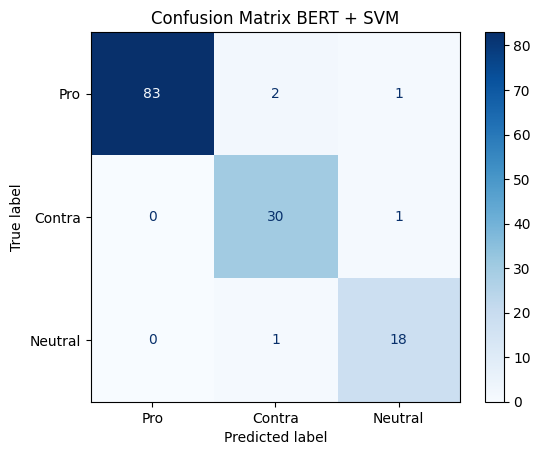

In [45]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

y_true = y_te
y_pred = best_svm.predict(X_te)

cm = confusion_matrix(y_true, y_pred, labels=[0,1,2])        # 0=Pro,1=Contra,2=Neutral
disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=["Pro","Contra","Neutral"]
)
disp.plot(
    cmap="Blues",     # atau 'Pastel1'
    values_format='d'
)
plt.title("Confusion Matrix BERT + SVM")
plt.show()

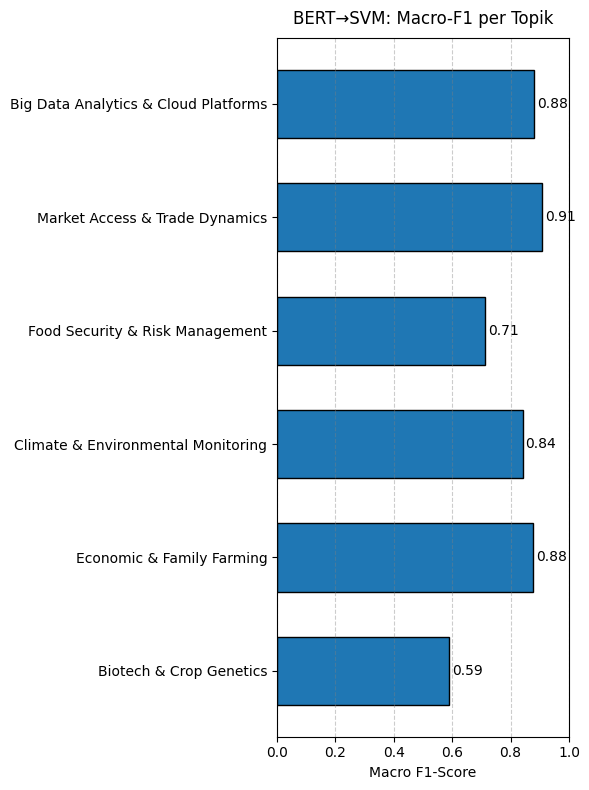

In [46]:
from sklearn.metrics import f1_score

df_preds_svm = pd.DataFrame({
    "Topic":  df.loc[topic_svm, "Topic"].reset_index(drop=True),
    "y_true": all_true_svm,
    "y_pred": all_svm
})

scores_svm = {}
for t in df_preds_svm["Topic"].unique():
    mask = df_preds_svm["Topic"] == t
    scores_svm[t] = f1_score(
        df_preds_svm.loc[mask, "y_true"],
        df_preds_svm.loc[mask, "y_pred"],
        average="macro",
        zero_division=0
    )

topics = list(scores_svm.keys())
f1_vals = [scores_svm[t] for t in topics]

plt.figure(figsize=(6,8))
y_pos = np.arange(len(topics))
plt.barh(y_pos, f1_vals, height=0.6, color="#1f77b4", edgecolor="k")
for i,v in enumerate(f1_vals):
    plt.text(v+0.01, i, f"{v:.2f}", va="center")
plt.yticks(y_pos, topics)
plt.xlabel("Macro F1-Score")
plt.title("BERT→SVM: Macro-F1 per Topik", pad=10)
plt.xlim(0,1)
plt.grid(axis="x", linestyle="--", color="gray", alpha=0.4)
plt.tight_layout()
plt.show()

In [47]:
df_conf_svm = pd.DataFrame({
    "text"       : df.loc[topic_svm, "Content_clean"].reset_index(drop=True),
    "true_label" : pd.Series(all_true_svm).map({0:"Pro",1:"Contra",2:"Neutral"}),
    "pred_label" : pd.Series(all_svm)     .map({0:"Pro",1:"Contra",2:"Neutral"}),
    "confidence" : all_conf_svm
})

print(df_conf_svm.sort_values("confidence").head(10))

                                                  text true_label pred_label  \
505  organic dairy livestock farmer seek emergency ...    Neutral     Contra   
324  time last year difficult drive large swath cen...        Pro    Neutral   
551  mexico city april reuters mexico make immediat...        Pro        Pro   
305  thousand rohingya force flee home myanmar esca...    Neutral        Pro   
91   taiwan foreign minister say prepare conflict c...        Pro    Neutral   
92   deep central australian desert sit atop dune l...    Neutral    Neutral   
71   main development today ukraine push ahead peac...     Contra        Pro   
226  russian drone launch four hour attack ukraine ...    Neutral     Contra   
411  note jakub krupa back live coverage europe tom...        Pro    Neutral   
485  elon musk post personally craft 280 character ...        Pro        Pro   

     confidence  
505    0.415752  
324    0.425406  
551    0.437507  
305    0.443420  
91     0.453411  
92     0.47

### 3. BERT + RF

In [48]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import StratifiedKFold, RandomizedSearchCV
from sklearn.metrics import classification_report, accuracy_score
import random, numpy as np
random.seed(42)
np.random.seed(42)


X = np.load("X_bert_cls.npy")   # shape (n_samples, hidden_size)
y = np.load("y_labels.npy")     # shape (n_samples,)

param_dist_rf = {
    "n_estimators": [100, 300, 500, 800, 1000],
    "max_depth": [None, 10, 20, 30, 50],
    "min_samples_leaf": [1, 2, 5],
    "min_samples_split": [2, 5, 10],
    "class_weight": ["balanced", "balanced_subsample"]
}

skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
rows, rf_accs, rf_f1s, all_rfirst, topic_rf = [], [], [], [],[]
all_conf_rf = []
all_true_rf = []
all_conf_rf_probs = [] 

for fold, (tr_idx, te_idx) in enumerate(skf.split(X, y), start=1):
    print(f"\n * RF Fold {fold} ---")
    X_tr, X_te = X[tr_idx], X[te_idx]
    y_tr, y_te = y[tr_idx], y[te_idx]
    
    pipe_rf = ImbPipeline([
        ("scale", StandardScaler()),
        ("smote", BorderlineSMOTE(random_state=42)),
        ("svm",   SVC(class_weight="balanced", probability=True, random_state=42))
    ])

    # Randomized search
    base_rf = RandomForestClassifier(random_state=42, n_jobs=-1)
    rnd = RandomizedSearchCV(
        estimator=base_rf,
        param_distributions=param_dist_rf,
        n_iter=30,
        scoring="f1_macro",
        cv=3,
        random_state=42,
        n_jobs=-1,
        verbose=0
    )
    rnd.fit(X_tr, y_tr)
    best_rf = rnd.best_estimator_
    print(f"Best Params Fold {fold}: {rnd.best_params_}")

    y_pred = best_rf.predict(X_te)
    probs = best_rf.predict_proba(X_te)       # shape = (n_test, 3)
    conf  = probs.max(axis=1)                  # confidence = max probability per sample

    # simpan ke list
    all_conf_rf.extend(conf)
    all_conf_rf_probs.append(probs)
    acc = accuracy_score(y_te, y_pred)
    p, r, f1, _ = precision_recall_fscore_support(
        y_te, y_pred, average='macro', zero_division=0
    )
    rf_accs.append(acc)
    rf_f1s.append(f1)
    all_rfirst.extend(y_pred)
    all_true_rf.extend(y_te)
    topic_rf.extend(te_idx)
    print(f"Accuracy (fold {fold}): {acc:.3f}, F1-macro: {f1:.3f}")
    print(classification_report(y_te, y_pred, target_names=["Pro","Contra","Neutral"], zero_division=0))

    # classification report
    rpt = classification_report(
        y_te, y_pred,
        target_names=["Pro","Contra","Neutral"],
        output_dict=True, zero_division=0
    )
    for cls in ["Pro","Contra","Neutral"]:
        rows.append({
            "fold": fold,
            "class": cls,
            "precision": rpt[cls]["precision"],
            "recall":    rpt[cls]["recall"],
            "f1-score":  rpt[cls]["f1-score"]
        })

rf_df = pd.DataFrame(rows)
rf_summary = (
    rf_df
      .groupby("class")[["precision","recall","f1-score"]]
      .agg(["mean","std"])
      # round: mean=2, std=3
      .round({
         ("precision","mean"): 2, ("precision","std"): 3,
         ("recall",   "mean"): 2, ("recall",   "std"): 3,
         ("f1-score", "mean"): 2, ("f1-score", "std"): 3
      })
)

sentiment_rf = (
    pd.Series(all_rfirst)
      .map({0:"Pro",1:"Contra",2:"Neutral"})    # sesuaikan mapping label jika perlu
      .value_counts(normalize=True)
      .rename_axis('sentiment')
      .reset_index(name='percentage')
)
sentiment_rf['percentage'] = (sentiment_rf['percentage'] * 100).round(2)

print("\n*) 5-Fold Avg RF:")
print(rf_summary)
print(f"\n*) Accuracy RF: mean={np.mean(rf_accs):.2f}, std={np.std(rf_accs):.3f}")
print(f"*) F1-macro RF: mean={np.mean(rf_f1s):.2f}, std={np.std(rf_f1s):.3f}")

print("\n*) Sentiment distribution (RF):")
print(sentiment_rf)


 * RF Fold 1 ---
Best Params Fold 1: {'n_estimators': 100, 'min_samples_split': 2, 'min_samples_leaf': 5, 'max_depth': None, 'class_weight': 'balanced'}
Accuracy (fold 1): 0.978, F1-macro: 0.969
              precision    recall  f1-score   support

         Pro       0.99      0.98      0.98        87
      Contra       1.00      1.00      1.00        31
     Neutral       0.90      0.95      0.92        19

    accuracy                           0.98       137
   macro avg       0.96      0.97      0.97       137
weighted avg       0.98      0.98      0.98       137


 * RF Fold 2 ---
Best Params Fold 2: {'n_estimators': 100, 'min_samples_split': 2, 'min_samples_leaf': 5, 'max_depth': None, 'class_weight': 'balanced'}
Accuracy (fold 2): 0.942, F1-macro: 0.924
              precision    recall  f1-score   support

         Pro       0.97      0.95      0.96        87
      Contra       0.91      0.94      0.92        32
     Neutral       0.89      0.89      0.89        18

    accur

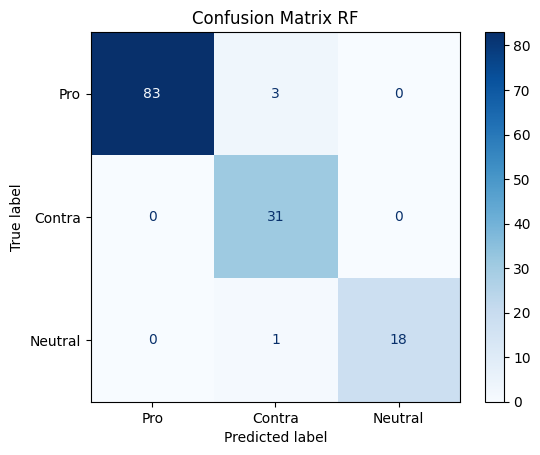

In [49]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

y_true = y_te
y_pred = best_rf.predict(X_te)

cm = confusion_matrix(y_true, y_pred, labels=[0,1,2])        # 0=Pro,1=Contra,2=Neutral
disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=["Pro","Contra","Neutral"]
)
disp.plot(
    cmap="Blues",     # atau 'Pastel1'
    values_format='d'
)
plt.title("Confusion Matrix RF")
plt.show()

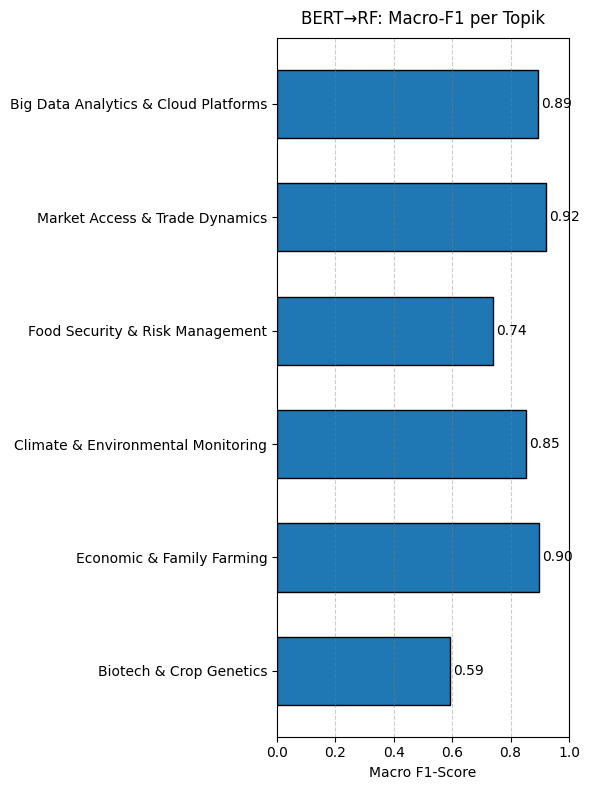

In [50]:
topics_test = df.loc[topic_rf, "Topic"].reset_index(drop=True)

df_preds_rf = pd.DataFrame({
    "Topic": topics_test,
    "y_true": all_true_rf,
    "y_pred": all_rfirst
})

from sklearn.metrics import f1_score
scores_rf = {}
for t in df_preds_rf["Topic"].unique():
    mask = df_preds_rf["Topic"] == t
    scores_rf[t] = f1_score(
        df_preds_rf.loc[mask, "y_true"],
        df_preds_rf.loc[mask, "y_pred"],
        average="macro",
        zero_division=0
    )


topics  = list(scores_rf.keys())
f1_vals = [scores_rf[t] for t in topics]

plt.figure(figsize=(6,8))
y_pos = np.arange(len(topics))
plt.barh(y_pos, f1_vals, height=0.6, color="#1f77b4", edgecolor="k")
for i,v in enumerate(f1_vals):
    plt.text(v+0.01, i, f"{v:.2f}", va="center")
plt.yticks(y_pos, topics)
plt.xlabel("Macro F1-Score")
plt.title("BERT→RF: Macro-F1 per Topik", pad=10)
plt.xlim(0,1)
plt.grid(axis="x", linestyle="--", color="gray", alpha=0.4)
plt.tight_layout()
plt.show()

In [51]:
df_conf_rf = pd.DataFrame({
    "text"       : df.loc[topic_rf, "Content_clean"].reset_index(drop=True),
    "true_label" : pd.Series(all_true_rf).map({0:"Pro",1:"Contra",2:"Neutral"}),
    "pred_label" : pd.Series(all_rfirst)     .map({0:"Pro",1:"Contra",2:"Neutral"}),
    "confidence" : all_conf_rf
})

print(df_conf_rf.sort_values("confidence").head(10))

                                                  text true_label pred_label  \
208  blog closing summary today story kremlin claim...    Neutral        Pro   
411  note jakub krupa back live coverage europe tom...        Pro    Neutral   
337  drone fly silently western myanmar chin hill j...     Contra    Neutral   
313  chinese army debut late weapon gun tot robotic...    Neutral        Pro   
356  african head state minister leader campaigner ...        Pro        Pro   
91   taiwan foreign minister say prepare conflict c...        Pro        Pro   
324  time last year difficult drive large swath cen...        Pro        Pro   
512  robot arrive california field summer self driv...        Pro        Pro   
673  kate darling research specialist human robot i...     Contra     Contra   
406  may worst keep secret australian fashion count...        Pro        Pro   

     confidence  
208    0.360970  
411    0.361490  
337    0.379356  
313    0.388139  
356    0.425629  
91     0.45

### 4. BERT + XGBoost

In [52]:
import random, numpy as np
random.seed(42)
np.random.seed(42)
from xgboost import XGBClassifier
from sklearn.model_selection import StratifiedKFold, RandomizedSearchCV
from sklearn.metrics import classification_report, accuracy_score, precision_recall_fscore_support
from sklearn.preprocessing import StandardScaler
from imblearn.pipeline import Pipeline as ImbPipeline
from imblearn.over_sampling import BorderlineSMOTE

X = np.load("X_bert_cls.npy")   # shape (n_samples, hidden_size)
y = np.load("y_labels.npy")     # shape (n_samples,)

param_dist_xgb = {
    "n_estimators":    [100, 300, 500, 800, 1000],
    "max_depth":       [3, 5, 7, 9],
    "learning_rate":   [0.01, 0.05, 0.1, 0.2],
    "subsample":       [0.6, 0.8, 1.0],
    "colsample_bytree":[0.6, 0.8, 1.0],
    "scale_pos_weight":[1, 2, 5]
}

skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

rows_xgb           = []
xgb_accs           = []
xgb_f1s            = []
all_pred_xgb       = []
topic_xgb          = []
all_conf_xgb       = []
all_conf_xgb_probs = []
all_true_xgb       = []

for fold, (tr_idx, te_idx) in enumerate(skf.split(X, y), start=1):
    print(f"\n * XGB Fold {fold} ---")
    X_tr, X_te = X[tr_idx], X[te_idx]
    y_tr, y_te = y[tr_idx], y[te_idx]

    pipe_xgb = ImbPipeline([
        ("scale", StandardScaler()),
        ("smote", BorderlineSMOTE(random_state=42)),
        ("xgb", XGBClassifier(
            objective="multi:softprob",
            eval_metric="mlogloss",
            random_state=42,
            n_jobs=-1
        ))
    ])

    rnd = RandomizedSearchCV(
        estimator=pipe_xgb,
        param_distributions={
            f"xgb__{k}": v for k, v in param_dist_xgb.items()
        },
        n_iter=30,
        scoring="f1_macro",
        cv=3,
        random_state=42,
        n_jobs=-1,
        verbose=0
    )
    rnd.fit(X_tr, y_tr)
    print(f"Best Params Fold {fold}: {rnd.best_params_}")

    best_xgb = rnd.best_estimator_
    y_pred   = best_xgb.predict(X_te)
    probs    = best_xgb.predict_proba(X_te)   # shape = (n_test, 3)
    conf     = probs.max(axis=1)

    all_conf_xgb.extend(conf)
    all_conf_xgb_probs.append(probs)
    all_pred_xgb.extend(y_pred)
    all_true_xgb.extend(y_te)
    topic_xgb.extend(te_idx)

    acc = accuracy_score(y_te, y_pred)
    p, r, f1, _ = precision_recall_fscore_support(
        y_te, y_pred, average="macro", zero_division=0
    )
    xgb_accs.append(acc)
    xgb_f1s.append(f1)

    print(f"Accuracy (fold {fold}): {acc:.3f}, F1-macro: {f1:.3f}")
    print(classification_report(
        y_te, y_pred,
        target_names=["Pro","Contra","Neutral"],
        zero_division=0
    ))

    rpt = classification_report(
        y_te, y_pred,
        target_names=["Pro","Contra","Neutral"],
        output_dict=True, zero_division=0
    )
    for cls in ["Pro","Contra","Neutral"]:
        rows_xgb.append({
            "fold":      fold,
            "class":     cls,
            "precision": rpt[cls]["precision"],
            "recall":    rpt[cls]["recall"],
            "f1-score":  rpt[cls]["f1-score"]
        })

xgb_df = pd.DataFrame(rows_xgb)
xgb_summary = (
    xgb_df
      .groupby("class")[["precision","recall","f1-score"]]
      .agg(["mean","std"])
      .round(3)
)

sentiment_xgb = (
    pd.Series(all_pred_xgb)
      .map({0:"Pro",1:"Contra",2:"Neutral"})
      .value_counts(normalize=True)
      .rename_axis("sentiment")
      .reset_index(name="percentage")
)
sentiment_xgb["percentage"] = (sentiment_xgb["percentage"] * 100).round(2)

# 10) Print summaries
print("\n*) 5-Fold Avg XGBoost:")
print(xgb_summary)
print(f"\n*) Accuracy XGB: mean={np.mean(xgb_accs):.2f}, std={np.std(xgb_accs):.3f}")
print(f"*) F1-macro XGB: mean={np.mean(xgb_f1s):.2f}, std={np.std(xgb_f1s):.3f}")

print("\n*) Sentiment distribution (XGB):")
print(sentiment_xgb)


 * XGB Fold 1 ---


/Users/elisa/Documents/Final_project/data_fp/.venv/lib/python3.13/site-packages/xgboost/training.py:183: UserWarning: [18:39:56] WARNING: /Users/runner/work/xgboost/xgboost/src/learner.cc:738: 
Parameters: { "scale_pos_weight" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/Users/elisa/Documents/Final_project/data_fp/.venv/lib/python3.13/site-packages/xgboost/training.py:183: UserWarning: [18:39:56] WARNING: /Users/runner/work/xgboost/xgboost/src/learner.cc:738: 
Parameters: { "scale_pos_weight" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/Users/elisa/Documents/Final_project/data_fp/.venv/lib/python3.13/site-packages/xgboost/training.py:183: UserWarning: [18:39:56] WARNING: /Users/runner/work/xgboost/xgboost/src/learner.cc:738: 
Parameters: { "scale_pos_weight" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/Users/elisa/Documents/Final_project/data_fp/.venv/lib/python3.13/site-packages/xgboost/training.py:183: UserWarning: [18:39:56] WARNING

Best Params Fold 1: {'xgb__subsample': 1.0, 'xgb__scale_pos_weight': 1, 'xgb__n_estimators': 1000, 'xgb__max_depth': 7, 'xgb__learning_rate': 0.2, 'xgb__colsample_bytree': 0.6}
Accuracy (fold 1): 0.956, F1-macro: 0.936
              precision    recall  f1-score   support

         Pro       0.95      0.99      0.97        87
      Contra       1.00      0.97      0.98        31
     Neutral       0.94      0.79      0.86        19

    accuracy                           0.96       137
   macro avg       0.96      0.92      0.94       137
weighted avg       0.96      0.96      0.96       137


 * XGB Fold 2 ---


/Users/elisa/Documents/Final_project/data_fp/.venv/lib/python3.13/site-packages/xgboost/training.py:183: UserWarning: [18:41:42] WARNING: /Users/runner/work/xgboost/xgboost/src/learner.cc:738: 
Parameters: { "scale_pos_weight" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/Users/elisa/Documents/Final_project/data_fp/.venv/lib/python3.13/site-packages/xgboost/training.py:183: UserWarning: [18:41:42] WARNING: /Users/runner/work/xgboost/xgboost/src/learner.cc:738: 
Parameters: { "scale_pos_weight" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/Users/elisa/Documents/Final_project/data_fp/.venv/lib/python3.13/site-packages/xgboost/training.py:183: UserWarning: [18:41:42] WARNING: /Users/runner/work/xgboost/xgboost/src/learner.cc:738: 
Parameters: { "scale_pos_weight" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/Users/elisa/Documents/Final_project/data_fp/.venv/lib/python3.13/site-packages/xgboost/training.py:183: UserWarning: [18:41:42] WARNING

Best Params Fold 2: {'xgb__subsample': 0.8, 'xgb__scale_pos_weight': 5, 'xgb__n_estimators': 500, 'xgb__max_depth': 9, 'xgb__learning_rate': 0.2, 'xgb__colsample_bytree': 0.8}
Accuracy (fold 2): 0.927, F1-macro: 0.898
              precision    recall  f1-score   support

         Pro       0.94      0.95      0.95        87
      Contra       0.91      0.94      0.92        32
     Neutral       0.88      0.78      0.82        18

    accuracy                           0.93       137
   macro avg       0.91      0.89      0.90       137
weighted avg       0.93      0.93      0.93       137


 * XGB Fold 3 ---


...

Best Params Fold 3: {'xgb__subsample': 0.6, 'xgb__scale_pos_weight': 5, 'xgb__n_estimators': 1000, 'xgb__max_depth': 9, 'xgb__learning_rate': 0.2, 'xgb__colsample_bytree': 1.0}
Accuracy (fold 3): 0.743, F1-macro: 0.610
              precision    recall  f1-score   support

         Pro       0.85      0.87      0.86        87
      Contra       0.59      0.61      0.60        31
     Neutral       0.40      0.33      0.36        18

    accuracy                           0.74       136
   macro avg       0.62      0.61      0.61       136
weighted avg       0.73      0.74      0.74       136


 * XGB Fold 4 ---


/Users/elisa/Documents/Final_project/data_fp/.venv/lib/python3.13/site-packages/xgboost/training.py:183: UserWarning: [18:44:31] WARNING: /Users/runner/work/xgboost/xgboost/src/learner.cc:738: 
Parameters: { "scale_pos_weight" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/Users/elisa/Documents/Final_project/data_fp/.venv/lib/python3.13/site-packages/xgboost/training.py:183: UserWarning: [18:44:31] WARNING: /Users/runner/work/xgboost/xgboost/src/learner.cc:738: 
Parameters: { "scale_pos_weight" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/Users/elisa/Documents/Final_project/data_fp/.venv/lib/python3.13/site-packages/xgboost/training.py:183: UserWarning: [18:44:31] WARNING: /Users/runner/work/xgboost/xgboost/src/learner.cc:738: 
Parameters: { "scale_pos_weight" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/Users/elisa/Documents/Final_project/data_fp/.venv/lib/python3.13/site-packages/xgboost/training.py:183: UserWarning: [18:44:31] WARNING

Best Params Fold 4: {'xgb__subsample': 0.6, 'xgb__scale_pos_weight': 5, 'xgb__n_estimators': 800, 'xgb__max_depth': 3, 'xgb__learning_rate': 0.1, 'xgb__colsample_bytree': 0.8}
Accuracy (fold 4): 0.985, F1-macro: 0.985
              precision    recall  f1-score   support

         Pro       0.99      0.99      0.99        86
      Contra       0.97      0.97      0.97        31
     Neutral       1.00      1.00      1.00        19

    accuracy                           0.99       136
   macro avg       0.99      0.99      0.99       136
weighted avg       0.99      0.99      0.99       136


 * XGB Fold 5 ---


/Users/elisa/Documents/Final_project/data_fp/.venv/lib/python3.13/site-packages/xgboost/training.py:183: UserWarning: [18:46:12] WARNING: /Users/runner/work/xgboost/xgboost/src/learner.cc:738: 
Parameters: { "scale_pos_weight" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/Users/elisa/Documents/Final_project/data_fp/.venv/lib/python3.13/site-packages/xgboost/training.py:183: UserWarning: [18:46:12] WARNING: /Users/runner/work/xgboost/xgboost/src/learner.cc:738: 
Parameters: { "scale_pos_weight" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/Users/elisa/Documents/Final_project/data_fp/.venv/lib/python3.13/site-packages/xgboost/training.py:183: UserWarning: [18:46:12] WARNING: /Users/runner/work/xgboost/xgboost/src/learner.cc:738: 
Parameters: { "scale_pos_weight" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/Users/elisa/Documents/Final_project/data_fp/.venv/lib/python3.13/site-packages/xgboost/training.py:183: UserWarning: [18:46:12] WARNING

Best Params Fold 5: {'xgb__subsample': 0.6, 'xgb__scale_pos_weight': 2, 'xgb__n_estimators': 100, 'xgb__max_depth': 7, 'xgb__learning_rate': 0.2, 'xgb__colsample_bytree': 1.0}
Accuracy (fold 5): 0.963, F1-macro: 0.961
              precision    recall  f1-score   support

         Pro       0.99      0.95      0.97        86
      Contra       0.91      0.97      0.94        31
     Neutral       0.95      1.00      0.97        19

    accuracy                           0.96       136
   macro avg       0.95      0.97      0.96       136
weighted avg       0.96      0.96      0.96       136


*) 5-Fold Avg XGBoost:
        precision        recall        f1-score       
             mean    std   mean    std     mean    std
class                                                 
Contra      0.876  0.163  0.891  0.156    0.883  0.158
Neutral     0.832  0.246  0.780  0.272    0.804  0.257
Pro         0.944  0.055  0.952  0.047    0.947  0.049

*) Accuracy XGB: mean=0.91, std=0.088
*) F1-ma

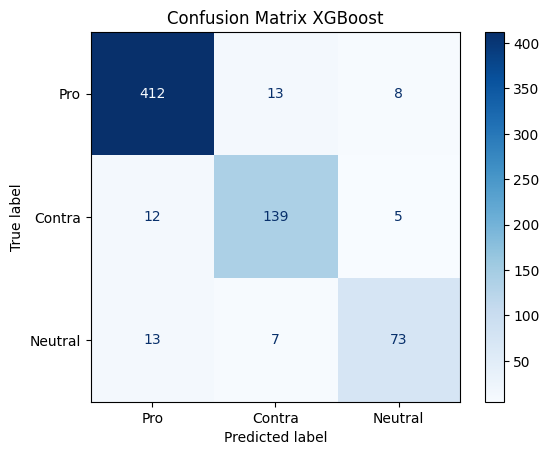

In [53]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

y_true = all_true_xgb
y_pred = all_pred_xgb

cm = confusion_matrix(y_true, y_pred, labels=[0,1,2])  # 0=Pro,1=Contra,2=Neutral
disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=["Pro","Contra","Neutral"]
)
disp.plot(cmap="Blues", values_format='d')
plt.title("Confusion Matrix XGBoost")
plt.show()

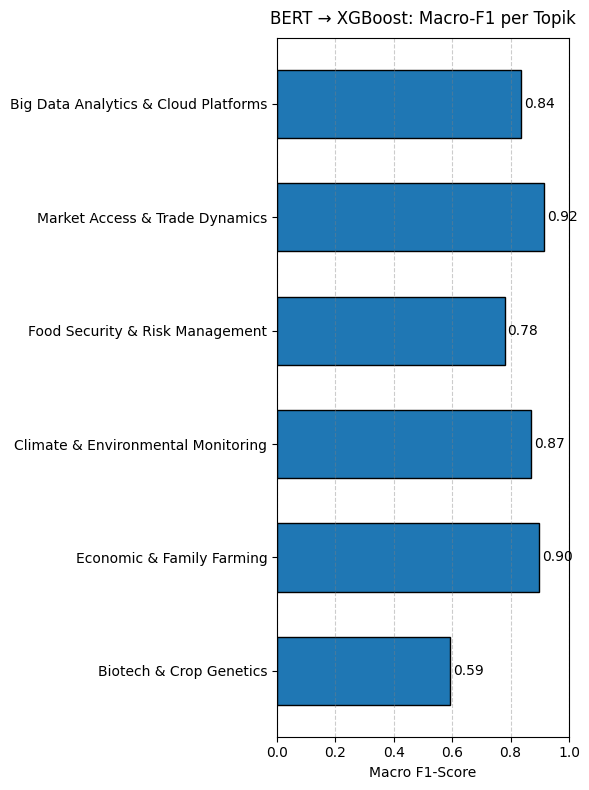

In [54]:
from sklearn.metrics import f1_score

topics_test = df.loc[topic_xgb, "Topic"].reset_index(drop=True)
df_preds_xgb = pd.DataFrame({
    "Topic":   topics_test,
    "y_true":  all_true_xgb,
    "y_pred":  all_pred_xgb
})

scores_xgb = {}
for t in df_preds_xgb["Topic"].unique():
    mask = df_preds_xgb["Topic"] == t
    scores_xgb[t] = f1_score(
        df_preds_xgb.loc[mask, "y_true"],
        df_preds_xgb.loc[mask, "y_pred"],
        average="macro",
        zero_division=0
    )

topics = list(scores_xgb.keys())
f1_vals = [scores_xgb[t] for t in topics]

y_pos = np.arange(len(topics))
plt.figure(figsize=(6,8))
plt.barh(y_pos, f1_vals, height=0.6, edgecolor="k")
for i, v in enumerate(f1_vals):
    plt.text(v + 0.01, i, f"{v:.2f}", va="center")

plt.yticks(y_pos, topics)
plt.xlabel("Macro F1-Score")
plt.title("BERT → XGBoost: Macro-F1 per Topik", pad=10)
plt.xlim(0,1)
plt.grid(axis="x", linestyle="--", color="gray", alpha=0.4)
plt.tight_layout()
plt.show()

In [55]:
df_conf_xgb = pd.DataFrame({
    "text":       df.loc[topic_xgb, "Content_clean"].reset_index(drop=True),
    "true_label": pd.Series(all_true_xgb).map({0:"Pro",1:"Contra",2:"Neutral"}),
    "pred_label": pd.Series(all_pred_xgb).map({0:"Pro",1:"Contra",2:"Neutral"}),
    "confidence": all_conf_xgb
})

print(df_conf_xgb.sort_values("confidence").head(10))

                                                  text true_label pred_label  \
557  ambitious attempt develop early warning system...        Pro     Contra   
313  chinese army debut late weapon gun tot robotic...    Neutral        Pro   
91   taiwan foreign minister say prepare conflict c...        Pro        Pro   
356  african head state minister leader campaigner ...        Pro     Contra   
324  time last year difficult drive large swath cen...        Pro    Neutral   
606  russia mobilise 000 100 recruit arm force ever...     Contra     Contra   
505  organic dairy livestock farmer seek emergency ...    Neutral    Neutral   
596  somerset level farmer say land could become un...     Contra     Contra   
136  giant bike travel mule track tractor turn mark...    Neutral        Pro   
337  drone fly silently western myanmar chin hill j...     Contra    Neutral   

     confidence  
557    0.384784  
313    0.410318  
91     0.422692  
356    0.494032  
324    0.494071  
606    0.50

### Comparasion 4 Article Model

In [56]:
comparison = pd.DataFrame({
    "method": [
        "BERT Fine-Tuning",
        "BERT + SVM",
        "BERT + Random Forest",
        "BERT + XGBoost"
    ],
    "accuracy": [
        bert_accuracy["accuracy"].mean(),
        np.mean(svmacc),
        np.mean(rf_accs),
        np.mean(xgb_accs)
    ],
    "std_accuracy": [
        bert_accuracy["accuracy"].std(),
        np.std(svmacc),
        np.std(rf_accs),
        np.std(xgb_accs)
    ],
    "f1_score": [
        bert_accuracy["f1_macro"].mean(),
        np.mean(svm_f1s),
        np.mean(rf_f1s),
        np.mean(xgb_f1s)
    ],
    "std_f1_score": [
        bert_accuracy["f1_macro"].std(),
        np.std(svm_f1s),
        np.std(rf_f1s),
        np.std(xgb_f1s)
    ]
}).round({
    "accuracy": 2, "std_accuracy": 3,
    "f1_score": 2, "std_f1_score": 3
})

print("\n*) Comparison Article Sentiment Method:\n")
print(comparison)


*) Comparison Article Sentiment Method:

                 method  accuracy  std_accuracy  f1_score  std_f1_score
0      BERT Fine-Tuning      0.68         0.025      0.57         0.046
1            BERT + SVM      0.91         0.096      0.87         0.160
2  BERT + Random Forest      0.92         0.084      0.88         0.146
3        BERT + XGBoost      0.91         0.088      0.88         0.137


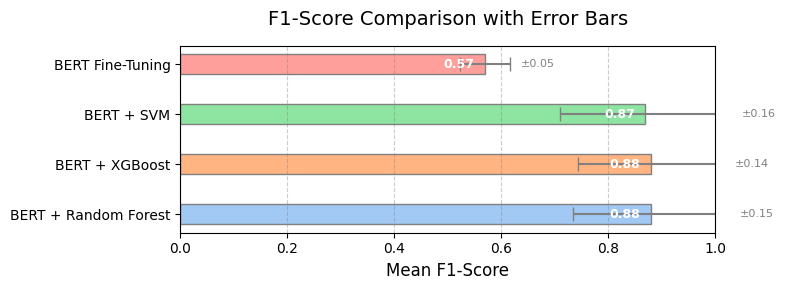

In [57]:
import seaborn as sns

comp_sorted = comparison.sort_values("f1_score", ascending=False).reset_index(drop=True)
y_pos      = np.arange(len(comp_sorted))

palette = sns.color_palette("pastel", len(comp_sorted))

plt.figure(figsize=(8, 3))
bars = plt.barh(
    y_pos,
    comp_sorted["f1_score"],
    xerr=comp_sorted["std_f1_score"],
    height=0.4,
    color=palette,         # <-- pastel palette
    edgecolor="gray",
    error_kw={'elinewidth':1.5, 'ecolor':'gray', 'capsize':5}
)

for bar, mean in zip(bars, comp_sorted["f1_score"]):
    plt.text(
        mean - 0.02,
        bar.get_y() + bar.get_height()/2,
        f"{mean:.2f}",
        va='center', ha='right',
        color='white', fontsize=9, fontweight='bold'
    )

for i, std in enumerate(comp_sorted["std_f1_score"]):
    mean = comp_sorted.loc[i, "f1_score"]
    plt.text(
        mean + std + 0.02,
        y_pos[i],
        f"±{std:.2f}",
        va='center', ha='left',
        color='gray', fontsize=8
    )

plt.yticks(y_pos, comp_sorted["method"], fontsize=10)
plt.xlabel("Mean F1-Score", fontsize=12)
plt.title("F1-Score Comparison with Error Bars", fontsize=14, pad=15)
plt.xlim(0, 1)
plt.xticks(np.arange(0, 1.1, 0.2))
plt.grid(axis='x', linestyle='--', color='gray', alpha=0.4)
plt.tight_layout()
plt.show()




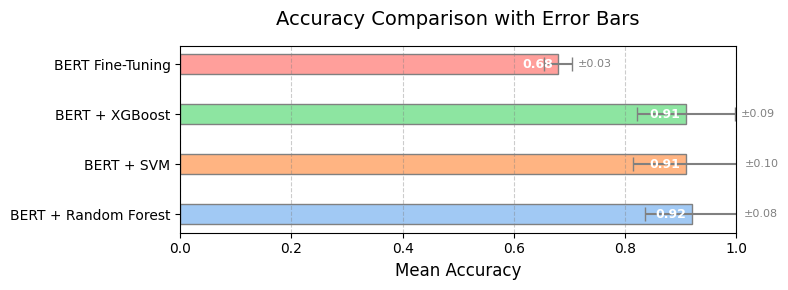

In [58]:
acc_sorted = comparison.sort_values("accuracy", ascending=False).reset_index(drop=True)
y_pos = np.arange(len(acc_sorted))

palette = sns.color_palette("pastel", len(acc_sorted))  

plt.figure(figsize=(8, 3))
bars = plt.barh(
    y_pos,
    acc_sorted["accuracy"],
    xerr=acc_sorted["std_accuracy"],
    height=0.4,
    color=palette,
    edgecolor="gray",
    error_kw={'elinewidth':1.5, 'ecolor':'gray', 'capsize':5}
)

for bar, mean in zip(bars, acc_sorted["accuracy"]):
    plt.text(
        mean - 0.01,
        bar.get_y() + bar.get_height()/2,
        f"{mean:.2f}",
        va='center', ha='right',
        color='white', fontsize=9, fontweight='bold'
    )

for i, std in enumerate(acc_sorted["std_accuracy"]):
    mean = acc_sorted.loc[i, "accuracy"]
    plt.text(
        mean + std + 0.01,
        y_pos[i],
        f"±{std:.2f}",
        va='center', ha='left',
        color='gray', fontsize=8
    )

plt.yticks(y_pos, acc_sorted["method"], fontsize=10)
plt.xlabel("Mean Accuracy", fontsize=12)
plt.title("Accuracy Comparison with Error Bars", fontsize=14, pad=15)
plt.xlim(0, 1)
plt.xticks(np.arange(0, 1.1, 0.2))
plt.grid(axis='x', linestyle='--', color='gray', alpha=0.4)
plt.tight_layout()
plt.show()



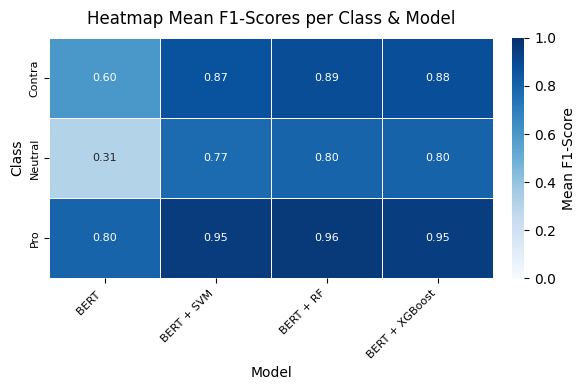

In [59]:
import seaborn as sns

f1_matrix = pd.DataFrame({
    'BERT ': article_bert_summary[('f1-score','mean')],
    'BERT + SVM': svm_summary[('f1-score','mean')],
    'BERT + RF':  rf_summary[  ('f1-score','mean')],
    'BERT + XGBoost':  xgb_summary[  ('f1-score','mean')]
    
})


plt.figure(figsize=(6, 4))
ax = sns.heatmap(
    f1_matrix,
    annot=True, fmt=".2f",
    cmap="Blues",
    vmin=0, vmax=1,
    linewidths=0.5, linecolor="white",
    cbar_kws={"fraction":0.045, "pad":0.04, "label":"Mean F1-Score"},
    annot_kws={"fontsize":8}
)
ax.set_xlabel("Model", fontsize=10)
ax.set_ylabel("Class", fontsize=10)
ax.set_title("Heatmap Mean F1-Scores per Class & Model", fontsize=12, pad=10)
plt.xticks(rotation=45, ha="right", fontsize=8)
plt.yticks(fontsize=8)
plt.tight_layout()
plt.show()



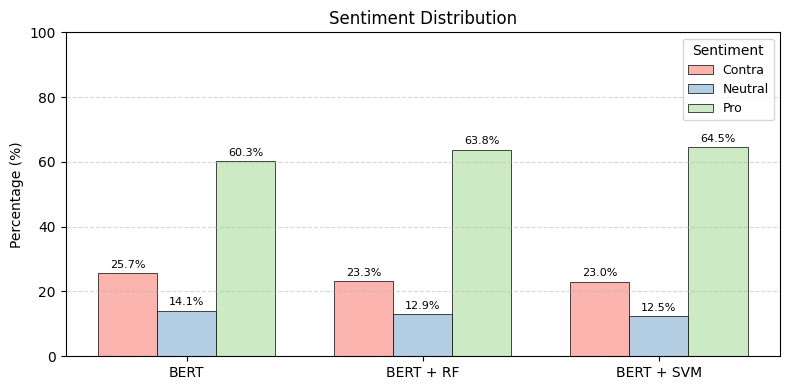

In [60]:
sentiment_bert['method'] = 'BERT'
sentiment_svm['method']  = 'BERT + SVM'
sentiment_rf['method']   = 'BERT + RF'
sentiment_xgb['method']   = 'BERT + XGBoost'

dist_df = pd.concat(
    [sentiment_bert, sentiment_svm, sentiment_rf],
    ignore_index=True
)
dist_by_method = dist_df.pivot(
    index='method',
    columns='sentiment',
    values='percentage'
)

methods    = dist_by_method.index.tolist()   
sentiments = dist_by_method.columns.tolist() 
x = np.arange(len(methods))
width = 0.25

colors = plt.get_cmap("Pastel1").colors[:len(sentiments)]

plt.figure(figsize=(8, 4))
for i, (sent, color) in enumerate(zip(sentiments, colors)):
    vals = dist_by_method[sent]
    bars = plt.bar(
        x + i*width,
        vals,
        width,
        label=sent,
        color=color,
        edgecolor="k",
        linewidth=0.5
    )
    # Anotasi persentase
    for bar in bars:
        h = bar.get_height()
        plt.text(
            bar.get_x() + bar.get_width()/2,
            h + 1,
            f"{h:.1f}%",
            ha="center", va="bottom",
            fontsize=8
        )

plt.xticks(x + width*(len(sentiments)-1)/2, methods, rotation=0)
plt.ylabel("Percentage (%)")
plt.title("Sentiment Distribution")
plt.ylim(0, 100)
plt.grid(axis='y', linestyle='--', alpha=0.5)
plt.legend(title="Sentiment", fontsize=9, title_fontsize=10, loc='upper right')
plt.tight_layout()
plt.show()


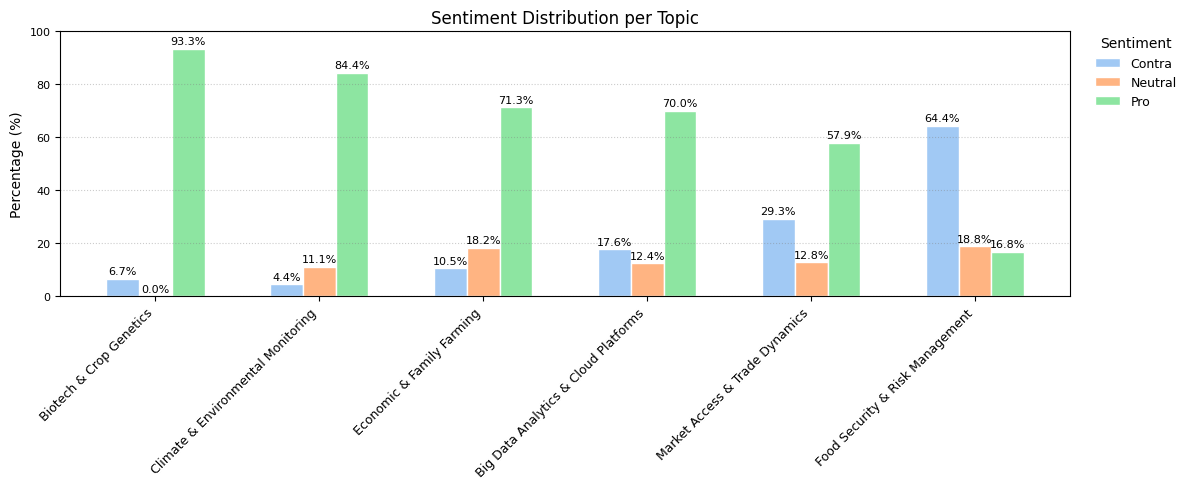

In [61]:
ct = df.groupby(['Topic','Sentiment_Label']).size().reset_index(name='count')
total = ct.groupby('Topic')['count'].transform('sum')
ct['percentage'] = ct['count'] / total * 100
pivot = (ct
         .pivot(index='Topic', columns='Sentiment_Label', values='percentage')
         .fillna(0)
         .sort_values('Pro', ascending=False))

topics     = pivot.index.tolist()
sentiments = pivot.columns.tolist()
x          = np.arange(len(topics))
bar_width  = 0.2
palette    = sns.color_palette("pastel", n_colors=len(sentiments))

plt.figure(figsize=(12,5))

for i, sent in enumerate(sentiments):
    vals = pivot[sent].values
    bars = plt.bar(
        x + i*bar_width,
        vals,
        bar_width,
        label=sent,
        color=palette[i],
        edgecolor="white"
    )
    # annotate each bar
    for bar in bars:
        h = bar.get_height()
        plt.text(
            bar.get_x() + bar.get_width()/2,
            h + 1,
            f"{h:.1f}%",
            ha="center",
            va="bottom",
            fontsize=8
        )

plt.xticks(x + bar_width*(len(sentiments)-1)/2, topics, rotation=45, ha="right", fontsize=9)
plt.ylim(0,100)
plt.yticks(np.arange(0,101,20), fontsize=8)
plt.ylabel("Percentage (%)", fontsize=10)
plt.title("Sentiment Distribution per Topic", fontsize=12)
plt.grid(axis='y', linestyle=':', color='gray', alpha=0.4)

plt.legend(
    title="Sentiment",
    fontsize=9,
    title_fontsize=10,
    loc="upper left",
    bbox_to_anchor=(1.02, 1),   # just to the right of the axes
    borderaxespad=0,            # no padding between axes and legend
    frameon=False
)

plt.tight_layout()
plt.show()

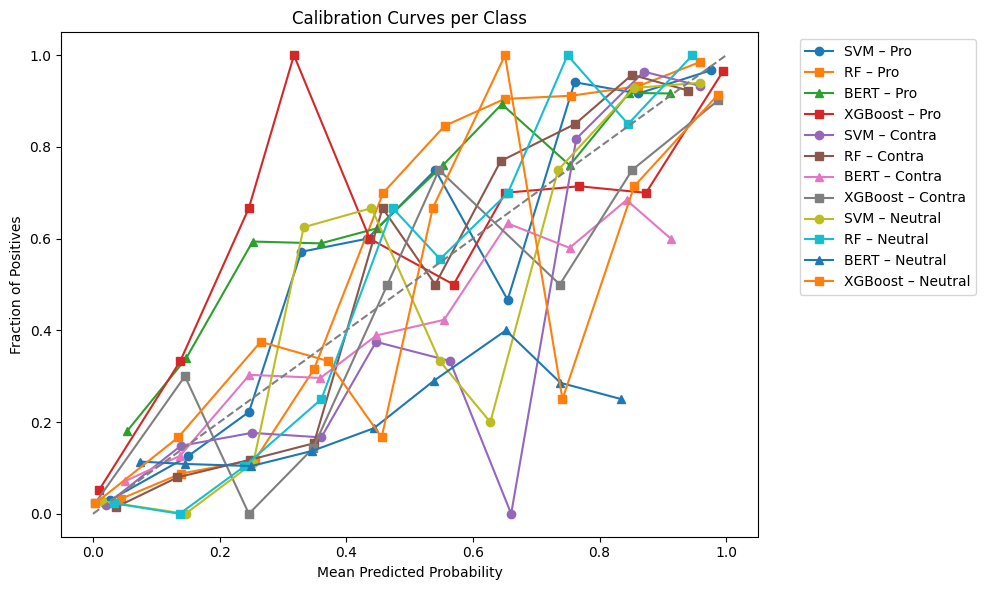

Brier SVM per class: {'Pro': np.float64(0.05284665633309081), 'Contra': np.float64(0.04529376090588837), 'Neutral': np.float64(0.041558060712190543)} → mean: 0.04656615931705657
Brier RF  per class: {'Pro': np.float64(0.056406758784069554), 'Contra': np.float64(0.04646893494971754), 'Neutral': np.float64(0.04152620798381914)} → mean: 0.048133967239202075
Brier BERT per class: {'Pro': np.float64(0.18642523455019724), 'Contra': np.float64(0.13550514336367234), 'Neutral': np.float64(0.14095625660465938)} → mean: 0.15429554483950966
Brier XGBoost  per class: {'Pro': np.float64(0.05570839107640235), 'Contra': np.float64(0.048330414440783065), 'Neutral': np.float64(0.04151148796864562)} → mean: 0.04851676449527701


In [62]:
import numpy as np
from sklearn.preprocessing import label_binarize
from sklearn.calibration import calibration_curve
from sklearn.metrics      import brier_score_loss

import matplotlib.pyplot as plt

all_conf_bert_probs = np.vstack(all_conf_bert_probs)
all_true_bert       = np.array(all_true_bert)

all_conf_svm_probs = np.vstack(all_conf_svm_probs)
all_true_svm      = np.array(all_true_svm)

all_conf_rf_probs = np.vstack(all_conf_rf_probs)
all_true_rf      = np.array(all_true_rf)

all_conf_xgb_probs = np.vstack(all_conf_xgb_probs)
all_true_xgb      = np.array(all_true_xgb)

# Binarize true labels (0=Pro,1=Contra,2=Neutral)
# untuk SVM:
y_bin_svm = label_binarize(all_true_svm, classes=[0,1,2])
# untuk RF:
y_bin_rf  = label_binarize(all_true_rf,  classes=[0,1,2])
# untuk BERT:
y_bin_bert = label_binarize(all_true_bert, classes=[0,1,2])
# untuk XGBoost:
y_bin_xgb = label_binarize(all_true_xgb, classes=[0,1,2])

classes = ["Pro","Contra","Neutral"]

# Calibration curves 
plt.figure(figsize=(10,6))
for i, cls in enumerate(classes):
    # ambil probabilitas prediksi utk kelas i
    prob_svm = all_conf_svm_probs[:, i]
    frac_true, frac_pred = calibration_curve(
        y_bin_svm[:, i], prob_svm,
        n_bins=10, strategy="uniform"
    )
    plt.plot(frac_pred, frac_true, marker='o', label=f"SVM – {cls}")

    prob_rf = all_conf_rf_probs[:, i]
    frac_true, frac_pred = calibration_curve(
        y_bin_rf[:, i], prob_rf,
        n_bins=10, strategy="uniform"
    )
    plt.plot(frac_pred, frac_true, marker='s', label=f"RF – {cls}")

    prob_bert = all_conf_bert_probs[:, i]
    frac_true, frac_pred = calibration_curve(
        y_bin_bert[:, i], prob_bert,
        n_bins=10, strategy="uniform"
    )
    plt.plot(frac_pred, frac_true, marker='^', label=f"BERT – {cls}")
    
    prob_xgb = all_conf_xgb_probs[:, i]
    frac_true, frac_pred = calibration_curve(
        y_bin_rf[:, i], prob_xgb,
        n_bins=10, strategy="uniform"
    )
    plt.plot(frac_pred, frac_true, marker='s', label=f"XGBoost – {cls}")

plt.plot([0,1],[0,1],"--", color="gray")
plt.xlabel("Mean Predicted Probability")
plt.ylabel("Fraction of Positives")
plt.legend(bbox_to_anchor=(1.05,1), loc="upper left")
plt.title("Calibration Curves per Class")
plt.tight_layout()
plt.show()


# Brier score per class & rata-rata 
def compute_brier(y_bin, proba):
    brier = {}
    for i, cls in enumerate(classes):
        brier[cls] = brier_score_loss(
            y_bin[:, i],
            proba[:, i]
        )
    return brier

brier_svm  = compute_brier(y_bin_svm,  all_conf_svm_probs)
brier_rf   = compute_brier(y_bin_rf,   all_conf_rf_probs)
brier_bert = compute_brier(y_bin_bert, all_conf_bert_probs)
brier_xgb = compute_brier(y_bin_xgb, all_conf_xgb_probs)

print("Brier SVM per class:",  brier_svm,  "→ mean:", np.mean(list(brier_svm.values())))
print("Brier RF  per class:",  brier_rf,   "→ mean:", np.mean(list(brier_rf.values())))
print("Brier BERT per class:", brier_bert, "→ mean:", np.mean(list(brier_bert.values())))
print("Brier XGBoost  per class:",  brier_xgb,   "→ mean:", np.mean(list(brier_xgb.values())))

In [63]:
from scipy.stats import ttest_rel, wilcoxon

t, p = ttest_rel(xgb_f1s, rf_f1s)
print("BERT+XGBoost vs BERT+RF: t=",t," p=",p)

BERT+XGBoost vs BERT+RF: t= -0.36561804834888006  p= 0.733164407122898


In [64]:
from scipy.stats import wilcoxon

stat, p_w = wilcoxon(xgb_f1s, rf_f1s)
print("Wilcoxon: stat=%.3f, p=%.3f" % (stat, p_w))

Wilcoxon: stat=5.000, p=0.625


In [65]:
df_best = filtered_df.loc[topic_rf].reset_index(drop=True)

df_best['pred_label'] = pd.Series(all_rfirst).map({0:'Pro',1:'Contra',2:'Neutral'})
df_best['probs']      = pd.Series(list(all_conf_rf_probs))    
df_best['confidence']= df_best['probs'].map(lambda r: max(r))

df_best.drop(columns=["Content"], inplace=True)

df_best.to_csv("best_df.csv", index=False)
df_best

,No,Title,URL,Date_Published,Author,Content_clean,News,Sentiment_Label,Topic,pred_label,probs,confidence
0,2,China'S Big Feed Shift To Curb Soybean Imports...,https://www.reuters.com/markets/commodities/ch...,2025-06-18 11:22:00,Ella Cao and Naveen Thukral,beijing singapore june reuters china move curb...,Reuters,Pro,Biotech & Crop Genetics,Pro,"[0.9558971480190143, 0.024331114464012055, 0.0...",0.955897
1,4,Farmers 'Making A Change' To Cut Carbon Emissions,https://www.bbc.com/news/articles/c626ln7j2x4o,2025-06-05 00:00:00,Kirk England,south west farmer say many industry embrace ch...,BBC,Pro,Economic & Family Farming,Pro,"[0.9833141903715759, 0.016685809628424232, 0.0]",0.983314
2,10,The Future Of Bananas Is Under Threat,https://www.independent.co.uk/climate-change/n...,2025-05-12 00:08:00,Rebecca Speare-Cole,climate change pose grow threat banana product...,The Independent,Neutral,Climate & Environmental Monitoring,Neutral,"[0.01357867350495686, 0.009397216797411406, 0....",0.977024
3,17,Ex-Nfu Chief Who Said Tractor Tax Will ‘Wipe O...,https://www.independent.co.uk/news/uk/politics...,2025-04-07 16:36:00,Millie Cooke,former national farmer union nfu chief previou...,The Independent,Pro,Economic & Family Farming,Pro,"[0.9945739675901726, 0.005426032409827498, 0.0]",0.994574
4,20,Ukraine War Briefing: Russian Drone Attack Kil...,https://www.theguardian.com/world/2025/mar/29/...,2025-03-29 03:33:34,Guardian staff and agencies,mass russian drone attack kill four people inj...,Guardian,Contra,Food Security & Risk Management,Contra,"[0.09198914377417593, 0.6251480613157954, 0.28...",0.625148
...,...,...,...,...,...,...,...,...,...,...,...,...
677,654,Farmers Hit Out At Meat Production 'Propaganda',https://www.bbc.com/news/uk-wales-50810966,2019-12-21 00:00:00,BBC Author,farmer accuse medium unbalanced report impact ...,BBC,Neutral,Economic & Family Farming,Neutral,"[0.21161724599362244, 0.10852391125424958, 0.6...",0.679859
678,659,Could The Biblical Practice Of Gleaning Cu+C40...,https://www.bbc.com/news/business-49098780,2019-07-25 00:00:00,Rebecca Wearn,hot july day lancashire dozen people gather du...,BBC,Pro,Economic & Family Farming,Pro,"[0.9767280616317089, 0.023271938368291077, 0.0]",0.976728
679,661,Ocado Invests £17M In 'Vertical' Farms,https://www.bbc.com/news/business-48592391,2019-06-11 00:00:00,BBC Author,ocado invest 17m develop call vertical farm fi...,BBC,Pro,Economic & Family Farming,Pro,"[0.9471199823956433, 0.04135451262862519, 0.01...",0.947120
680,667,Is The Future Of Food 'Reducetarian'?,https://www.independent.co.uk/life-style/food-...,2018-10-12 14:08:00,Jessica Brown,want talk food justice anymore want food justi...,The Independent,Pro,Climate & Environmental Monitoring,Pro,"[0.8908098535915898, 0.08136642576652112, 0.02...",0.890810


## Stacking BERT + RF vs BERT + XGBoost

In [66]:
import os
os.environ["TOKENIZERS_PARALLELISM"] = "false"

from scipy.stats import uniform
from sklearn.model_selection import (
    StratifiedKFold,
    RandomizedSearchCV,
    cross_val_score
)
from sklearn.ensemble import StackingClassifier, GradientBoostingClassifier
from sklearn.ensemble import RandomForestClassifier     
from sklearn.svm import SVC
from xgboost import XGBClassifier
from sklearn.preprocessing import StandardScaler
from imblearn.pipeline import Pipeline as ImbPipeline
from imblearn.over_sampling import SMOTE
from scipy.stats import randint

np.random.seed(42)

X = np.load("X_bert_cls.npy")
y = np.load("y_labels.npy")

pipe_bert_svm = ImbPipeline([
    ("scale",  StandardScaler()),
    ("smote",  SMOTE(random_state=42)),
    ("svm",    SVC(class_weight="balanced", probability=True, random_state=42))
])

pipe_bert_rf = ImbPipeline([
    ("scale",  StandardScaler()),
    ("smote",  SMOTE(random_state=42)),
    ("rf",     RandomForestClassifier(random_state=42))
])

pipe_bert_xgb = ImbPipeline([
    ("scale",  StandardScaler()),
    ("smote",  SMOTE(random_state=42)),
    ("xgb",    XGBClassifier(eval_metric="logloss", random_state=42))
])

param_base = {
    # SVM
    "svm__kernel":       ["linear","rbf","poly","sigmoid"],
    "svm__C":            uniform(0.1, 100),
    "svm__gamma":        ["scale","auto"],

    # RF
    "rf__n_estimators":  [100,300,500,800,1000],
    "rf__max_depth":     [None,10,20,30,50],
    "rf__min_samples_split": [2,5,10],

    # XGB
    "xgb__n_estimators": [100,300,500,800],
    "xgb__max_depth":    [3,5,7,10],
    "xgb__learning_rate":[0.01,0.05,0.1]
}

param_meta = {
    "final_estimator__n_estimators": randint(50,1000),
    "final_estimator__learning_rate": uniform(0.001, 0.2),
    "final_estimator__max_depth":     randint(1,10),
}

outer_cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
inner_cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

# SVM
rnd_svm = RandomizedSearchCV(
    estimator=pipe_bert_svm,
    param_distributions={k: v for k, v in param_base.items() if k.startswith("svm__")},
    n_iter=10,
    scoring={
        "F1_macro": "f1_macro",
        "Accuracy": "accuracy"
    },
    refit="F1_macro",       
    cv=inner_cv,
    random_state=42,
    n_jobs=-1,
)
rnd_svm.fit(X, y)
best_svm = rnd_svm.best_estimator_

# RF
rnd_rf = RandomizedSearchCV(
    estimator=pipe_bert_rf,
    param_distributions={k: v for k, v in param_base.items() if k.startswith("rf__")},
    n_iter=10,
    scoring={
        "F1_macro": "f1_macro",
        "Accuracy": "accuracy"
    },
    refit="F1_macro",
    cv=inner_cv,
    random_state=42,
    n_jobs=-1,
)
rnd_rf.fit(X, y)
best_rf = rnd_rf.best_estimator_

# XGB
rnd_xgb = RandomizedSearchCV(
    estimator=pipe_bert_xgb,
    param_distributions={k: v for k, v in param_base.items() if k.startswith("xgb__")},
    n_iter=10,
    scoring={
        "F1_macro": "f1_macro",
        "Accuracy": "accuracy"
    },
    refit="F1_macro",
    cv=inner_cv,
    random_state=42,
    n_jobs=-1,
)
rnd_xgb.fit(X, y)
best_xgb = rnd_xgb.best_estimator_

stack_all = StackingClassifier(
    estimators=[
        ("bert_svm", best_svm),
        ("bert_rf",  best_rf),
        ("bert_xgb", best_xgb),
    ],
    final_estimator=GradientBoostingClassifier(random_state=42),
    cv=inner_cv,
    stack_method="predict_proba",
    passthrough=True,
    n_jobs=-1
)

rnd_meta = RandomizedSearchCV(
    stack_all,
    param_distributions=param_meta,
    n_iter=20,
    scoring={
        "F1_macro":  "f1_macro",
        "Accuracy":  "accuracy"     
    },
    refit="F1_macro",
    cv=inner_cv,
    random_state=42,
    n_jobs=-1,
)
rnd_meta.fit(X, y)

print("Best meta‐params:", rnd_meta.best_params_)
print("Best CV-macro F1 stacking:", rnd_meta.best_score_)

final_stack = rnd_meta.best_estimator_
acc_scores = cross_val_score(final_stack, X, y, cv=outer_cv, scoring="accuracy", n_jobs=-1)
f1_scores  = cross_val_score(final_stack, X, y, cv=outer_cv, scoring="f1_macro", n_jobs=-1)

print(f"\nOuter CV Accuracy: {acc_scores.mean():.3f} ± {acc_scores.std():.3f}")
print(f"Outer CV F1_macro:  {f1_scores.mean():.3f} ± {f1_scores.std():.3f}")

results = {
    "Outer_Acc_mean": acc_scores.mean(),
    "Outer_Acc_std":  acc_scores.std(),
    "Outer_F1_mean":  f1_scores.mean(),
    "Outer_F1_std":   f1_scores.std(),
    **rnd_meta.best_params_
}
df_summary = pd.DataFrame([results])
print("\n", df_summary.to_markdown(index=False))

Best meta‐params: {'final_estimator__learning_rate': np.float64(0.004193250444042839), 'final_estimator__max_depth': 2, 'final_estimator__n_estimators': 389}
Best CV-macro F1 stacking: 0.8720666368935259

Outer CV Accuracy: 0.916 ± 0.091
Outer CV F1_macro:  0.872 ± 0.154

 |   Outer_Acc_mean |   Outer_Acc_std |   Outer_F1_mean |   Outer_F1_std |   final_estimator__learning_rate |   final_estimator__max_depth |   final_estimator__n_estimators |
|-----------------:|----------------:|----------------:|---------------:|---------------------------------:|-----------------------------:|--------------------------------:|
|         0.916305 |       0.0913679 |        0.872067 |       0.154282 |                       0.00419325 |                            2 |                             389 |


In [ ]:
import pandas as pd

def summarize_search(rs, model_name, param_prefix):
    df = pd.DataFrame(rs.cv_results_)
    
    if "mean_test_F1_macro" in df.columns:
        f1_col, stdf1_col = "mean_test_F1_macro", "std_test_F1_macro"
    else:
        f1_col, stdf1_col = "mean_test_score",      "std_test_score"
    acc_cols = []
    if "mean_test_Accuracy" in df.columns:
        acc_cols = ["mean_test_Accuracy","std_test_Accuracy"]
    
    keep = [f1_col, stdf1_col] + acc_cols + ["params"]
    df2 = df[keep].rename(columns={
        f1_col:    "F1_macro (CV)",
        stdf1_col: "Std_F1_macro (CV)",
        **({"mean_test_Accuracy":"Acc (CV)",
            "std_test_Accuracy":"Std_Acc (CV)"} if acc_cols else {})
    })
    
    params = pd.json_normalize(df2["params"])
    params = params[[c for c in params.columns if c.startswith(param_prefix)]]
    params.columns = [c.replace(param_prefix,"") for c in params.columns]
    
    df_full = pd.concat([df2.drop(columns="params"), params], axis=1)
    df_full.insert(0, "Model", model_name)

    best = df_full["F1_macro (CV)"].astype(float).idxmax()
    df_full.loc[best, "Model"] += " *"
    
    return df_full

dfs = []
dfs.append(summarize_search(rnd_svm, "BERT+SVM",  "svm__"))
dfs.append(summarize_search(rnd_rf,  "BERT+RF",   "rf__"))
dfs.append(summarize_search(rnd_xgb, "BERT+XGB",  "xgb__"))
dfs.append(summarize_search(rnd_meta, "STACKING", "final_estimator__"))

df_all = pd.concat(dfs, ignore_index=True)
print(df_all.to_markdown(index=False))

| Model      |   F1_macro (CV) |   Std_F1_macro (CV) |   Acc (CV) |   Std_Acc (CV) |         C | gamma   | kernel   |   n_estimators |   min_samples_split |   max_depth |   learning_rate |
|:-----------|----------------:|--------------------:|-----------:|---------------:|----------:|:--------|:---------|---------------:|--------------------:|------------:|----------------:|
| BERT+SVM * |        0.868146 |            0.142817 |   0.914845 |      0.0825473 |  37.554   | scale   | poly     |            nan |                 nan |         nan |    nan          |
| BERT+SVM   |        0.847842 |            0.138343 |   0.894332 |      0.0804441 |  73.2994  | scale   | linear   |            nan |                 nan |         nan |    nan          |
| BERT+SVM   |        0.868146 |            0.142817 |   0.914845 |      0.0825473 |  15.7019  | scale   | poly     |            nan |                 nan |         nan |    nan          |
| BERT+SVM   |        0.847842 |            0.138343 | 


*Fold 1 Classification Report
              precision    recall  f1-score   support

         Pro       0.96      0.99      0.97        87
      Contra       1.00      0.97      0.98        31
     Neutral       0.94      0.84      0.89        19

    accuracy                           0.96       137
   macro avg       0.97      0.93      0.95       137
weighted avg       0.96      0.96      0.96       137


*Fold 2 Classification Report
              precision    recall  f1-score   support

         Pro       0.92      0.97      0.94        87
      Contra       0.97      0.91      0.94        32
     Neutral       0.88      0.78      0.82        18

    accuracy                           0.93       137
   macro avg       0.92      0.88      0.90       137
weighted avg       0.93      0.93      0.93       137


*Fold 3 Classification Report
              precision    recall  f1-score   support

         Pro       0.86      0.89      0.87        87
      Contra       0.61      0.65   

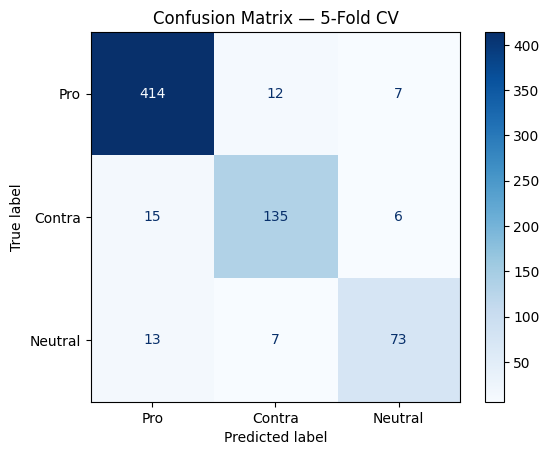

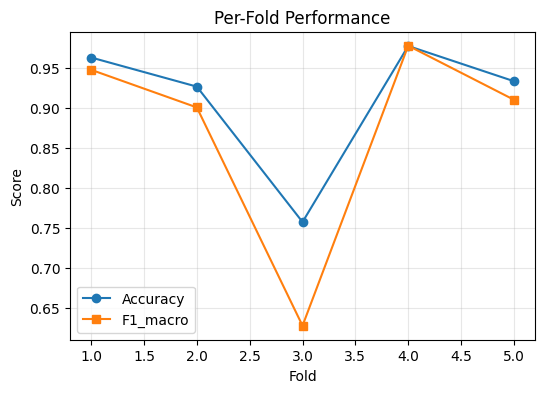

In [68]:
from sklearn.base import clone
from sklearn.ensemble import GradientBoostingClassifier, StackingClassifier
from sklearn.model_selection import StratifiedKFold, cross_val_predict, validation_curve
from sklearn.metrics import classification_report, accuracy_score, f1_score, confusion_matrix, ConfusionMatrixDisplay
from scipy.stats import ttest_rel

X = np.load("X_bert_cls.npy")
y = np.load("y_labels.npy")

# clone dan set hyperparam terbaik
best_svm = clone(pipe_bert_svm).set_params(
    svm__kernel="poly",
    svm__C=37.554,
    svm__gamma="scale",
)
best_rf = clone(pipe_bert_rf).set_params(
    rf__n_estimators=800,
    rf__min_samples_split=10,
    rf__max_depth=10,
)
best_xgb = clone(pipe_bert_xgb).set_params(
    xgb__n_estimators=300,
    xgb__max_depth=7,
    xgb__learning_rate=0.05,
)

# meta learner
meta = GradientBoostingClassifier(
    n_estimators=389,
    max_depth=2,
    learning_rate=0.00419325,
    random_state=42
)

# stacking
stack_final = StackingClassifier(
    estimators=[
        ("bert_svm", pipe_svm),
        ("bert_rf",  pipe_rf),
        ("bert_xgb", pipe_xgb),
    ],
    final_estimator=meta,
    cv=inner_cv,
    stack_method="predict_proba",
    passthrough=True,
    n_jobs=-1
)

# 5-fold evaluation per fold
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
fold_stats = []
for fold, (tr, te) in enumerate(skf.split(X,y), start=1):
    X_tr, X_te = X[tr], X[te]
    y_tr, y_te = y[tr], y[te]

    stack_final.fit(X_tr, y_tr)
    y_pred = stack_final.predict(X_te)

    acc = accuracy_score(y_te, y_pred)
    f1  = f1_score(y_te, y_pred, average="macro")
    fold_stats.append({"fold":fold, "accuracy":acc, "f1_macro":f1})

    print(f"\n*Fold {fold} Classification Report")
    print(classification_report(y_te, y_pred,
          target_names=["Pro","Contra","Neutral"], zero_division=0))

# DataFrame per-fold
df_stats = pd.DataFrame(fold_stats)
print("\nPer-Fold Performance:\n", df_stats)

# confusion matrix 5-fold CV
y_pred_cv = cross_val_predict(stack_final, X, y, cv=skf, n_jobs=-1)
cm = confusion_matrix(y, y_pred_cv, labels=[0,1,2])
disp = ConfusionMatrixDisplay(confusion_matrix=cm,
          display_labels=["Pro","Contra","Neutral"])
disp.plot(cmap="Blues", values_format="d")
plt.title("Confusion Matrix — 5-Fold CV")
plt.show()

plt.figure(figsize=(6,4))
plt.plot(df_stats["fold"], df_stats["accuracy"], marker="o", label="Accuracy")
plt.plot(df_stats["fold"], df_stats["f1_macro"], marker="s", label="F1_macro")
plt.xlabel("Fold"); plt.ylabel("Score")
plt.title("Per-Fold Performance"); plt.legend(); plt.grid(alpha=0.3); plt.show()

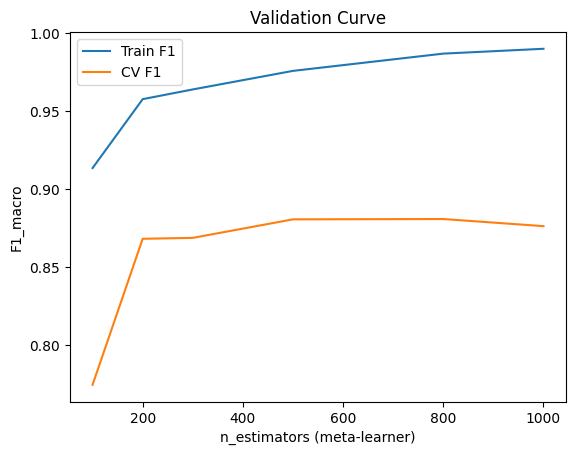

In [69]:
# validation curve 
param_range = [100,200,300,500,800,1000]
train_scores, cv_scores = validation_curve(
    stack_final, X,y,
    param_name="final_estimator__n_estimators",
    param_range=param_range,
    cv=skf,
    scoring="f1_macro",
    n_jobs=-1
)
train_mean = train_scores.mean(axis=1)
cv_mean    = cv_scores.mean(axis=1)
plt.plot(param_range, train_mean, label="Train F1")
plt.plot(param_range, cv_mean,    label="CV F1")
plt.xlabel("n_estimators (meta‐learner)"); plt.ylabel("F1_macro")
plt.title("Validation Curve"); plt.legend(); plt.show()

In [70]:
# paired t-test stacking vs BERT+RF baseline
from sklearn.model_selection import cross_val_score
acc_stack = cross_val_score(stack_final, X, y, cv=skf,
                            scoring="accuracy", n_jobs=-1)
acc_rf    = cross_val_score(pipe_rf,   X, y, cv=skf,
                            scoring="accuracy", n_jobs=-1)
t_stat, p_val = ttest_rel(acc_stack, acc_rf)

f1_stack  = cross_val_score(stack_final, X, y,
                            cv=skf,
                            scoring="f1_macro",
                            n_jobs=-1)
f1_rf     = cross_val_score(pipe_rf,  X, y,
                            cv=skf,
                            scoring="f1_macro",
                            n_jobs=-1)

t_acc, p_acc = ttest_rel(acc_stack, acc_rf)

t_f1,  p_f1  = ttest_rel(f1_stack,  f1_rf)

print("\nStacking vs Baseline BERT+RF:")
print(f"  mean_acc_stack = {acc_stack.mean():.2f} ± {acc_stack.std():.3f}")
print(f"  mean_acc_rf    = {acc_rf.mean():.2f} ± {acc_rf.std():.3f}")
print(f"  t-statistic    = {t_acc:.2f}, p-value = {p_acc:.3f}")

print("\nStacking vs Baseline BERT+RF (F1_macro):")
print(f"  mean_f1_stack  = {f1_stack.mean():.2f} ± {f1_stack.std():.3f}")
print(f"  mean_f1_rf     = {f1_rf.mean():.2f} ± {f1_rf.std():.3f}")
print(f"  t-statistic    = {t_f1:.2f}, p-value = {p_f1:.3f}")


Stacking vs Baseline BERT+RF:
  mean_acc_stack = 0.91 ± 0.080
  mean_acc_rf    = 0.92 ± 0.083
  t-statistic    = -0.58, p-value = 0.593

Stacking vs Baseline BERT+RF (F1_macro):
  mean_f1_stack  = 0.87 ± 0.126
  mean_f1_rf     = 0.88 ± 0.137
  t-statistic    = -0.22, p-value = 0.834


## Coba Logistic Stacking

In [71]:
import os
os.environ["TOKENIZERS_PARALLELISM"] = "false"

from scipy.stats import uniform
from sklearn.model_selection import (
    StratifiedKFold,
    RandomizedSearchCV,
    cross_val_score
)
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import StackingClassifier
from sklearn.ensemble import RandomForestClassifier     
from sklearn.svm import SVC
from xgboost import XGBClassifier
from sklearn.preprocessing import StandardScaler
from imblearn.pipeline import Pipeline as ImbPipeline
from imblearn.over_sampling import SMOTE
from scipy.stats import randint

np.random.seed(42)

X = np.load("X_bert_cls.npy")
y = np.load("y_labels.npy")

pipe_bert_svm = ImbPipeline([
    ("scale",  StandardScaler()),
    ("smote",  SMOTE(random_state=42)),
    ("svm",    SVC(class_weight="balanced", probability=True, random_state=42))
])

pipe_bert_rf = ImbPipeline([
    ("scale",  StandardScaler()),
    ("smote",  SMOTE(random_state=42)),
    ("rf",     RandomForestClassifier(random_state=42))
])

pipe_bert_xgb = ImbPipeline([
    ("scale",  StandardScaler()),
    ("smote",  SMOTE(random_state=42)),
    ("xgb",    XGBClassifier(eval_metric="logloss", random_state=42))
])

param_base = {
    # SVM
    "svm__kernel":       ["linear","rbf","poly","sigmoid"],
    "svm__C":            uniform(0.1, 100),
    "svm__gamma":        ["scale","auto"],

    # RF
    "rf__n_estimators":  [100,300,500,800,1000],
    "rf__max_depth":     [None,10,20,30,50],
    "rf__min_samples_split": [2,5,10],

    # XGB
    "xgb__n_estimators": [100,300,500,800],
    "xgb__max_depth":    [3,5,7,10],
    "xgb__learning_rate":[0.01,0.05,0.1]
}

param_meta = {
    "final_estimator__C":       uniform(0.01, 10),        # cari C di [0.01, 10]
    "final_estimator__penalty": ["l1", "l2"],             # l1 atau l2
    "final_estimator__solver":  ["liblinear", "saga"],    # solver yang mendukung L1/L2
}

outer_cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
inner_cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

# SVM
rnd_svm = RandomizedSearchCV(
    estimator=pipe_bert_svm,
    param_distributions={k: v for k, v in param_base.items() if k.startswith("svm__")},
    n_iter=10,
    scoring={
        "F1_macro": "f1_macro",
        "Accuracy": "accuracy"
    },
    refit="F1_macro",       
    cv=inner_cv,
    random_state=42,
    n_jobs=-1,
)
rnd_svm.fit(X, y)
best_svm = rnd_svm.best_estimator_

# RF
rnd_rf = RandomizedSearchCV(
    estimator=pipe_bert_rf,
    param_distributions={k: v for k, v in param_base.items() if k.startswith("rf__")},
    n_iter=10,
    scoring={
        "F1_macro": "f1_macro",
        "Accuracy": "accuracy"
    },
    refit="F1_macro",
    cv=inner_cv,
    random_state=42,
    n_jobs=-1,
)
rnd_rf.fit(X, y)
best_rf = rnd_rf.best_estimator_

# XGB
rnd_xgb = RandomizedSearchCV(
    estimator=pipe_bert_xgb,
    param_distributions={k: v for k, v in param_base.items() if k.startswith("xgb__")},
    n_iter=10,
    scoring={
        "F1_macro": "f1_macro",
        "Accuracy": "accuracy"
    },
    refit="F1_macro",
    cv=inner_cv,
    random_state=42,
    n_jobs=-1,
)
rnd_xgb.fit(X, y)
best_xgb = rnd_xgb.best_estimator_

stack_all = StackingClassifier(
    estimators=[
        ("bert_svm", best_svm),
        ("bert_rf",  best_rf),
        ("bert_xgb", best_xgb),
    ],
    final_estimator=LogisticRegression(class_weight="balanced", random_state=42),
    cv=inner_cv,
    stack_method="predict_proba",
    passthrough=True,
    n_jobs=-1,
)

rnd_meta_lr = RandomizedSearchCV(
    estimator=stack_all,
    param_distributions=param_meta,
    n_iter=20,
    scoring={
        "F1_macro": "f1_macro",
        "Accuracy": "accuracy"
    },
    refit="F1_macro",
    cv=inner_cv,
    random_state=42,
    n_jobs=-1,
)
rnd_meta_lr.fit(X, y)

final_stack_lr = rnd_meta_lr.best_estimator_
acc_lr = cross_val_score(final_stack_lr, X, y,
                         cv=outer_cv, scoring="accuracy", n_jobs=-1)
f1_lr  = cross_val_score(final_stack_lr, X, y,
                         cv=outer_cv, scoring="f1_macro", n_jobs=-1)

print(f"\nOuter CV Accuracy (stack+LR): {acc_lr.mean():.2f} ± {acc_lr.std():.2f}")
print(f"Outer CV F1_macro (stack+LR): {f1_lr.mean():.2f} ± {f1_lr.std():.2f}")

results_lr = {
    "Model":            "STACKING+LogReg",
    "F1_macro (CV)":    round(f1_lr.mean(), 2),
    "Std_F1_macro (CV)":round(f1_lr.std(), 3),
    "Acc (CV)":         round(acc_lr.mean(), 2),
    "Std_Acc (CV)":     round(acc_lr.std(), 3),
    **rnd_meta_lr.best_params_
}

df_summary_lr = pd.DataFrame([results_lr])
print("\n", df_summary_lr.to_markdown(index=False))

/Users/elisa/Documents/Final_project/data_fp/.venv/lib/python3.13/site-packages/sklearn/linear_model/_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(
/Users/elisa/Documents/Final_project/data_fp/.venv/lib/python3.13/site-packages/sklearn/linear_model/_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(
/Users/elisa/Documents/Final_project/data_fp/.venv/lib/python3.13/site-packages/sklearn/linear_model/_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(
/Users/elisa/Documents/Final_project/data_fp/.venv/lib/python3.13/site-packages/sklearn/linear_model/_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(
/Users/elisa/Documents/Final_project/data_fp/.venv/lib/python3.13/site-packages/sklearn/linear_model/_sag.py:348: ConvergenceWarning: The ma


Outer CV Accuracy (stack+LR): 0.91 ± 0.08
Outer CV F1_macro (stack+LR): 0.87 ± 0.13

 | Model           |   F1_macro (CV) |   Std_F1_macro (CV) |   Acc (CV) |   Std_Acc (CV) |   final_estimator__C | final_estimator__penalty   | final_estimator__solver   |
|:----------------|----------------:|--------------------:|-----------:|---------------:|---------------------:|:---------------------------|:--------------------------|
| STACKING+LogReg |            0.87 |               0.132 |       0.91 |          0.084 |             0.590836 | l2                         | liblinear                 |


In [72]:
import pandas as pd
from pandas import json_normalize

def summarize(rs, name, prefix):
    df = pd.DataFrame(rs.cv_results_)
    # metrik
    if "mean_test_F1_macro" in df:
        f1, sf1 = "mean_test_F1_macro", "std_test_F1_macro"
    else:
        f1, sf1 = "mean_test_score", "std_test_score"
    acc = ["mean_test_Accuracy", "std_test_Accuracy"] if "mean_test_Accuracy" in df else []
    cols = [f1, sf1] + acc + ["params"]
    df2 = df[cols].rename(columns={
        f1: "F1_macro (CV)",
        sf1: "Std_F1_macro (CV)",
        **({"mean_test_Accuracy":"Acc (CV)", "std_test_Accuracy":"Std_Acc (CV)"} if acc else {})
    })
    ps = json_normalize(df2.pop("params"))
    ps = ps[[c for c in ps if c.startswith(prefix)]]
    ps.columns = [c.replace(prefix, "") for c in ps]
    out = pd.concat([df2, ps], axis=1)
    out.insert(0, "Model", name)
    best = out["F1_macro (CV)"].astype(float).idxmax()
    out.loc[best, "Model"] += " *"
    return out

# kumpulkan semua
tables = []
tables.append(summarize(rnd_svm,  "BERT+SVM",       "svm__"))
tables.append(summarize(rnd_rf,   "BERT+RF",        "rf__"))
tables.append(summarize(rnd_xgb,  "BERT+XGB",       "xgb__"))
tables.append(summarize(rnd_meta_lr, "STACKING+LR", "final_estimator__"))

df_all = pd.concat(tables, ignore_index=True)
print(df_all.to_markdown(index=False))


| Model         |   F1_macro (CV) |   Std_F1_macro (CV) |   Acc (CV) |   Std_Acc (CV) |          C | gamma   | kernel   |   n_estimators |   min_samples_split |   max_depth |   learning_rate | penalty   | solver    |
|:--------------|----------------:|--------------------:|-----------:|---------------:|-----------:|:--------|:---------|---------------:|--------------------:|------------:|----------------:|:----------|:----------|
| BERT+SVM *    |        0.868146 |            0.142817 |   0.914845 |      0.0825473 |  37.554    | scale   | poly     |            nan |                 nan |         nan |          nan    | nan       | nan       |
| BERT+SVM      |        0.847842 |            0.138343 |   0.894332 |      0.0804441 |  73.2994   | scale   | linear   |            nan |                 nan |         nan |          nan    | nan       | nan       |
| BERT+SVM      |        0.868146 |            0.142817 |   0.914845 |      0.0825473 |  15.7019   | scale   | poly     |           


— Fold 1 Classification Report —
              precision    recall  f1-score   support

         Pro       0.95      0.97      0.96        87
      Contra       0.97      0.97      0.97        31
     Neutral       0.89      0.84      0.86        19

    accuracy                           0.95       137
   macro avg       0.94      0.93      0.93       137
weighted avg       0.95      0.95      0.95       137


— Fold 2 Classification Report —
              precision    recall  f1-score   support

         Pro       0.94      0.97      0.95        87
      Contra       0.94      0.91      0.92        32
     Neutral       0.88      0.83      0.86        18

    accuracy                           0.93       137
   macro avg       0.92      0.90      0.91       137
weighted avg       0.93      0.93      0.93       137


— Fold 3 Classification Report —
              precision    recall  f1-score   support

         Pro       0.85      0.87      0.86        87
      Contra       0.59    

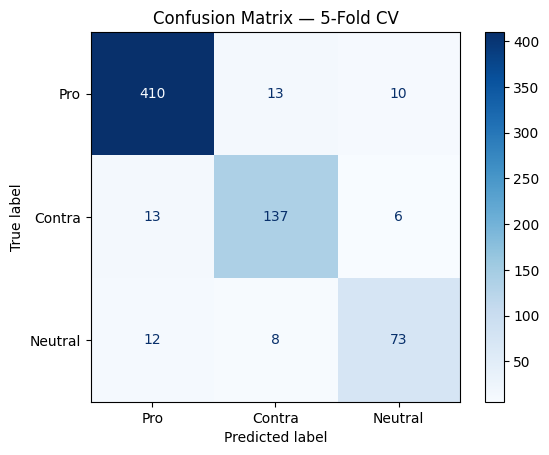

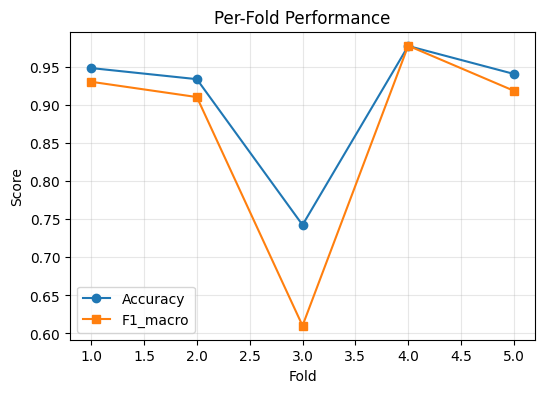

In [73]:
import os
os.environ["TOKENIZERS_PARALLELISM"] = "false"

from sklearn.base import clone
from sklearn.model_selection import StratifiedKFold, cross_val_predict
from sklearn.metrics import classification_report, accuracy_score, f1_score, confusion_matrix
from sklearn.metrics import ConfusionMatrixDisplay
from sklearn.ensemble import StackingClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from sklearn.preprocessing import StandardScaler
from imblearn.pipeline import Pipeline as ImbPipeline
from imblearn.over_sampling import SMOTE

# fix random seed
np.random.seed(42)

# load data
X = np.load("X_bert_cls.npy")
y = np.load("y_labels.npy")

# 1) Pipelines dasar
pipe_svm = ImbPipeline([
    ("scale", StandardScaler()),
    ("smote", SMOTE(random_state=42)),
    ("svm",   SVC(class_weight="balanced", probability=True, random_state=42))
])
pipe_rf  = ImbPipeline([
    ("scale", StandardScaler()),
    ("smote", SMOTE(random_state=42)),
    ("rf",    RandomForestClassifier(random_state=42))
])
pipe_xgb = ImbPipeline([
    ("scale", StandardScaler()),
    ("smote", SMOTE(random_state=42)),
    ("xgb",   XGBClassifier(eval_metric="logloss", random_state=42))
])

# 2) Clone + set hyper‐parameter terbaik
best_svm = clone(pipe_svm).set_params(
    svm__kernel="poly",
    svm__C=37.554,
    svm__gamma="scale",
)
best_rf  = clone(pipe_rf).set_params(
    rf__n_estimators=800,
    rf__min_samples_split=10,
    rf__max_depth=10,
)
best_xgb = clone(pipe_xgb).set_params(
    xgb__n_estimators=300,
    xgb__max_depth=7,
    xgb__learning_rate=0.05,
)

# 3) Meta‐learner: Logistic Regression terbaik
meta = LogisticRegression(
    penalty="l2",
    solver="liblinear",
    C=0.590836,
    class_weight="balanced",
    random_state=42
)

# 4) Stacking final
inner_cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
stack_final = StackingClassifier(
    estimators=[
        ("bert_svm", best_svm),
        ("bert_rf",  best_rf),
        ("bert_xgb", best_xgb),
    ],
    final_estimator=meta,
    cv=inner_cv,
    stack_method="predict_proba",
    passthrough=True,
    n_jobs=-1
)

# 5) 5-fold evaluation per‐fold dengan reporting
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
fold_stats = []

for fold, (tr, te) in enumerate(skf.split(X, y), start=1):
    X_tr, X_te = X[tr], X[te]
    y_tr, y_te = y[tr], y[te]

    stack_final.fit(X_tr, y_tr)
    y_pred = stack_final.predict(X_te)

    acc = accuracy_score(y_te, y_pred)
    f1  = f1_score(y_te, y_pred, average="macro")
    fold_stats.append({"fold": fold, "accuracy": acc, "f1_macro": f1})

    print(f"\n— Fold {fold} Classification Report —")
    print(classification_report(
        y_te, y_pred,
        target_names=["Pro","Contra","Neutral"],
        zero_division=0
    ))

df_stats = pd.DataFrame(fold_stats)
print("\nPer-Fold Performance:")
print(df_stats)

y_pred_cv = cross_val_predict(stack_final, X, y, cv=skf, n_jobs=-1)
cm = confusion_matrix(y, y_pred_cv, labels=[0,1,2])
disp = ConfusionMatrixDisplay(confusion_matrix=cm,
                               display_labels=["Pro","Contra","Neutral"])
disp.plot(cmap="Blues", values_format="d")
import matplotlib.pyplot as plt
plt.title("Confusion Matrix — 5-Fold CV")
plt.show()

plt.figure(figsize=(6,4))
plt.plot(df_stats["fold"], df_stats["accuracy"], marker="o", label="Accuracy")
plt.plot(df_stats["fold"], df_stats["f1_macro"], marker="s", label="F1_macro")
plt.xlabel("Fold"); plt.ylabel("Score")
plt.title("Per-Fold Performance"); plt.legend(); plt.grid(alpha=0.3)
plt.show()


In [74]:
import numpy as np
import pandas as pd
from sklearn.ensemble import RandomForestClassifier, StackingClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from xgboost import XGBClassifier
from sklearn.preprocessing import StandardScaler
from imblearn.pipeline import Pipeline as ImbPipeline
from imblearn.over_sampling import SMOTE
from sklearn.model_selection import StratifiedKFold, cross_val_score
from scipy.stats import ttest_rel

# 1) Muat data
X = np.load("X_bert_cls.npy")
y = np.load("y_labels.npy")

# pipeline Base RF dengan hyperparam terbaik
pipe_rf = ImbPipeline([
    ("scale", StandardScaler()),
    ("smote", SMOTE(random_state=42)),
    ("rf", RandomForestClassifier(
        n_estimators=800,
        max_depth=10,
        min_samples_split=10,
        random_state=42
    ))
])

#  pipeline Stacking+LogReg dengan hyperparam terbaik
pipe_svm = ImbPipeline([
    ("scale", StandardScaler()),
    ("smote", SMOTE(random_state=42)),
    ("svm", SVC(
        kernel="poly",
        C=37.554,
        gamma="scale",
        class_weight="balanced",
        probability=True,
        random_state=42
    ))
])
pipe_xgb = ImbPipeline([
    ("scale", StandardScaler()),
    ("smote", SMOTE(random_state=42)),
    ("xgb", XGBClassifier(
        n_estimators=300,
        max_depth=7,
        learning_rate=0.05,
        eval_metric="logloss",
        random_state=42
    ))
])
meta_lr = LogisticRegression(
    penalty="l2",
    solver="liblinear",
    C=0.590836,
    class_weight="balanced",
    random_state=42
)

stack = StackingClassifier(
    estimators=[
        ("bert_svm", pipe_svm),
        ("bert_rf",  pipe_rf),
        ("bert_xgb", pipe_xgb),
    ],
    final_estimator=meta_lr,
    cv=StratifiedKFold(n_splits=5, shuffle=True, random_state=42),
    stack_method="predict_proba",
    passthrough=True,
    n_jobs=-1
)

skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
acc_rf    = cross_val_score(pipe_rf,    X, y, cv=skf, scoring="accuracy", n_jobs=-1)
acc_stack = cross_val_score(stack,      X, y, cv=skf, scoring="accuracy", n_jobs=-1)

# T-Test
t_stat, p_val = ttest_rel(acc_stack, acc_rf)

df = pd.DataFrame({
    "Model":    ["Base RF", "Stacking+LR"],
    "Accuracy": [acc_rf.mean(), acc_stack.mean()],
    "Std Dev":  [acc_rf.std(), acc_stack.std()]
})
print(df.to_markdown(index=False))
print(f"\nPaired t-test: t = {t_stat:.3f}, p = {p_val:.3f}")


| Model       |   Accuracy |   Std Dev |
|:------------|-----------:|----------:|
| Base RF     |   0.923647 | 0.0804001 |
| Stacking+LR |   0.908995 | 0.0844918 |

Paired t-test: t = -2.235, p = 0.089


# Knowledge Graph

## Dataset KG

In [75]:
import re
import spacy
import pandas as pd
from spacy.pipeline import EntityRuler
from spacy.matcher import PhraseMatcher, DependencyMatcher
from spacy.language import Language
from spacy.tokens import Span
from spacy.util import filter_spans
from collections import defaultdict, Counter

# Utility functions
def normalize(s: str) -> str:
    return re.sub(r"\W+", " ", s.lower()).strip()

# Relation canonization map
REL_CANON = {
    "increase": "increase", "raise": "increase", "boost": "increase", "improve": "increase", "enhance": "increase",
    "decrease": "decrease", "drop": "decrease", "decline": "decrease", "reduce": "decrease",
    "optimize": "optimize", "optimise": "optimize",
    "monitor": "monitor", "track": "monitor", "measure": "monitor",
    "manage": "manage", "control": "manage",
    "support": "support", "aid": "support",
    "develop": "develop", "design": "develop", "build": "develop",
    "harvest": "harvest", "produce": "produce", "yield": "harvest",
    "transport": "transport", "deliver": "transport", "ship": "transport",
    "invest": "invest", "fund": "invest", "finance": "invest"
}

# Define domain entity patterns
DOMAIN_PATTERNS = {
    "TECHNOLOGY": [
        "precision agriculture", "smart farming", "vertical farming", "aquaponics", "hydroponics",
        "farm automation", "autonomous tractor", "robotic farming", "agritech",
        "drone", "drones", "drone spraying", "drone mapping",
        "satellite imagery", "remote sensing", "IoT sensor", "soil sensor",
        "weather station", "wireless sensor",
        "big data", "machine learning", "artificial intelligence", "AI",
        "computer vision", "edge computing", "cloud platform",
        "decision support system", "GIS", "mobile app",
        "blockchain", "distributed ledger", "digital twin", "robotics",
        # tambahan sub-domain
        "precision irrigation", "soil moisture sensor",
        "solar pump", "microgrid"
    ],
    "CROP": [
        "crop", "crops", "wheat", "corn", "maize", "rice", "soybean", "soybeans",
        "avocado", "coffee", "tea", "banana", "vegetable", "fruit",
        "paddy", "barley", "oat", "potato", "tomato",
        "genetically modified crop", "biotech crop"
    ],
    "LIVESTOCK": [
        "livestock", "dairy", "poultry", "cattle", "sheep", "goat", "swine", "pig", "fish",
        "aquaculture", "seaweed", "mushroom",
        "aquaponics", "hydroponics"
    ],
    "POLICY": [
        "policy", "regulation", "regulations", "subsidy", "subsidies", "food security",
        "tariff", "trade policy", "export ban", "import quota", "public–private partnership",
        "PPP", "government subsidy", "climate policy", "environmental regulation",
        "food safety standard", "carbon credit"
    ],
    "EVENT": [
        "harvest", "drought", "flood", "planting season", "funding round", "merger",
        "acquisition", "demo", "demonstration", "summit", "conference", "workshop",
        "launch", "pilot", "expo",
        "harvest festival"
    ],
    "METRIC": [
        "yield", "production", "emission", "emissions", "CO2", "carbon footprint",
        "investment", "investment amount", "ROI", "price", "market price", "area",
        "hectare", "tonne", "bushel", "percent", "percentage",
        "farm", "yield"
        "agritech investment",
        "farm_yield", "farm_output",
        "water footprint", "nitrogen use efficiency"
    ],
    "INFRASTRUCTURE": [
        "greenhouse", "polytunnel", "shade net", "drip irrigation",
        "subsurface irrigation", "rainwater harvesting", "soil health",
        "compost", "biofertilizer", "biopesticide", "organic fertilizer",
        "integrated pest management", "crop rotation", "cover crop", "no-till",
        "regenerative agriculture", "agroforestry", "silvopasture",
        "precision irrigation", "soil moisture sensor", "solar pump"
    ],
    "ENVIRONMENT": [
        "climate", "weather", "temperature", "rainfall", "soil erosion",
        "biodiversity", "water use efficiency", "water stress", "net-zero",
        "carbon sequestration", "circular economy", "sustainability",
        "climate-smart agriculture", "environmental impact",
        "water footprint", "phosphorus leaching", "pesticide runoff"
    ],
    "BUSINESS": [
        "startup", "fintech", "insurtech", "venture capital", "VC", "IPO",
        "crowdfunding", "partnership", "cooperative", "retail", "supply chain",
        "traceability", "market access", "commodity exchange", "export", "import",
        "logistics",
        "venture capital in agriculture", "agritech investment"
    ],
    "NEWS_SOURCE": [
        "Reuters", "BBC", "The Guardian", "Bloomberg", "Financial Times", "Forbes",
        "CNBC", "AgFunder", "AgriBusiness", "Farm Journal", "The Independent"
        "reuters", "bbc", "the guardian", "bloomberg", "forbes", "cnbc","the independent"
    ]
}

# Load NLP model
nlp = spacy.load("en_core_web_sm")

# Initialize PhraseMatcher and EntityRuler
phrase_matcher = PhraseMatcher(nlp.vocab, attr='LOWER')
ruler = nlp.add_pipe("entity_ruler", before="ner", config={"overwrite_ents": True})
patterns = []
for label, terms in DOMAIN_PATTERNS.items():
    for term in terms:
        patterns.append({"label": label, "pattern": term})
        phrase_matcher.add(label, [nlp.make_doc(term)])
ruler.add_patterns(patterns)

# Register custom phrase component, merging spans without overlap
@Language.component("phrase_component")
def phrase_component(doc):
    matches = phrase_matcher(doc)
    spans = [Span(doc, start, end, label=nlp.vocab.strings[match_id]) for match_id, start, end in matches]
    # merge with existing entities, remove overlaps
    all_spans = list(doc.ents) + spans
    doc.ents = filter_spans(all_spans)
    return doc

nlp.add_pipe("phrase_component", before="ner")

# Define dependency patterns including passive auxiliaries
pattern_svo = [
    {"RIGHT_ID": "verb", "RIGHT_ATTRS": {"POS": "VERB"}},
    {"LEFT_ID": "verb", "REL_OP": ">", "RIGHT_ID": "subj", "RIGHT_ATTRS": {"DEP": {"IN": ["nsubj", "nsubjpass", "auxpass"]}}},
    {"LEFT_ID": "verb", "REL_OP": ">", "RIGHT_ID": "obj",  "RIGHT_ATTRS": {"DEP": {"IN": ["dobj", "pobj"]}}}
]
pattern_svo_pp = [
    {"RIGHT_ID": "verb", "RIGHT_ATTRS": {"POS": "VERB"}},
    {"LEFT_ID": "verb", "REL_OP": ">", "RIGHT_ID": "subj", "RIGHT_ATTRS": {"DEP": {"IN": ["nsubj", "nsubjpass"]}}},
    {"LEFT_ID": "verb", "REL_OP": ">", "RIGHT_ID": "prep", "RIGHT_ATTRS": {"DEP": "prep"}},
    {"LEFT_ID": "prep", "REL_OP": ">", "RIGHT_ID": "pobj", "RIGHT_ATTRS": {"DEP": "pobj"}}
]
dep_matcher = DependencyMatcher(nlp.vocab)
dep_matcher.add("SVO", [pattern_svo])
dep_matcher.add("SVO_PP", [pattern_svo_pp])

# Compute dynamic distance thresholds (95th percentile)
distances = []
for doc in nlp.pipe(df_best["Content_clean"], batch_size=32):
    for match_id, tok_ids in dep_matcher(doc):
        match_name = nlp.vocab.strings[match_id]
        subj_tok = doc[tok_ids[1]]
        obj_tok = doc[tok_ids[2]] if match_name == "SVO" else doc[tok_ids[3]]
        ent_subj = next((ent for ent in doc.ents if ent.start <= subj_tok.i < ent.end), None)
        ent_obj  = next((ent for ent in doc.ents if ent.start <= obj_tok.i < ent.end), None)
        if not ent_subj or not ent_obj:
            continue
        cd = abs((ent_subj.start + ent_subj.end)/2 - (ent_obj.start + ent_obj.end)/2)
        td = max(obj_tok.i - ent_subj.end, ent_subj.start - obj_tok.i, 0)
        distances.append((cd, td))
# Calculate thresholds
df_d = pd.DataFrame(distances, columns=["center_dist","token_dist"])
MAX_CENTER_DIST = df_d["center_dist"].quantile(0.95)
MAX_TOKEN_DIST  = df_d["token_dist"].quantile(0.95)
print(f"Thresholds => center_dist ≤ {MAX_CENTER_DIST:.2f}, token_dist ≤ {MAX_TOKEN_DIST:.0f}")

# Extract triples
rows = []
rel_map = defaultdict(list)
for i, doc in enumerate(nlp.pipe(df_best["Content_clean"], batch_size=32)):
    source_title   = df_best.iloc[i]["Title"]
    sentiment      = df_best.iloc[i]["pred_label"]
    sentiment_conf = df_best.iloc[i]["confidence"]
    topic          = df_best.iloc[i]["Topic"]
    for match_id, tok_ids in dep_matcher(doc):
        match_name = nlp.vocab.strings[match_id]
        verb_tok   = doc[tok_ids[0]]
        subj_tok   = doc[tok_ids[1]]
        if match_name == "SVO":
            obj_tok      = doc[tok_ids[2]]
            relation_raw = verb_tok.lemma_.lower()
        else:
            prep_tok     = doc[tok_ids[2]]
            obj_tok      = doc[tok_ids[3]]
            relation_raw = f"{verb_tok.lemma_.lower()}_{prep_tok.text.lower()}"
        ent_subj = next((ent for ent in doc.ents if ent.start <= subj_tok.i < ent.end), None)
        ent_obj  = next((ent for ent in doc.ents if ent.start <= obj_tok.i < ent.end), None)
        if not ent_subj or not ent_obj:
            continue
        cd = abs((ent_subj.start + ent_subj.end)/2 - (ent_obj.start + ent_obj.end)/2)
        td = max(obj_tok.i - ent_subj.end, ent_subj.start - obj_tok.i, 0)
        if cd > MAX_CENTER_DIST or td > MAX_TOKEN_DIST:
            continue
        subj = ent_subj.text
        obj  = ent_obj.text
        key  = (normalize(subj), normalize(obj))
        rel_map[key].append(relation_raw)
        top_rel, freq = Counter(rel_map[key]).most_common(1)[0]
        relation = REL_CANON.get(top_rel, top_rel)
        rows.append({
            "source_title":   source_title,
            "subject":        subj,
            "subject_label":  ent_subj.label_,
            "object":         obj,
            "object_label":   ent_obj.label_,
            "relation":       relation,
            "rel_freq":       freq,
            "triple_text":    f"{subj} {relation} {obj}",
            "sentiment":      sentiment,
            "sentiment_conf": sentiment_conf,
            "topic":          topic
        })
        
svo_df = pd.DataFrame(rows)
kg_df  = svo_df.copy()
kg_df.to_csv("kg_df.csv", index=False)
print("The Result of Extract Entity:")
print(f"unique triples: {len(kg_df)}")

Thresholds => center_dist ≤ 20.97, token_dist ≤ 20
The Result of Extract Entity:
unique triples: 761


In [76]:
kg_df

,source_title,subject,subject_label,object,object_label,relation,rel_freq,triple_text,sentiment,sentiment_conf,topic
0,China'S Big Feed Shift To Curb Soybean Imports...,china,GPE,import,BUSINESS,cut,1,china cut import,Pro,0.955897,Biotech & Crop Genetics
1,China'S Big Feed Shift To Curb Soybean Imports...,china,GPE,soybean,CROP,buy,1,china buy soybean,Pro,0.955897,Biotech & Crop Genetics
2,China'S Big Feed Shift To Curb Soybean Imports...,southeast asia,LOC,poultry,LIVESTOCK,use,1,southeast asia use poultry,Pro,0.955897,Biotech & Crop Genetics
3,Spring Statement 2025: Key Points At A Glance,year fall,DATE,meet bank england target,ORG,meet,1,year fall meet meet bank england target,Pro,0.907531,Market Access & Trade Dynamics
4,A New Life For Empty Offices: Growing Kale And...,australia,GPE,deloitte commonwealth bank,ORG,start_like,1,australia start_like deloitte commonwealth bank,Pro,0.984446,Economic & Family Farming
...,...,...,...,...,...,...,...,...,...,...,...
756,Focus: Deere Tapping Into Apple-Like Tech Mode...,price,METRIC,yield,METRIC,increase,1,price increase yield,Pro,0.942658,Economic & Family Farming
757,It Was Tory Governments That Created The Low-W...,johnson,PERSON,1960s 1970s,DATE,like,1,johnson like 1960s 1970s,Neutral,0.942424,Market Access & Trade Dynamics
758,"Insight: If Your Coffee'S Going Downhill, Blam...",brazil,GPE,production,METRIC,increase,1,brazil increase production,Pro,0.907312,Biotech & Crop Genetics
759,Climate Change: Removing Co2 Could Spark Big R...,rice,CROP,area,METRIC,affect,1,rice affect area,Pro,0.872965,Climate & Environmental Monitoring


In [77]:
import re
import pandas as pd
import spacy

kg_df = kg_df.copy()

# Label filtering
AGRI_LABELS = {
    "TECHNOLOGY","CROP","LIVESTOCK","POLICY",
    "EVENT","METRIC","INFRASTRUCTURE","ENVIRONMENT","BUSINESS"
}
mask_label = (
    kg_df["subject_label"].isin(AGRI_LABELS) &
    kg_df["object_label"].isin(AGRI_LABELS)
)

# Term filtering
AGR_TERMS = {
    t.lower()
    for terms in DOMAIN_PATTERNS.values() for t in terms
    if t not in DOMAIN_PATTERNS["NEWS_SOURCE"]
}
TERM_RE = re.compile(
    r"\b(?:" + "|".join(map(re.escape, AGR_TERMS)) + r")\b",
    flags=re.IGNORECASE
)
mask_term = (
    kg_df["subject"].str.contains(TERM_RE, na=False) |
    kg_df["object"].str.contains(TERM_RE, na=False)
)

# Relation filtering
AGR_REL = {
    "harvest","optimize","monitor","invest","produce",
    "yield","transport","grow","boost","enhance",
    "plant","sow","irrigate","fertilize","spray",
    "prune","cultivate","weed","propagate","rotate","breed",
    "harrow","till","drain","plough","mulch",
    "sensor","automation","drone","drones","robot","robotics",
    "ai","machine learning","blockchain","iot",
    "precision","remote sensing"
}
mask_rel = kg_df["relation"].str.lower().isin(AGR_REL)

#  Exclude war/conflict triples
WAR_KW = ["israel","gaza","ukraine","russia","war","conflict","shoot","hit","hamas"]
WAR_RE = re.compile(r"\b(?:" + "|".join(map(re.escape, WAR_KW)) + r")\b",
                    flags=re.IGNORECASE)
WAR_REL = {"attack","bomb","shoot","hit","fight","strike","shell","come_trump","ukraine",
           "netherland","levy"}
mask_no_war = ~(
    kg_df["subject"].str.contains(WAR_RE, na=False) |
    kg_df["object"].str.contains(WAR_RE, na=False) |
    kg_df["relation"].str.lower().isin(WAR_REL)
)

def count_agr_terms(text: str) -> int:
    return len(TERM_RE.findall(text or ""))

# hitung per-entitas
sub_count = kg_df["subject"].map(count_agr_terms)
obj_count = kg_df["object"].map(count_agr_terms)

# gabungan count ≥ 2
mask_entity_terms = (sub_count + obj_count) >= 2

mask_agri = (
    mask_label
    & mask_no_war
    & (mask_term | mask_rel)
    & mask_entity_terms
)

# Ambil hanya triple unik yang lolos mask_agri
kg_agri = (
    kg_df[mask_agri]
      .drop_duplicates(subset=["subject","relation","object"])
      .reset_index(drop=True)
)

# Buang entitas yang hanya muncul sekali
all_ents = pd.concat([kg_agri["subject"], kg_agri["object"]])
freq      = all_ents.value_counts()
good_ents = set(freq.index)
kg_agri = kg_agri[
    kg_agri["subject"].isin(good_ents) &
    kg_agri["object"].isin(good_ents)
].reset_index(drop=True)

STOP_ENTS = {
    "north korea","donald trump","antony blinken","vladimir putin",
    "european union","mexico","kenya","china","google","facebook",
    "united states","russia","ukraine","israel","africa","bulgaria","india","new york"
}
kg_agri = kg_agri[
    ~kg_agri["subject"].str.lower().isin(STOP_ENTS) &
    ~kg_agri["object"].str.lower().isin(STOP_ENTS)
].reset_index(drop=True)

nlp = spacy.load("en_core_web_sm")
def has_geo(x):
    doc = nlp(x)
    return any(ent.label_ in {"LOC","GPE"} for ent in doc.ents)

mask_no_geo = ~(
    kg_agri["subject"].apply(has_geo) &
    kg_agri["object"].apply(has_geo)
)
kg_agri = kg_agri[mask_no_geo].reset_index(drop=True)

print(f"Final Agritech triples : {len(kg_agri)}")
kg_agri.to_csv("kg_agri.csv", index=False)

kg_agri

Final Agritech triples : 55


,source_title,subject,subject_label,object,object_label,relation,rel_freq,triple_text,sentiment,sentiment_conf,topic
0,Us Economy ‘Motoring Along’ With 2.8% Growth; ...,import,BUSINESS,export,BUSINESS,fall,1,import fall export,Pro,0.917627,Market Access & Trade Dynamics
1,Us Economy ‘Motoring Along’ With 2.8% Growth; ...,export,BUSINESS,export,BUSINESS,go,1,export go export,Pro,0.917627,Market Access & Trade Dynamics
2,Debate Rages Over Push For New Green Revolutio...,climate,ENVIRONMENT,flood,EVENT,change,1,climate change flood,Pro,0.941528,Economic & Family Farming
3,Ecb Leaves Eurozone Interest Rates On Hold But...,price,METRIC,drought,EVENT,push,1,price push drought,Pro,0.990293,Market Access & Trade Dynamics
4,K Pledges £6M To Back ‘Climate-Smart’ Farming ...,food security,POLICY,temperature,ENVIRONMENT,support_alongside,1,food security support_alongside temperature,Pro,0.986509,Climate & Environmental Monitoring
5,‘Farming Is A Dirty Word Now’: The Woman Helpi...,farm,METRIC,dairy,LIVESTOCK,receive,1,farm receive dairy,Pro,0.977824,Economic & Family Farming
6,Cop28: Us-Uae Climate-Friendly Farming Effort ...,regenerative agriculture,INFRASTRUCTURE,summit,EVENT,refer,1,regenerative agriculture refer summit,Pro,0.967269,Climate & Environmental Monitoring
7,Bangladesh Farmers Revive Floating Farms To Fi...,flood,EVENT,flood,EVENT,flash,1,flood flash flood,Pro,0.904537,Economic & Family Farming
8,Farmers In Odesa Sound Alarm Over Blockade: ‘I...,crop,CROP,harvest,EVENT,grow,1,crop grow harvest,Contra,0.757012,Food Security & Risk Management
9,Beijing Biotech Firm Banks On Gm Corn In Race ...,yield,METRIC,import,BUSINESS,decrease,1,yield decrease import,Pro,0.965771,Biotech & Crop Genetics


In [78]:
import networkx as nx
from pyvis.network import Network
import networkx.algorithms.community as nx_comm

G = nx.MultiDiGraph()
for _, r in kg_agri.iterrows():
    G.add_node(r.subject, label=r.subject_label)
    G.add_node(r.object,  label=r.object_label)
    G.add_edge(r.subject, r.object, label=r.relation)

und = G.to_undirected()
giant = max(nx.connected_components(und), key=len)
H = G.subgraph(giant).copy()
print(f"Giant comp: {H.number_of_nodes()} nodes, {H.number_of_edges()} edges")

communities = list(nx_comm.louvain_communities(H, seed=42))
# (opsional) filter komunitas yang terlalu kecil/besar
communities = [c for c in communities if 3 <= len(c) <= 30]

for idx, comm in enumerate(communities):
    print(f"Community {idx} ({len(comm)} nodes):")
    print("  ", sorted(comm))
    print()


net = Network(height="800px", width="100%", directed=True, notebook=False)
net.from_nx(H)

# Warna per label
COLOR_MAP = {
    "TECHNOLOGY":   "#d62728",
    "CROP":         "#9467bd",
    "LIVESTOCK":    "#17becf",
    "POLICY":       "#8c564b",
    "EVENT":        "#bcbd22",
    "METRIC":       "#e377c2",
    "INFRASTRUCTURE":"#2ca02c",
    "ENVIRONMENT":  "#7f7f7f",
    "BUSINESS":     "#1f77b4",
    # fallback untuk node non-Agritech:
    None:           "#cccccc"
}

for n in net.nodes:
    lbl = n.get("label")
    n["title"] = f"{n['id']} ({lbl})"
    n["color"] = COLOR_MAP.get(lbl, COLOR_MAP[None])
    n["label"] = n["id"]

net.repulsion(node_distance=150, central_gravity=0.2)

out_file = "kg_agri_giant.html"
net.write_html(out_file)
print("(*) Giant component saved to", out_file)

Giant comp: 40 nodes, 49 edges
Community 0 (6 nodes):
   ['food security', 'import', 'production', 'tariff', 'temperature', 'yield']

Community 1 (4 nodes):
   ['climate', 'emission', 'flood', 'soil erosion']

Community 2 (3 nodes):
   ['artificial intelligence', 'rainfall', 'weather']

Community 3 (9 nodes):
   ['biodiversity', 'dairy', 'drone', 'farm', 'maize', 'pilot', 'robotics', 'sheep', 'supply chain']

Community 4 (4 nodes):
   ['export', 'export ban', 'pig', 'poultry']

Community 5 (9 nodes):
   ['corn', 'crop', 'fruit', 'harvest', 'livestock', 'satellite imagery', 'soil health', 'soybean', 'tomato']

Community 6 (5 nodes):
   ['area', 'drought', 'investment', 'price', 'rice']

(*) Giant component saved to kg_agri_giant.html


### Coba Cek KG

In [79]:
G = nx.from_pandas_edgelist(kg_agri, 'subject', 'object')

deg      = dict(G.degree())
deg_cent = nx.degree_centrality(G)
pr       = nx.pagerank(G)
bw       = nx.betweenness_centrality(G)
cl       = nx.closeness_centrality(G)

df_metrics = pd.DataFrame({
    'entity':            list(deg.keys()),
    'degree':            list(deg.values()),
    'deg_centrality':    [deg_cent[n] for n in deg],
    'pagerank':          [pr[n]       for n in deg],
    'betweenness':       [bw[n]       for n in deg],
    'closeness':         [cl[n]       for n in deg],
})

print(" Top 10 by Degree \n")
print(df_metrics
      .sort_values('degree', ascending=False)
      .head(10)
      .to_markdown(index=False))


 Top 10 by Degree 

| entity   |   degree |   deg_centrality |   pagerank |   betweenness |   closeness |
|:---------|---------:|-----------------:|-----------:|--------------:|------------:|
| farm     |       12 |        0.266667  |  0.0918653 |     0.55      |   0.328155  |
| weather  |        6 |        0.133333  |  0.0415159 |     0.164646  |   0.293913  |
| export   |        6 |        0.133333  |  0.0404893 |     0.140404  |   0.213924  |
| crop     |        6 |        0.133333  |  0.0626632 |     0.214141  |   0.223841  |
| price    |        5 |        0.111111  |  0.0351389 |     0.144444  |   0.218065  |
| yield    |        5 |        0.111111  |  0.0385697 |     0.247475  |   0.2704    |
| flood    |        4 |        0.0888889 |  0.0304304 |     0.0383838 |   0.164878  |
| summit   |        4 |        0.0888889 |  0.0374653 |     0.0010101 |   0.0444444 |
| import   |        3 |        0.0666667 |  0.02337   |     0.159091  |   0.26      |
| harvest  |        3 |        0.0

In [80]:
rels_df = (
    kg_agri["relation"]
      .value_counts()                     # Series: index=relation, value=count
      .reset_index(name="count")         # DataFrame: kolom ['index','count']
      .rename(columns={"index":"relation"})
)

print("=== Relations frequency ===")
print(rels_df.to_string(index=False))

=== Relations frequency ===
           relation  count
            produce      4
                 go      3
               lead      3
            exclude      2
             change      2
           increase      2
               grow      2
           decrease      2
               fall      1
               face      1
               cost      1
                put      1
               warn      1
             suffer      1
            include      1
               keep      1
              bring      1
               find      1
               take      1
accommodate_without      1
           evaluate      1
              plant      1
               talk      1
               hold      1
              spell      1
              write      1
               give      1
               fear      1
               push      1
  support_alongside      1
            receive      1
              refer      1
              flash      1
                fee      1
          accompany      1


In [81]:
# Cek Community
import community as community_louvain

part = community_louvain.best_partition(G.to_undirected())

# balik: community_id → list of nodes
from collections import defaultdict
communities = defaultdict(list)
for node, comm_id in part.items():
    communities[comm_id].append(node)

for cid, members in communities.items():
    print(f"Community {cid} ({len(members)} nodes):")
    for m in members:
        print("  -", m)
    print()


Community 0 (10 nodes):
  - import
  - export
  - food security
  - temperature
  - yield
  - pig
  - export ban
  - poultry
  - production
  - tariff

Community 2 (4 nodes):
  - climate
  - flood
  - soil erosion
  - emission

Community 3 (5 nodes):
  - price
  - drought
  - investment
  - area
  - rice

Community 4 (9 nodes):
  - farm
  - dairy
  - robotics
  - pilot
  - drone
  - maize
  - biodiversity
  - sheep
  - supply chain

Community 5 (3 nodes):
  - regenerative agriculture
  - summit
  - conference

Community 6 (9 nodes):
  - crop
  - harvest
  - satellite imagery
  - corn
  - tomato
  - fruit
  - livestock
  - soybean
  - soil health

Community 7 (1 nodes):
  - hectare

Community 8 (3 nodes):
  - artificial intelligence
  - weather
  - rainfall

Community 9 (1 nodes):
  - fish

Community 1 (1 nodes):
  - regulation



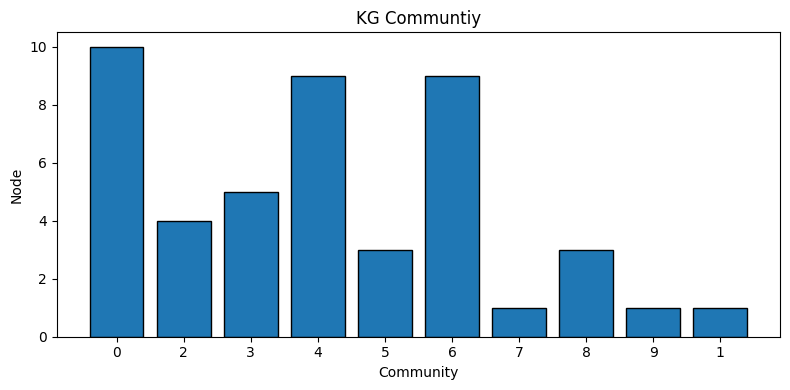

In [82]:
comm_sizes = {cid: len(nodes) for cid, nodes in communities.items()}

comm_summary = (
    pd.DataFrame.from_dict(comm_sizes, orient='index', columns=['size'])
      .reset_index()
      .rename(columns={'index':'community'})
)

plt.figure(figsize=(8,4))
plt.bar(comm_summary['community'].astype(str),
        comm_summary['size'],
        edgecolor='black')
plt.xlabel("Community")
plt.ylabel("Node")
plt.title("KG Communtiy")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

In [83]:
df_nodes = pd.DataFrame({
    "node": list(part.keys()),
    "community": list(part.values()),
    "degree": [deg[n] for n in part],
    "pagerank": [pr[n] for n in part],
    "betweenness": [bw[n] for n in part],
    "closeness": [cl[n] for n in part],
})

summary = (
    df_nodes
    .sort_values(["community","pagerank"], ascending=[True,False])
    .groupby("community")
    .head(3)
)
display(summary)


,node,community,degree,pagerank,betweenness,closeness
1,export,0,6,0.040489,0.140404,0.213924
14,yield,0,5,0.038570,0.247475,0.270400
20,production,0,3,0.023538,0.222222,0.299115
44,regulation,1,2,0.021739,0.000000,0.000000
3,flood,2,4,0.030430,0.038384,0.164878
2,climate,2,2,0.019876,0.074747,0.200000
31,emission,2,2,0.018807,0.109091,0.250370
4,price,3,5,0.035139,0.144444,0.218065
38,area,3,2,0.023120,0.038384,0.150222
21,investment,3,2,0.020554,0.074747,0.178836


   community  size                                         top_nodes
0          0    10          [export, yield, import, pig, production]
1          2     4          [flood, climate, emission, soil erosion]
2          3     5          [price, investment, area, drought, rice]
3          4     9             [farm, drone, maize, dairy, robotics]
4          5     3    [summit, regenerative agriculture, conference]
5          6     9  [crop, harvest, tomato, satellite imagery, corn]
6          7     1                                         [hectare]
7          8     3      [weather, artificial intelligence, rainfall]
8          9     1                                            [fish]
9          1     1                                      [regulation]


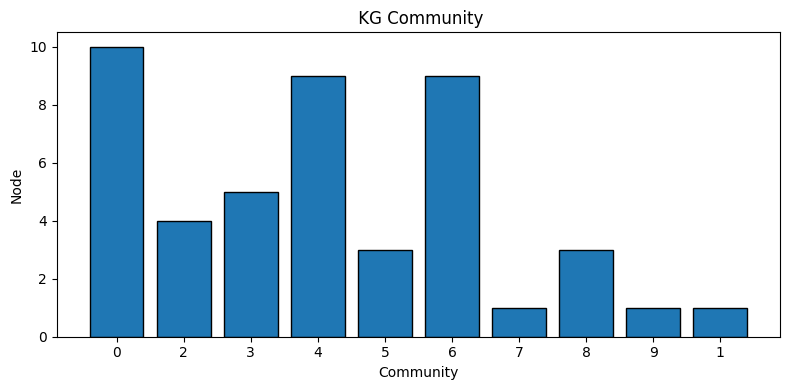

In [84]:
comm_sizes = {cid: len(nodes) for cid, nodes in communities.items()}
community_sizes = (
    pd.DataFrame.from_dict(comm_sizes, orient='index', columns=['size'])
      .reset_index()
      .rename(columns={'index':'community'})
)

node2comm = pd.DataFrame(
    list(part.items()), 
    columns=['node','community']
)

df_metrics = df_metrics.rename(columns={'entity':'node'})
df_with_comm = df_metrics.merge(node2comm, on='node')

topk_df = (
    df_with_comm
      .sort_values(['community','degree'], ascending=[True, False])
      .groupby('community')['node']
      .apply(lambda lst: list(lst)[:5])      # ambil 5 teratas
      .reset_index(name='top_nodes')
)

summary = community_sizes.merge(topk_df, on='community')

print(summary)

plt.figure(figsize=(8,4))
plt.bar(
    summary['community'].astype(str),
    summary['size'],
    edgecolor='black'
)
plt.xlabel("Community")
plt.ylabel("Node")
plt.title(" KG Community")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()


In [85]:
# maping node -> sentiment

sent = dict(zip(kg_agri['subject'], kg_df['sentiment']))
# kalau ada objek juga dengan sentimen:
sent.update(zip(kg_agri['object'], kg_df['sentiment']))

same, total = 0, 0
for u, v in G.edges():
    s_u = sent.get(u)
    s_v = sent.get(v)
    if s_u is None or s_v is None:
        continue
    total += 1
    if s_u == s_v:
        same += 1

print(f"Homophily: {same}/{total} = {same/total:.2f}")
print(f"Heterophily: {total-same}/{total} = {(total-same)/total:.2f}")

Homophily: 36/55 = 0.65
Heterophily: 19/55 = 0.35


In [86]:
G = nx.from_pandas_edgelist(
    kg_agri,
    source="subject",
    target="object",
    edge_attr="relation",
    create_using=nx.DiGraph()
)

motifs = Counter()
for u, v, d_uv in G.edges(data=True):
    r1 = d_uv["relation"]
    # untuk setiap tetangga kedua (v→w)
    for _, w, d_vw in G.edges(v, data=True):
        if w == u: 
            continue
        r2 = d_vw["relation"]
        motifs[(u, r1, v, r2, w)] += 1

df_motifs = (
    pd.DataFrame(
        [
            # formatting: "u —r1→ v —r2→ w"
            ("{} —{}→ {} —{}→ {}".format(u, r1, v, r2, w), cnt)
            for (u, r1, v, r2, w), cnt in motifs.items()
        ],
        columns=["Motif Relation", "count"]
    )
    .sort_values("count", ascending=False)
)

df_motifs.head(10)

,Motif Relation,count
0,import —fall→ export —go→ export,1
1,import —fall→ export —face→ tariff,1
58,drone —use→ farm —receive→ dairy,1
57,pilot —operate→ drone —give→ biodiversity,1
56,pilot —operate→ drone —use→ farm,1
55,investment —beat→ price —increase→ yield,1
54,investment —beat→ price —warn→ price,1
53,investment —beat→ price —push→ drought,1
52,production —take→ farm —evaluate→ supply chain,1
51,production —take→ farm —cost→ sheep,1


# GCN

## 1. Extract KG + Forward pass GCN

In [87]:
import pandas as pd
import numpy as np
import torch
from torch_geometric.data import Data

df = kg_agri.copy()

all_entities = pd.unique(df[["subject","object"]].values.ravel())
node2idx     = { ent:i for i,ent in enumerate(all_entities) }

# Build edge_index for PyG
edge_index = torch.tensor([
    [ node2idx[s] for s in df["subject"] ],
    [ node2idx[o] for o in df["object" ] ]
], dtype=torch.long)

#  Node features: one-hot identity matrix
N = len(all_entities)
x = torch.eye(N, dtype=torch.float)

# Create Data object
data = Data(x=x, edge_index=edge_index)

# Prepare label encoder
label_encoder = {"Pro":0, "Contra":1, "Neutral":2}

# Collect sentiment_low votes per entity
sent_raw = {}
for _, row in df.iterrows():
    sent_raw.setdefault(row["subject"],[]).append(row["sentiment"])
    sent_raw.setdefault(row["object" ],[]).append(row["sentiment"])

# Majority-vote to pick label per node
y_np = np.array([
    label_encoder[
        max(
            set(sent_raw.get(ent, ["Neutral"])),
            key=sent_raw.get(ent, ["Neutral"]).count
        )
    ]
    for ent in all_entities
], dtype=np.int64)

y = torch.from_numpy(y_np)

# Flat mapping entity → integer label
sentiment_map = { ent:y_np[idx] for ent,idx in node2idx.items() }

dist = pd.Series(y_np).map({0:"Pro",1:"Contra",2:"Neutral"})
print("Node label distribution (%):")
print(dist.value_counts(normalize=True).mul(100).round(2))

Node label distribution (%):
Pro        86.96
Contra     10.87
Neutral     2.17
Name: proportion, dtype: float64


In [88]:
# Split train 

from sklearn.model_selection import train_test_split

idx = np.arange(N)
counter = Counter(y_np)

good_idx = np.array([i for i in idx if counter[y_np[i]] > 1])
rare_idx = np.array([i for i in idx if counter[y_np[i]] <= 1])

tr_good, tmp_good = train_test_split(
    good_idx,
    test_size=0.4,
    stratify=y_np[good_idx],
    random_state=42,
)

va_good, te_good = train_test_split(
    tmp_good,
    test_size=0.5,
    random_state=42,
)

tr = np.concatenate([tr_good, rare_idx])
va = va_good
te = te_good

train_mask = torch.zeros(N, dtype=torch.bool)
val_mask   = torch.zeros(N, dtype=torch.bool)
test_mask  = torch.zeros(N, dtype=torch.bool)

train_mask[tr] = True
val_mask[va]  = True
test_mask[te] = True


In [89]:
from torch_geometric.data import Data
data = Data(x=x, edge_index=edge_index, y=y,
            train_mask=train_mask,
            val_mask=val_mask,
            test_mask=test_mask)

In [90]:
# Training GCN for node classifer
import torch.nn.functional as F
from torch_geometric.nn import GCNConv

class GCNNodeClassifier(torch.nn.Module):
    def __init__(self, in_feats, hid_feats, n_classes):
        super().__init__()
        self.conv1 = GCNConv(in_feats, hid_feats)
        self.conv2 = GCNConv(hid_feats, n_classes)
    def forward(self, x, edge_index):
        x = F.relu(self.conv1(x, edge_index))
        return self.conv2(x, edge_index)

model = GCNNodeClassifier(
    in_feats=data.num_node_features,  # = N
    hid_feats=64,
    n_classes=3
)
opt = torch.optim.Adam(model.parameters(), lr=0.01)

for epoch in range(1,201):
    model.train()
    opt.zero_grad()
    out = model(data.x, data.edge_index)      # shape [N,3]
    loss = F.cross_entropy(out[data.train_mask],
                           data.y[data.train_mask])
    loss.backward()
    opt.step()

    # (opsional) hitung validation accuracy
    model.eval()
    with torch.no_grad():
        logits = model(data.x, data.edge_index)[data.val_mask]
        preds  = logits.argmax(dim=1)
        acc    = (preds == data.y[data.val_mask]).float().mean()
    if epoch%20==0:
        print(f"Epoch {epoch:03d} Loss={loss:.4f} ValAcc={acc:.4f}")

Epoch 020 Loss=0.2623 ValAcc=0.8889
Epoch 040 Loss=0.0923 ValAcc=0.7778
Epoch 060 Loss=0.0251 ValAcc=0.7778
Epoch 080 Loss=0.0103 ValAcc=0.7778
Epoch 100 Loss=0.0056 ValAcc=0.7778
Epoch 120 Loss=0.0037 ValAcc=0.7778
Epoch 140 Loss=0.0026 ValAcc=0.7778
Epoch 160 Loss=0.0019 ValAcc=0.7778
Epoch 180 Loss=0.0015 ValAcc=0.7778
Epoch 200 Loss=0.0012 ValAcc=0.7778


## 2. Analisis Hasil Knowledge GRaph

In [91]:
import community as community_louvain
from sklearn.neighbors import kneighbors_graph
from sklearn.manifold      import TSNE
from collections import Counter
import networkx as nx
from networkx.algorithms import community as nx_comm  

# Extract GCN Embedding
model.eval()
with torch.no_grad():
    h1 = model.conv1(data.x, data.edge_index)
    h1 = F.relu(h1)
    z  = model.conv2(h1, data.edge_index)       
    embs = h1.cpu().numpy()                    

In [92]:
node_order = list(H.nodes())              
idx_list    = [node2idx[n] for n in node_order]   
embs_H      = embs[idx_list, :] 

node2idx_H = { n:i for i,n in enumerate(node_order) }     

In [93]:
from sklearn.cluster import KMeans

K = 5
km = KMeans(n_clusters=K, random_state=42).fit(embs_H)
df_emb = pd.DataFrame({
    "node":    node_order,
    "cluster": km.labels_,
})
print("Cluster sizes:\n", df_emb["cluster"].value_counts().sort_index(), "\n")

Cluster sizes:
 cluster
0     7
1     5
2     8
3    13
4     7
Name: count, dtype: int64 



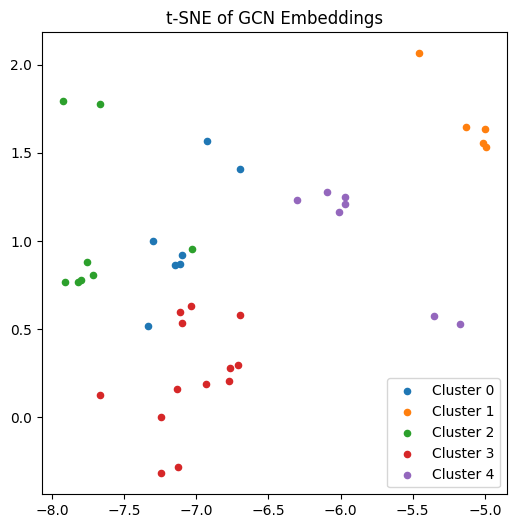

In [94]:
from sklearn.manifold import TSNE
import matplotlib.pyplot as plt

coords = TSNE(n_components=2, random_state=42).fit_transform(embs_H)
plt.figure(figsize=(6,6))
for c in range(K):
    pts = coords[df_emb['cluster']==c]
    plt.scatter(pts[:,0], pts[:,1], label=f'Cluster {c}', s=20)
plt.legend(); plt.title('t-SNE of GCN Embeddings')
plt.show()

In [95]:
for c in sorted(df_emb['cluster'].unique()):
    member = df_emb.loc[df_emb['cluster'] == c, 'node'].tolist()
    print(f"Cluster {c} (size={len(member)}):")
    print("  ", member)
    print()

Cluster 0 (size=7):
   ['price', 'drought', 'pig', 'investment', 'biodiversity', 'area', 'soybean']

Cluster 1 (size=5):
   ['harvest', 'artificial intelligence', 'weather', 'rainfall', 'corn']

Cluster 2 (size=8):
   ['climate', 'flood', 'dairy', 'pilot', 'drone', 'emission', 'sheep', 'supply chain']

Cluster 3 (size=13):
   ['import', 'export', 'food security', 'temperature', 'yield', 'export ban', 'poultry', 'production', 'tariff', 'tomato', 'fruit', 'livestock', 'rice']

Cluster 4 (size=7):
   ['farm', 'crop', 'robotics', 'maize', 'satellite imagery', 'soil erosion', 'soil health']



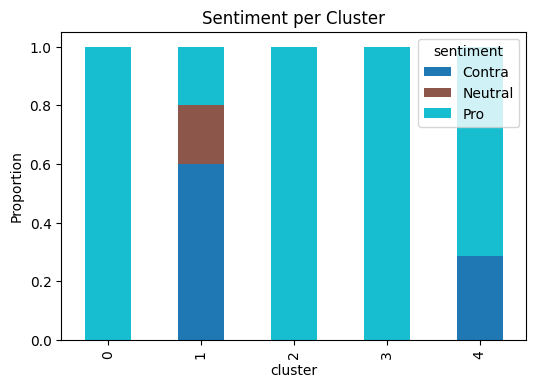

In [96]:
sent_map = {}
for col in ['subject','object']:
    for u,s in zip(kg_agri[col], kg_agri['sentiment']):
        sent_map.setdefault(u, s)

df_emb['sentiment'] = df_emb['node'].map(sent_map).fillna('UNKNOWN')
pd.crosstab(df_emb['cluster'], df_emb['sentiment'], normalize='index')\
  .plot(kind='bar', stacked=True, figsize=(6,4), colormap='tab10')
plt.ylabel('Proportion'); plt.title('Sentiment per Cluster')
plt.show()

=== Open vs Closed Triads per Cluster ===
         closed_triads  open_triads
cluster                            
0                    0           15
1                    0           18
2                    0           11
3                    3           33
4                    0           84 



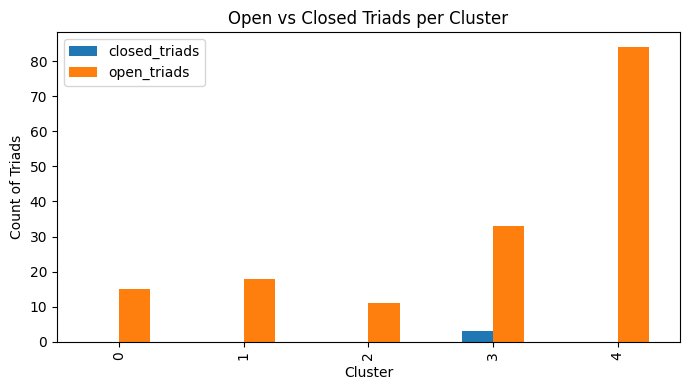

In [97]:
import networkx as nx
import pandas as pd
import matplotlib.pyplot as plt
from collections import Counter
import seaborn as sns

H_simple = nx.Graph(H)           
tris = nx.triangles(H_simple)    

def triad_counts(u):
    closed = tris.get(u, 0)
    deg = H_simple.degree(u)
    total_paths = deg * (deg-1) // 2
    open_ = total_paths - closed
    return closed, open_

df_emb[['closed_triads','open_triads']] = df_emb['node']\
    .apply(lambda u: pd.Series(triad_counts(u)))

df_tri = df_emb.groupby('cluster')[['closed_triads','open_triads']].sum()
print("=== Open vs Closed Triads per Cluster ===")
print(df_tri, "\n")

ax = df_tri.plot.bar(figsize=(7,4))
ax.set_xlabel("Cluster")
ax.set_ylabel("Count of Triads")
ax.set_title("Open vs Closed Triads per Cluster")
plt.tight_layout()
plt.show()

          node  closed_triads  open_triads  cluster sentiment  motif_count
19       pilot              0            0        2       Pro            2
16     poultry              0            0        3       Pro            1
15  export ban              0            1        3       Pro            4
26    rainfall              0            0        1    Contra            4
4        price              0           10        0       Pro            8


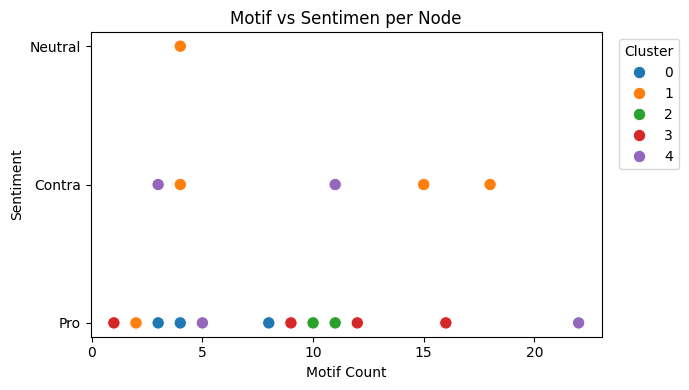

In [98]:
import networkx as nx
from collections import Counter

H_dir = H_simple.to_directed()

motif_cnt = Counter()
for u, v in H_dir.edges():
    for _, w in H_dir.out_edges(v):
        if w != u:
            motif_cnt[u] += 1

df_emb['motif_count'] = (
    df_emb['node']
        .map(motif_cnt)     
        .fillna(0)           
        .astype(int)
)

print(df_emb[['node','closed_triads','open_triads','cluster','sentiment','motif_count']]
      .sample(5, random_state=42))


import seaborn as sns
import matplotlib.pyplot as plt

sent_order = ['Pro','Contra','Neutral']
sent_num   = {s:i for i,s in enumerate(sent_order)}
df_emb['sent_num'] = df_emb['sentiment'].map(sent_num)

plt.figure(figsize=(7,4))
sns.scatterplot(
    data=df_emb,
    x='motif_count',
    y='sent_num',
    hue='cluster',
    palette='tab10',
    marker='o',
    s=80,
    legend='full'
)

plt.yticks(list(sent_num.values()), list(sent_num.keys()))
plt.xlabel("Motif Count")
plt.ylabel("Sentiment")
plt.title("Motif vs Sentimen per Node")
plt.legend(title="Cluster", bbox_to_anchor=(1.02,1), loc="upper left")
plt.tight_layout()
plt.show()

In [99]:
import numpy as np
import pandas as pd
import networkx as nx
import community as community_louvain
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score, roc_auc_score
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split

# Cluster Validation
score = silhouette_score(embs_H, df_emb['cluster'])
print(f"Silhouette score: {score:.3f}")

# Modularity Louvain 
H_und = H.to_undirected()
partition = community_louvain.best_partition(H_und, random_state=42)
mod = community_louvain.modularity(partition, H_und)
print(f"Louvain modularity: {mod:.3f}")

# Centrality per Cluster ---
deg = nx.degree_centrality(H_und)
bet = nx.betweenness_centrality(H_und, normalized=True)
df_emb['deg_central'] = df_emb['node'].map(deg)
df_emb['bet_central'] = df_emb['node'].map(bet)

centrality_summary = df_emb.groupby('cluster')\
    [['deg_central','bet_central']].agg(['mean','std']).round(3)
print("\nCentrality summary per cluster:")
print(centrality_summary)

# Motif (Triads) per Cluster
df_tri = df_emb.groupby('cluster')[['closed_triads','open_triads']].sum()
print("\nTotal triads per cluster:")
print(df_tri)

# Prototipe Link Prediction
edges     = list(H_und.edges())
non_edges = list(nx.non_edges(H_und))
neg_idx   = np.random.choice(len(non_edges), len(edges), replace=False)
neg_edges = [non_edges[i] for i in neg_idx]

def edge_feat(u, v):
    return embs_H[node2idx_H[u]] * embs_H[node2idx_H[v]]

X_pos = np.vstack([edge_feat(u, v) for u, v in edges])
X_neg = np.vstack([edge_feat(u, v) for u, v in neg_edges])
X = np.vstack([X_pos, X_neg])
y = np.hstack([np.ones(len(edges)), np.zeros(len(edges))])

Xtr, Xte, ytr, yte = train_test_split(X, y, test_size=0.3, random_state=42)
clf = LogisticRegression(max_iter=1000).fit(Xtr, ytr)
probs = clf.predict_proba(Xte)[:,1]
auc = roc_auc_score(yte, probs)
print(f"\nLink prediction AUC: {auc:.3f}")

Silhouette score: 0.141
Louvain modularity: 0.675

Centrality summary per cluster:
        deg_central        bet_central       
               mean    std        mean    std
cluster                                      
0             0.055  0.038       0.049  0.074
1             0.062  0.056       0.113  0.161
2             0.048  0.029       0.050  0.059
3             0.061  0.040       0.092  0.121
4             0.092  0.107       0.146  0.281

Total triads per cluster:
         closed_triads  open_triads
cluster                            
0                    0           15
1                    0           18
2                    0           11
3                    3           33
4                    0           84

Link prediction AUC: 0.670


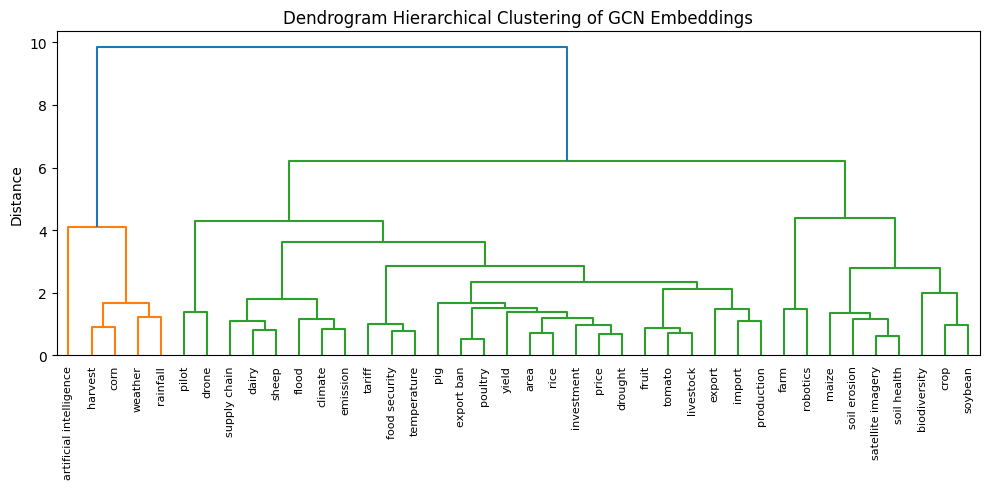


Community Role Profiling:
role
core          9
periphery    31
Name: node, dtype: int64


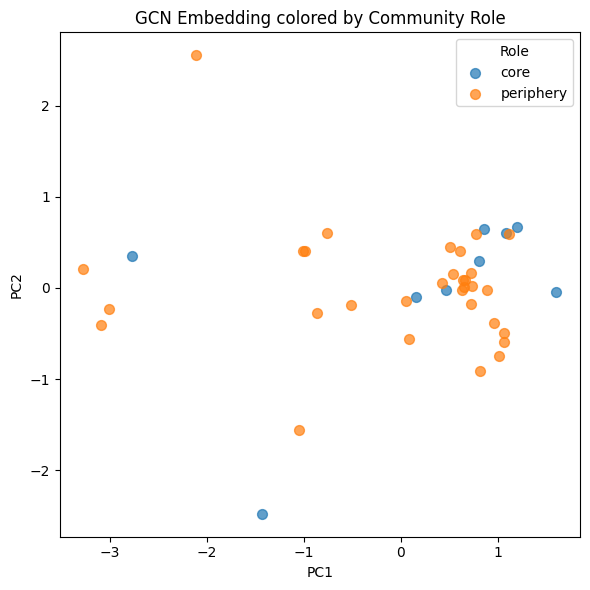


Link Suggestions (Top-5 similar nodes):
  import          → ['export', 'production', 'temperature', 'fruit', 'rice']
  export          → ['poultry', 'export ban', 'import', 'area', 'drought']
  climate         → ['flood', 'emission', 'dairy', 'sheep', 'supply chain']
  flood           → ['climate', 'emission', 'dairy', 'poultry', 'sheep']
  price           → ['drought', 'area', 'investment', 'rice', 'export']
  drought         → ['price', 'area', 'rice', 'export', 'poultry']
  food security   → ['temperature', 'tariff', 'fruit', 'livestock', 'import']
  temperature     → ['food security', 'tariff', 'import', 'fruit', 'export']
  farm            → ['robotics', 'maize', 'biodiversity', 'crop', 'soil health']
  dairy           → ['sheep', 'emission', 'supply chain', 'climate', 'flood']


In [100]:
from scipy.cluster.hierarchy import linkage, dendrogram
from sklearn.metrics.pairwise import cosine_similarity

# HIERARCHICAL CLUSTERING & DENDROGRAM
Z = linkage(embs_H, method='ward', metric='euclidean')

plt.figure(figsize=(10, 5))
dendrogram(
    Z,
    labels=node_order,
    leaf_rotation=90,
    leaf_font_size=8,
    color_threshold=0.7 * np.max(Z[:, 2])
)
plt.title('Dendrogram Hierarchical Clustering of GCN Embeddings')
plt.ylabel('Distance')
plt.tight_layout()
plt.show()

H_simple = nx.Graph(H_und)
H_simple.remove_edges_from(nx.selfloop_edges(H_simple))

# COMMUNITY ROLE PROFILING (Core vs Periphery)
core_numbers = nx.core_number(H_simple)
# Tambahkan ke df_emb
df_emb['core_num'] = df_emb['node'].map(core_numbers)

# Tentukan threshold: misal median core number
threshold = df_emb['core_num'].median()

# Klasifikasikan
df_emb['role'] = np.where(df_emb['core_num'] > threshold, 'core', 'periphery')

role_summary = df_emb.groupby('role')['node'].count()
print("\nCommunity Role Profiling:")
print(role_summary)

# Visualisasi scatter embedding dengan warna role
fig, ax = plt.subplots(figsize=(6,6))
# Proyeksikan embedding ke 2D dengan PCA (alternatif UMAP)
from sklearn.decomposition import PCA
coords2d = PCA(n_components=2, random_state=42).fit_transform(embs_H)

for role_label, grp in df_emb.groupby('role'):
    idxs = grp['node'].map(node2idx_H)
    ax.scatter(
        coords2d[idxs,0], coords2d[idxs,1],
        label=role_label, alpha=0.7, s=50
    )
ax.set_title('GCN Embedding colored by Community Role')
ax.legend(title='Role')
plt.xlabel('PC1'); plt.ylabel('PC2')
plt.tight_layout()
plt.show()


# LINK SUGGESTION / RECOMMENDATION (Top-K Neighbors)
sim_mat = cosine_similarity(embs_H)

K = 5  # top-K
recommendations = {}

for i, node in enumerate(node_order):
    # urutkan descending (kecuali diri sendiri)
    idx = np.argsort(-sim_mat[i, :])
    topk = [node_order[j] for j in idx if j != i][:K]
    recommendations[node] = topk

# Tampilkan contoh 10 node pertama
print("\nLink Suggestions (Top-5 similar nodes):")
for node in node_order[:10]:
    print(f"  {node:15s} → {recommendations[node]}")

In [101]:
valid_edges = [
    (u, v, 'related_to')
    for u, cands in recommendations.items()
    for v in cands
    if not H_und.has_edge(u, v)  # opsional: hanya edge baru
]

# Misal H_und adalah graph utama (nx.DiGraph jika arah penting)
for u, v, label in valid_edges:
    if not H_und.has_edge(u, v):
        H_und.add_edge(u, v, relation=label)

print(f"Added {len(valid_edges)} new edges.")  

Added 149 new edges.


In [102]:
import torch

edge_idx_pairs = []
for u, v in H_und.edges():
    # hanya edge jika kedua ujung ada di mapping
    if u in node2idx_H and v in node2idx_H:
        edge_idx_pairs.append((node2idx_H[u], node2idx_H[v]))

# Tensor 2×E
edge_index = torch.tensor(edge_idx_pairs, dtype=torch.long).t().contiguous()

# Masukkan ke model GCN untuk ekstrak embedding baru
model.eval()
with torch.no_grad():
    h1 = model.conv1(data.x, edge_index)
    h1 = F.relu(h1)
    _  = model.conv2(h1, edge_index)
    embs_H = h1.cpu().numpy()

print("Updated embeddings shape:", embs_H.shape)

Updated embeddings shape: (46, 64)


In [103]:
import community as community_louvain

H_simple = nx.Graph(H_und)
H_simple.remove_edges_from(nx.selfloop_edges(H_simple))
partition = community_louvain.best_partition(H_simple)
mod_new = community_louvain.modularity(partition, H_simple)
print("Modularity after enrichment:", mod_new)

Modularity after enrichment: 0.44768550448294053


In [104]:
import networkx as nx

# Kalau H_und adalah Graph tak berarah:
components = list(nx.connected_components(H_und))
print(f"Total connected components: {len(components)}\n")

# Cetak ukuran dan anggota tiap komponen
for i, comp in enumerate(components, 1):
    print(f"Component {i} (size={len(comp)}): {sorted(comp)}\n")

Total connected components: 1

Component 1 (size=40): ['area', 'artificial intelligence', 'biodiversity', 'climate', 'corn', 'crop', 'dairy', 'drone', 'drought', 'emission', 'export', 'export ban', 'farm', 'flood', 'food security', 'fruit', 'harvest', 'import', 'investment', 'livestock', 'maize', 'pig', 'pilot', 'poultry', 'price', 'production', 'rainfall', 'rice', 'robotics', 'satellite imagery', 'sheep', 'soil erosion', 'soil health', 'soybean', 'supply chain', 'tariff', 'temperature', 'tomato', 'weather', 'yield']



In [105]:
import community as community_louvain

# Buat Graph simple tanpa self-loop
H_simple = nx.Graph(H_und)
H_simple.remove_edges_from(nx.selfloop_edges(H_simple))

# Dapatkan partition: dict node → community_id
partition = community_louvain.best_partition(H_simple)

# Kumpulkan node per community
from collections import defaultdict
communities = defaultdict(list)
for node, comm_id in partition.items():
    communities[comm_id].append(node)

print(f"Detected {len(communities)} communities:\n")
for comm_id, members in communities.items():
    print(f"Community {comm_id} (size={len(members)}): {sorted(members)}\n")


Detected 4 communities:

Community 0 (size=9): ['export', 'food security', 'fruit', 'import', 'livestock', 'production', 'tariff', 'temperature', 'tomato']

Community 1 (size=7): ['climate', 'dairy', 'emission', 'farm', 'flood', 'sheep', 'supply chain']

Community 2 (size=12): ['area', 'biodiversity', 'drone', 'drought', 'export ban', 'investment', 'pig', 'pilot', 'poultry', 'price', 'rice', 'soybean']

Community 3 (size=12): ['artificial intelligence', 'corn', 'crop', 'harvest', 'maize', 'rainfall', 'robotics', 'satellite imagery', 'soil erosion', 'soil health', 'weather', 'yield']



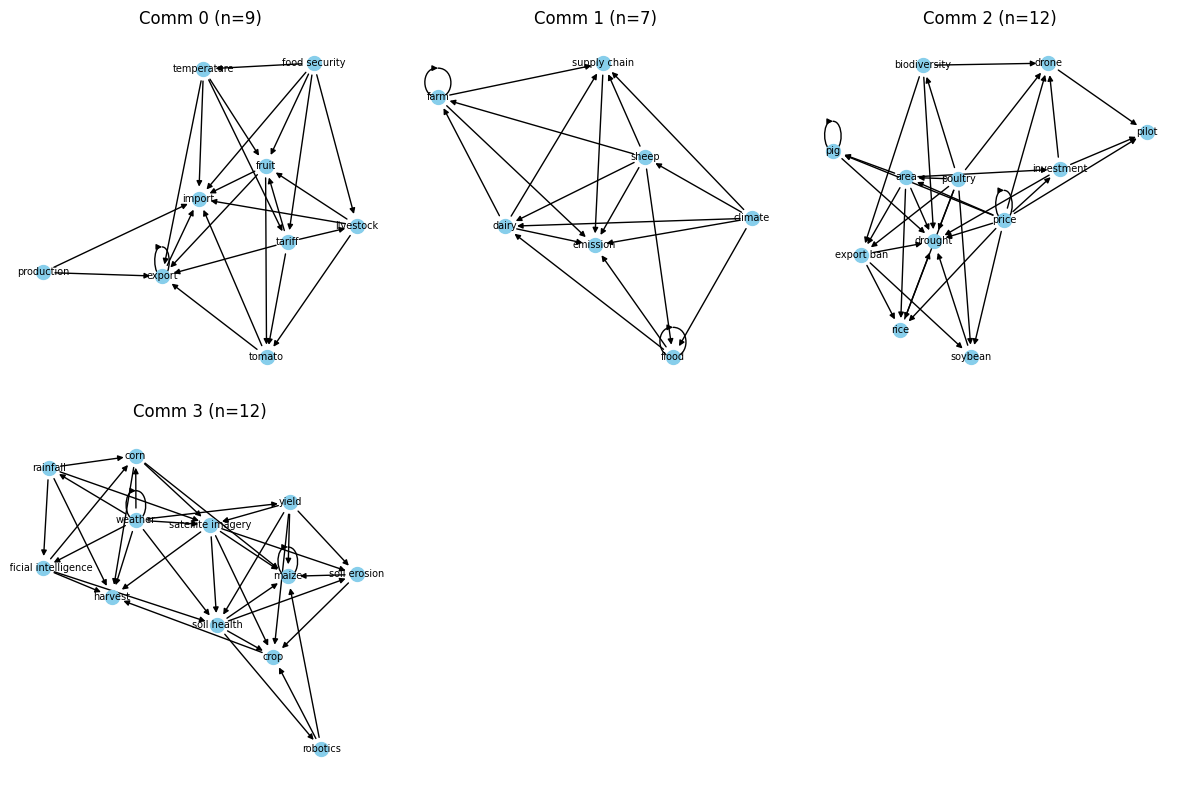

In [106]:
import networkx as nx
import matplotlib.pyplot as plt
import math

n_comms = len(communities)
cols    = 3
rows    = math.ceil(n_comms / cols)
fig, axes = plt.subplots(rows, cols, figsize=(cols*4, rows*4))

# Flatten axes array supaya mudah indexing
axes = axes.flatten()

# Loop tiap community
for ax, (cid, members) in zip(axes, communities.items()):
    subG = H_und.subgraph(members)
    # Pilih layout—spring agar rapi
    pos = nx.spring_layout(subG, seed=42)
    # Gambar node + edge + label
    nx.draw_networkx_nodes(subG, pos, ax=ax, node_size=100, node_color='skyblue')
    nx.draw_networkx_edges(subG, pos, ax=ax, arrowsize=8, arrowstyle='-|>')
    nx.draw_networkx_labels(subG, pos, ax=ax, font_size=7)
    ax.set_title(f'Comm {cid} (n={len(members)})')
    ax.axis('off')

for i in range(n_comms, len(axes)):
    axes[i].axis('off')

plt.tight_layout()
plt.show()


In [107]:
for cid, members in communities.items():
    subG = H_simple.subgraph(members)
    print(f"Comm {cid}: density={nx.density(subG):.3f}, diameter≈{nx.diameter(subG) if nx.is_connected(subG) else '—'}")

Comm 0: density=0.667, diameter≈2
Comm 1: density=0.857, diameter≈2
Comm 2: density=0.500, diameter≈3
Comm 3: density=0.545, diameter≈3


In [108]:
deg = nx.degree_centrality(H_simple)
bet = nx.betweenness_centrality(H_simple)
core = nx.core_number(H_simple)

stats = []
for cid, members in communities.items():
    ds = [deg[n] for n in members]
    bs = [bet[n] for n in members]
    ks = [core[n] for n in members]
    stats.append({
      'comm':cid,
      'size':len(members),
      'deg_mean':np.mean(ds),'bet_mean':np.mean(bs),'core_min':min(ks)
    })
pd.DataFrame(stats).set_index('comm')

,size,deg_mean,bet_mean,core_min
comm,,,,
0,9,0.188034,0.023662,5
1,7,0.216117,0.043803,5
2,12,0.205128,0.026258,5
3,12,0.198718,0.035258,5


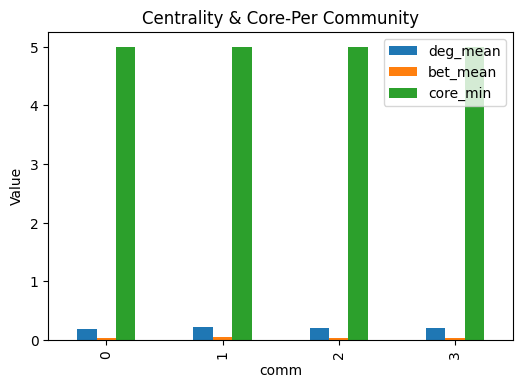

In [109]:
stats = pd.DataFrame(stats).set_index('comm')
stats[['deg_mean','bet_mean','core_min']].plot(kind='bar', figsize=(6,4))
plt.ylabel('Value'); plt.title('Centrality & Core-Per Community'); plt.show()

In [110]:
from networkx.algorithms import triads

for cid, members in communities.items():
    subG = H_simple.subgraph(members)
    census = nx.triads.triadic_census(subG.to_directed())
    print(f"Comm {cid}:", {k:v for k,v in census.items() if v>0})

Comm 0: {'003': 3, '102': 20, '201': 35, '300': 26}
Comm 1: {'102': 2, '201': 11, '300': 22}
Comm 2: {'003': 28, '102': 85, '201': 76, '300': 31}
Comm 3: {'003': 13, '102': 94, '201': 73, '300': 40}


         closed_triads  open_triads
cluster                            
0                   26           55
1                   22           13
2                   31          161
3                   40          167


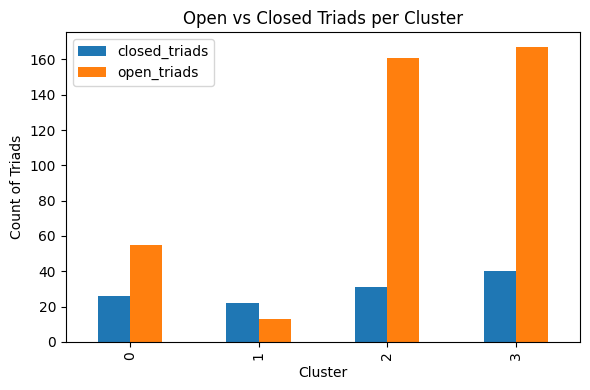

In [111]:
from networkx.algorithms import triads as nx_triads

rows = []
for cid, members in communities.items():
    subG = H_simple.subgraph(members).to_directed()
    census = nx_triads.triadic_census(subG)
    # triadic_census mengembalikan dict dengan key seperti '300','102','201','030C','021D', dst
    closed = census['300']  # tiga sisi; tertutup
    open_ = census['201'] + census['102']  # dua sisi terbuka + satu sisi (chain), tergantung definisi
    rows.append({'cluster': cid, 'closed_triads': closed, 'open_triads': open_})

df_triads = pd.DataFrame(rows).set_index('cluster')
print(df_triads)

# Visualisasi
ax = df_triads.plot.bar(
    y=['closed_triads','open_triads'],
    stacked=False,
    figsize=(6,4),
)
ax.set_xlabel('Cluster')
ax.set_ylabel('Count of Triads')
ax.set_title('Open vs Closed Triads per Cluster')
plt.tight_layout()
plt.show()

/Users/elisa/Documents/Final_project/data_fp/.venv/lib/python3.13/site-packages/networkx/drawing/nx_pylab.py:1296: UserWarning: 

The arrowsize keyword argument is not applicable when drawing edges
with LineCollection.

To make this warning go away, either specify `arrows=True` to
force FancyArrowPatches or use the default values.
Note that using FancyArrowPatches may be slow for large graphs.

  draw_networkx_edges(G, pos, arrows=arrows, **edge_kwds)


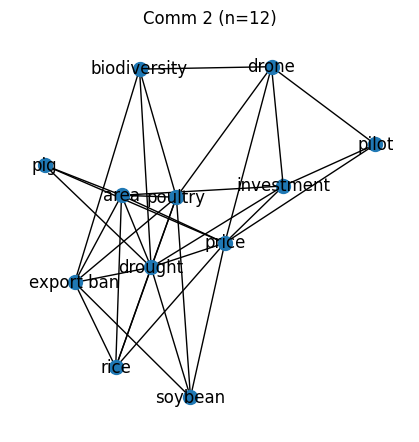

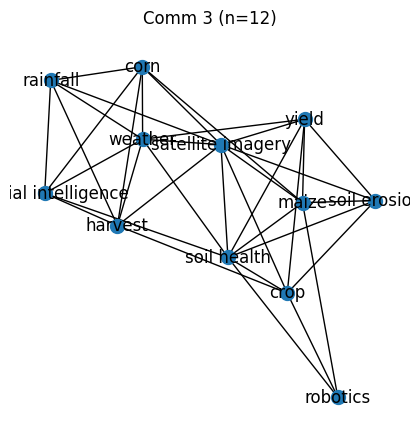

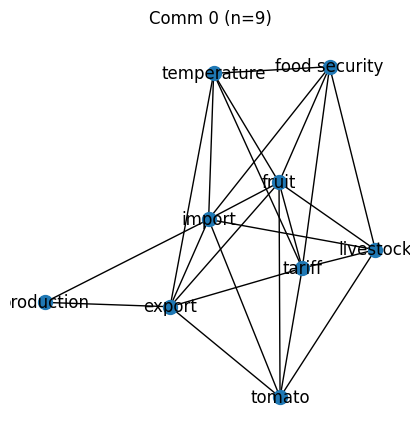

In [112]:
for cid in sorted(communities, key=lambda c: len(communities[c]), reverse=True)[:3]:
    subG = H_simple.subgraph(communities[cid])
    plt.figure(figsize=(4,4))
    pos = nx.spring_layout(subG, seed=42)
    nx.draw(subG, pos, with_labels=True, node_size=100, arrowsize=8)
    plt.title(f"Comm {cid} (n={len(subG)})")
    plt.axis('off')
    plt.show()

Counts of sentiment per community:
 sent  Contra  Neutral  Pro
comm                      
0          0        0    9
1          0        0    7
2          0        0   12
3          5        1    6 



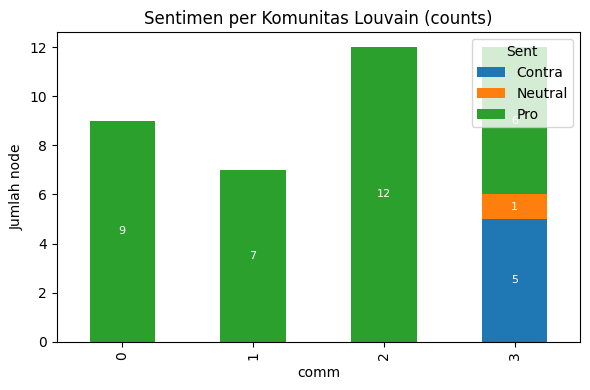

In [113]:
df_comm = pd.DataFrame({
    'comm': list(partition.values()),   # partition: dict node→comm_id
    'node': list(partition.keys())
})
# map node → sentiment
df_comm['sent'] = df_comm['node'].map(sent_map).fillna('UNKNOWN')

# itung counts (bukan proporsi)
count_ct = pd.crosstab(df_comm['comm'], df_comm['sent'])
print("Counts of sentiment per community:\n", count_ct, "\n")

# Plot stacked bar dengan annotation jumlah
ax = count_ct.plot(kind='bar', stacked=True, figsize=(6,4))
plt.ylabel("Jumlah node")
plt.title("Sentimen per Komunitas Louvain (counts)")

# tambahkan label di masing-masing segment bar
for p in ax.patches:
    height = p.get_height()
    if height>0:
        ax.annotate(int(height),
                    (p.get_x() + p.get_width()/2, p.get_y() + height/2),
                    ha='center', va='center', color='white', fontsize=8)

plt.legend(title='Sent', loc='upper right')
plt.tight_layout()
plt.show()


          node  community sentiment  motif_count
19       pilot          2       Pro           36
16     poultry          2       Pro           90
15  export ban          2       Pro           65
26    rainfall          3    Contra           43
4        price          2       Pro           84


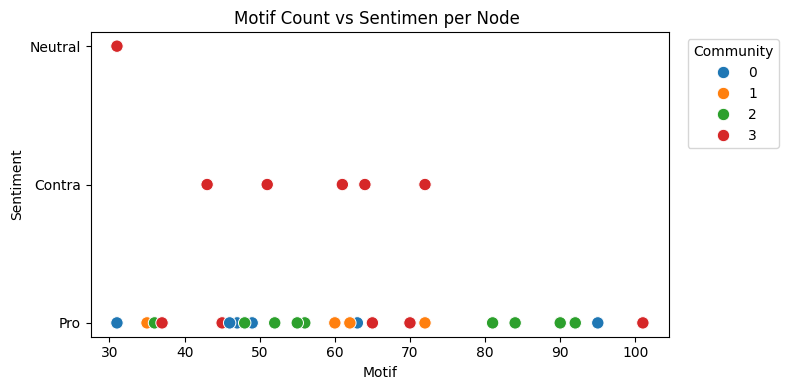

In [114]:
H_dir = H_simple.to_directed()
motif_cnt = Counter()
for u,v in H_dir.edges():
    for _, w in H_dir.out_edges(v):
        if w != u:
            motif_cnt[u] += 1

df_emb['motif_count'] = (
    df_emb['node']
      .map(motif_cnt)   
      .fillna(0)
      .astype(int)
)

df_emb['community'] = df_emb['node'].map(partition)

sent_order = ['Pro','Contra','Neutral']
sent_num   = {s:i for i,s in enumerate(sent_order)}
df_emb['sent_num'] = df_emb['sentiment'].map(sent_num)

print( df_emb[['node','community','sentiment','motif_count']].sample(5, random_state=42) )

plt.figure(figsize=(8,4))
sns.scatterplot(
    data=df_emb,
    x='motif_count',
    y='sent_num',
    hue='community',
    palette='tab10',
    s=80,
    legend='full'
)
plt.yticks(list(sent_num.values()), list(sent_num.keys()))
plt.xlabel("Motif")
plt.ylabel("Sentiment")
plt.title("Motif Count vs Sentimen per Node ")
plt.legend(title="Community", bbox_to_anchor=(1.02,1), loc="upper left")
plt.tight_layout()
plt.show()


# Valid Truth

In [ ]:
import pandas as pd
from sklearn.metrics import confusion_matrix, classification_report

filtered_df = pd.read_csv('filtered_df.csv')
filtered_df = filtered_df.reset_index(drop=True).reset_index().rename(columns={'index':'id'})

df_manual = pd.read_csv('df_manual.csv')
df_manual = df_manual.dropna(subset=['No']).copy()
df_manual['id'] = df_manual['No'].astype(int) - 1
df_manual = df_manual.drop_duplicates(subset='id')

df_eval = pd.merge(
    filtered_df[['id','Sentiment_Label']],
    df_manual[['id','Sentiment_truth']],
    on='id',
    how='inner'
)

accuracy = (df_eval['Sentiment_Label'] == df_eval['Sentiment_truth']).mean()
print(f"Overall Accuracy: {accuracy:.2%}\n")

table = (
    df_eval
    .groupby(['Sentiment_truth','Sentiment_Label'])
    .size()
    .unstack(fill_value=0)
)
print("Validation Table (manual vs automatic):")
print(table, "\n")

labels = ['Pro','Contra','Neutral']
cm = confusion_matrix(df_eval['Sentiment_truth'], df_eval['Sentiment_Label'], labels=labels)
print("Confusion Matrix:")
print(pd.DataFrame(cm, index=[f"True_{l}" for l in labels], columns=[f"Pred_{l}" for l in labels]),"\n")

print("Classification Report:")
print(classification_report(df_eval['Sentiment_truth'], df_eval['Sentiment_Label'], labels=labels))


Overall Accuracy: 67.50%

Validation Table (manual vs automatic):
Sentiment_Label  Contra  Neutral  Pro
Sentiment_truth                      
Contra               17        2   18
Neutral               1        5    9
Pro                   5        4   59 

Confusion Matrix:
              Pred_Pro  Pred_Contra  Pred_Neutral
True_Pro            59            5             4
True_Contra         18           17             2
True_Neutral         9            1             5 

Classification Report:
              precision    recall  f1-score   support

         Pro       0.69      0.87      0.77        68
      Contra       0.74      0.46      0.57        37
     Neutral       0.45      0.33      0.38        15

    accuracy                           0.68       120
   macro avg       0.63      0.55      0.57       120
weighted avg       0.67      0.68      0.66       120



In [ ]:
import pandas as pd
from nltk.sentiment.vader import SentimentIntensityAnalyzer

df = pd.read_csv('filtered_df.csv')

sia = SentimentIntensityAnalyzer()
df['compound'] = df['Content_clean'].apply(lambda text: sia.polarity_scores(text)['compound'])

POS_LEX = {"fertilizer", "yield", "sustainability", "opportunities"}
NEG_LEX = {"insufficient", "delay", "challenges", "costs", "skepticism"}

example_pro = (
    df[df['compound'] >= 0.05]
      .loc[lambda d: d['Content_clean'].str.lower()
                      .apply(lambda t: bool(set(t.split()) & POS_LEX))]
      .nlargest(1, 'compound')
      .iloc[0]
)

example_contra = (
    df[df['compound'] <= -0.05]
      .loc[lambda d: d['Content_clean'].str.lower()
                      .apply(lambda t: bool(set(t.split()) & NEG_LEX))]
      .nsmallest(1, 'compound')
      .iloc[0]
)

# Tampilkan hasil
print("Pro Example:", example_pro['Content_clean'], example_pro['compound'],
      set(example_pro['Content_clean'].lower().split()) & POS_LEX)
print("Contra Example:", example_contra['Content_clean'], example_contra['compound'],
      set(example_contra['Content_clean'].lower().split()) & NEG_LEX)


Pro Example: grow use conventional toothbrush essentially stick bristle end may surprise learn long electric toothbrush around first design late 1930s model long way sleek feature pack bluetooth enabled beast buy today dozen ultra advanced version market one worth cash past two month teeth become figurative guinea pig help find answer question put bunch electric toothbrush oral philip suri ordo silk foreo pace separate best rest conclusion glance best electric toothbrush overall spotlight sonic pro spotlight oral care best value electric toothbrush icy bear next generation sonic toothbrush amazon best premium electric toothbrush philip sonicare smart 9400 160 amazon best oscillate toothbrush oral io3 boot best electric toothbrush sustainability suri sonic toothbrush boot trust well physical quality require test electric toothbrush teeth reliable toothpaste budget test electronics phone drone everything decade also put delicately prevent closing page justify disgust someone wear retaine

In [ ]:
from nltk.sentiment.vader import SentimentIntensityAnalyzer
sia = SentimentIntensityAnalyzer()

filtered_df['compound'] = (
    filtered_df['Content_clean']
    .apply(lambda t: sia.polarity_scores(t)['compound'])
)


In [ ]:
POS_LEX = {"fertilizer","yield","sustainability","opportunities"}
NEG_LEX = {"insufficient","delay","challenges","costs","skepticism"}

example_pro = (
    filtered_df
    .loc[filtered_df['Sentiment_Label']=='Pro']
    .loc[filtered_df['Content_clean'].str.lower()
            .apply(lambda t: bool(set(t.split()) & POS_LEX))]
    .nlargest(1, 'compound')
    .iloc[0]
)

example_contra = (
    filtered_df
    .loc[filtered_df['Sentiment_Label']=='Contra']
    .loc[filtered_df['Content_clean'].str.lower()
            .apply(lambda t: bool(set(t.split()) & NEG_LEX))]
    .nsmallest(1, 'compound')
    .iloc[0]
)

for label, ex in [("Pro", example_pro), ("Contra", example_contra)]:
    matches = set(ex['Content_clean'].lower().split()) & (POS_LEX if label=="Pro" else NEG_LEX)
    snippet = ex['Content_clean'][:120].replace('\n',' ') + "…"
    print(f"{label} → “{snippet}”  (compound={ex['compound']:.2f}, keywords={matches})")


Pro → “grow use conventional toothbrush essentially stick bristle end may surprise learn long electric toothbrush around first …”  (compound=1.00, keywords={'sustainability'})
Contra → “blog close new live blog read full report los angeles wildfire hurst fire 37% contain california governor gavin newsom s…”  (compound=-1.00, keywords={'delay'})
